# Обнаружение аномалий в транзакциях сети Ethereum с помощью объяснимого автокодировщика с механизмом внимания

# 1 Общие положения

## 1.1 Сценарии использования ноутбука

**Сценарий 1 - Полное воспроизведение**

Предназначен для проверки воспроизводимости результатов. Предусматривает последовательный запуск всех ячеек основной части ноутбука в следующем порядке:

- 1.2 - Импорт библиотек и настройка окружения;
- 1.3 - Настройка загрузки данных и артефактов;
- 2 - Подготовка выборок для обучения;
- 3 - Создание автокодировщиков;
- 4 - Создание автокодировщиков с механизмом внимания;
- 5 - Реализация методов объяснимости;
- 6 - Сравнение лучшей модели с альтернативными методами;
- 7 - Итоговая оценка результата;
- 8 - Выполнение дополнительных проверок.



**Сценарий 2 - Использование ранее сохранённых артефактов**

Предназначен для проведения отдельных проверок без траты времени на повторное выполнение ранее проделанной работы:

- 1.2 - Импорт библиотек и настройка окружения;
- 1.3 - Настройка загрузки данных и артефактов;
- B.3 - Загрузка готовых обучающих выборок;
- B.4 - Загрузка готовых артефактов;
- 3.1 - Общая подготовка эксперимента;
- 4.1 - Создание слоя внимания;
- 4.4 (ячейка № 3 "Создание модели № 6") - создание модели № 6;
- B.6 - Загрузка готовых обученных моделей;
- B.7 - Загрузка готовых артефактов SHAP;
- B.8 - Загрузка оценок значимости по Attention;
- B.9 - Загрузка результатов сравнения оценок по SHAP и Attention;
- B.10 - Загрузка обученной модели изолирующего леса;
- B.11 - Загрузка обученной модели локального фактора выброса;
- B.12 - Загрузка обученной модели вариационного автокодировщика;
- B.13 - Загрузка готовых результатов сравнения методов обнаружения аномалий;
- B.14 - Загрузка калиброванного порога принятия решения для модели 6.

## 1.2 Импорт библиотек и настройка окружения

In [ ]:
pip install shap -q

In [ ]:
import random

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import tensorflow as tf

from scipy.stats import (
    mannwhitneyu,
    rankdata,
    spearmanr,
)
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

from tensorflow import keras
from tensorflow.keras import layers

from pathlib import Path
from urllib.request import urlretrieve

## 1.3 Настройка загрузки данных и артефактов

Исходные данные и сохранённые артефакты загружаются из публичного GitHub-репозитория проекта. Файлы загружаются по мере необходимости и кэшируются в локальной файловой системе текущей среды выполнения.

In [ ]:
GITHUB_RAW_BASE = (
    "https://raw.githubusercontent.com/"
    "KozinIS/ethereum-anomaly-detection-xai/main"
)

CACHE_PATH = (
    Path.cwd()
    / ".cache"
    / "ethereum-anomaly-detection-xai"
)


def github_file(relative_path):
    local_path = CACHE_PATH / relative_path

    local_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    if not local_path.exists():
        url = (
            f"{GITHUB_RAW_BASE}/"
            f"{relative_path}"
        )

        urlretrieve(
            url,
            local_path
        )

    return str(local_path)

---
Промежуточные результаты по умолчанию не сохраняются.

При **SAVE_ARTIFACTS = True** Google Drive подключается автоматически, а сформированные артефакты сохраняются в каталог **MyDrive/ethereum-anomaly-detection-xai/** с сохранением структуры каталогов проекта.

In [ ]:
# Set to True to save generated artifacts to Google Drive
SAVE_ARTIFACTS = True

SAVE_ROOT = None

if SAVE_ARTIFACTS:
    try:
        from google.colab import drive
    except ImportError as exc:
        raise RuntimeError(
            "Artifact saving is configured for Google Colab. "
            "Run the notebook in Colab or set "
            "SAVE_ARTIFACTS = False."
        ) from exc

    drive.mount("/content/drive")

    SAVE_ROOT = (
        Path("/content/drive/MyDrive")
        / "ethereum-anomaly-detection-xai"
    )

    SAVE_ROOT.mkdir(
        parents=True,
        exist_ok=True
    )

    print(
        f"Artifacts will be saved to: {SAVE_ROOT}"
    )


def save_path(relative_path):
    """
    Return a Google Drive path for a generated artifact
    and create its parent directory if necessary.
    """

    if SAVE_ROOT is None:
        raise RuntimeError(
            "Artifact saving is disabled. "
            "Set SAVE_ARTIFACTS = True."
        )

    path = SAVE_ROOT / relative_path

    path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    return str(path)

print(
    f"Artifact saving enabled: {SAVE_ARTIFACTS}"
)

if not SAVE_ARTIFACTS:
    print(
        "Generated artifacts will not be saved "
        "to Google Drive."
    )

Mounted at /content/drive
Artifacts will be saved to: /content/drive/MyDrive/ethereum-anomaly-detection-xai


# 2 Подготовка выборок для обучения

## 2.1 Загрузка сырых данных

In [ ]:
df = pd.read_csv(
    github_file("data/source/01_ethereum_raw.csv"),
    low_memory=False
)

In [ ]:
print(df.shape)
print(df['label'].value_counts())

(88145, 22)
label
0    86751
1     1394
Name: count, dtype: int64


## 2.2 Описание и проверка сырых данных

**Ознакомление с содержанием данных**

Тип данных

In [ ]:
df.dtypes

,0
blockNumber,int64
blockHash,object
timeStamp,int64
hash,object
nonce,int64
transactionIndex,int64
from,object
to,object
value,object
gas,int64


Пропуски в данных

In [ ]:
print(df.isnull().sum())

blockNumber              0
blockHash                0
timeStamp                0
hash                     0
nonce                    0
transactionIndex         0
from                     0
to                     924
value                    0
gas                      0
gasPrice                 0
input                    0
methodId                 0
functionName         27339
contractAddress      87221
cumulativeGasUsed        0
txreceipt_status      6268
gasUsed                  0
confirmations            0
isError                  0
label                    0
source_address           0
dtype: int64


Пример данных

In [ ]:
df.head(5)

,blockNumber,blockHash,timeStamp,hash,nonce,transactionIndex,from,to,value,gas,...,methodId,functionName,contractAddress,cumulativeGasUsed,txreceipt_status,gasUsed,confirmations,isError,label,source_address
0,24638050,0x1f7adcd4b1297b32c79cbe2a7338bd72d2d4b277ba1f...,1773278303,0x64070c28121ccde020b606188dbe24b55e02073ba1c7...,767,521,0x52ac12480565555257a77c9f79f5b7ac770cfa09,0xd8da6bf26964af9d7eed9e03e53415d37aa96045,10000000000000,21227,...,0x,NaN,NaN,39705572,1.0,21062,3145,0,0,0xd8dA6BF26964aF9D7eEd9e03E53415D37aA96045
1,24619744,0xdd875125316eebf8aaf8aa2a19490ad4320889318ab8...,1773057215,0xf1f160954915d3fc39207909e63adaaae1378c238fc7...,0,536,0xe76e2ac03c3eec2215d82f468ce30bbd36afa0f9,0xd8da6bf26964af9d7eed9e03e53415d37aa96045,1000000000000,21227,...,0x,NaN,NaN,40015753,1.0,21062,21451,0,0,0xd8dA6BF26964aF9D7eEd9e03E53415D37aA96045
2,24619362,0x5cabdf245a4bdb20d389790dae0c592c652faa255a88...,1773052619,0x2f7d79cf42604139d9b11be504f47437c3caee931c21...,31,53,0xfe306beff935e46c92efb78f4c0795f6a09c4201,0xd8da6bf26964af9d7eed9e03e53415d37aa96045,10000000000000,53701,...,0x23204d61,NaN,NaN,5110379,1.0,35440,21833,0,0,0xd8dA6BF26964aF9D7eEd9e03E53415D37aA96045
3,24616030,0xbca331a398eb2c7862babdeee0a8a88f0825ecb2d438...,1773012479,0xed6bd8a5ad0bd100be6cd4b2815a6aacac4d44df30ed...,0,166,0xaefc626213e35a7d3a73d2fc1f3dad4f33ee1ef1,0xd8da6bf26964af9d7eed9e03e53415d37aa96045,5130000000000000,31840,...,0x,NaN,NaN,24679733,1.0,21062,25165,0,0,0xd8dA6BF26964aF9D7eEd9e03E53415D37aA96045
4,24603012,0x86b18699670ac1e5c54305afeee51e4f6b7275db579c...,1772855555,0xf7cf7796d5280fac7f1108143c8d554970b25b9773db...,3,29,0x3d7c4c93a23ea09f7b73b83f29e06100f4d4fb75,0xd8da6bf26964af9d7eed9e03e53415d37aa96045,5324524823240,23350,...,0x,NaN,NaN,2157483,1.0,21062,38183,0,0,0xd8dA6BF26964aF9D7eEd9e03E53415D37aA96045


**Обобщённое описание столбцов**



---


*[blockNumber]*

Предназначение: номер блока в котором записана транзакция.

Вывод о необходимости парсинга: удалить.


---

*[blockHash]*

Предназначение: хеш блока (уникальный идентификатор блока).

Вывод о необходимости парсинга: удалить.


---



*[timeStamp]*

Предназначение: время транзакции в формате Unix timestamp (секунды с 01.01.1970 UTC).

Вывод о необходимости парсинга: извлечь сведения о времени и дне недели => удалить колонку.


---



*[hash]*

Предназначение: уникальный хеш транзакции.

Вывод о необходимости парсинга: удалить, но перед обучением модели (идентификаторы, не несут информации для модели; стоит сохранить до конца параметризации для возможности отследить любую запись обратно к источнику).


---



*[nonce]*

Предназначение: порядковый номер транзакции отправителя (счётчик всех исходящих транзакций адреса).

Вывод о необходимости парсинга: оставить без изменений.


---



*[transactionIndex]*

Предназначение: порядковый номер транзакции внутри блока.

Вывод о необходимости парсинга: удалить.


---



*[from]*

Предназначение: адрес отправителя (20-байтный шестнадцатеричный идентификатор).

Вывод о необходимости парсинга: удалить, но не сразу - использовать только для вычисления агрегаторов по отправителю, после чего отбросить (агрегаты будут рассчитываться только по Train reference set).


---



*[to]*

Предназначение: адрес получателя; пустое значение если транзакция создаёт новый смарт-контракт.

Примечание: 924 пропуска - адрес получателя пустой когда транзакция создаёт новый смарт-контракт (в этом случае адрес контракта появляется в contractAddress). Для признака is_self_tx эти строки нужно обработать.

Вывод о необходимости парсинга: удалить, но не сразу (использовать только для вычисления агрегаторов по отправителю, после чего отбросить).


---



*[value]*

Предназначение: сумма перевода в Wei (1 ETH = 10¹⁸ Wei); тип object из-за больших чисел.

Вывод о необходиморсти парсинга: изменить тип данных с object на float.


---



*[gas]*

Предназначение: максимальный лимит газа выделенный отправителем для выполнения транзакции.

Вывод о необходиморсти парсинга: оставить без изменений.


---



*[gasPrice]*

Предназначение: цена одной единицы газа в Wei, установленная отправителем.

Вывод о необходиморсти парсинга: оставить без изменений.


---



*[input]*

Предназначение: входные данные вызова смарт-контракта в шестнадцатеричном формате; "0x" для простых переводов ETH.

Вывод о необходимости парсинга: извлечь длину в байтах и флаг наличия данных (не равно "0x") => удалить колонку.


---



*[methodId]*

Предназначение: первые 4 байта поля input - идентификатор вызываемой функции смарт-контракта.

Вывод о необходимости парсинга: оставить без изменений до разделения данных на выборки; после разделения использовать для формирования числового признака на основе частоты methodId, рассчитанной только по Train, после чего исходную колонку удалить.


---



*[functionName]*

Предназначение: человекочитаемое название вызываемой функции (определяется Etherscan по methodId; часто пустое).

Примечание: 27 339 пропусков - Etherscan не всегда может определить название функции по methodId. Поле не используем.

Вывод о необходимости парсинга: удалить.


---



*[contractAddress]*

Предназначение: адрес созданного смарт-контракта; заполняется только для транзакций развёртывания контракта.

Примечание: поле почти полностью пустое, т.к. заполняется только когда транзакция создаёт новый контракт. В нашей выборке почти все транзакции — обычные переводы или вызовы существующих контрактов.

Вывод о необходимости парсинга: удалить.


---



*[cumulativeGasUsed]*

Предназначение: суммарный газ потреблённый всеми транзакциями блока включая текущую.

Примечание: это характеристика блока, а не транзакции.

Вывод о необходимости парсинга: удалить.


---



*[txreceipt_status]*

Предназначение: статус исполнения транзакции, содержательно дублирует isError (обратное бинарное кодирование); пустое значение для транзакций до хардфорка Byzantium (2017).

Примечание: Это поле появилось в Ethereum после хардфорка Byzantium (2017). До него поле не заполнялось - отсюда 6268 пустых значений.

Вывод о необходимости парсинга: удалить.


---



*[gasUsed]*

Предназначение: фактически потреблённый газ при выполнении транзакции.

Вывод о необходимости парсинга: оставить без изменений.


---



*[confirmations]*

Предназначение: количество блоков добавленных в цепочку после блока с данной транзакцией на момент сбора данных.

Примечание: не информативен, т.к. количество блоков после транзакции зависит от того, когда мы собрали данные, а не от самой транзакции.

Вывод о необходимости парсинга: удалить.


---



*[isError]*

Предназначение: Флаг ошибки выполнения транзакции: 1 - ошибка, 0 - успех.

Вывод о необходимости парсинга: оставить без изменений.


---



*[label]*

Предназначение: метка класса: 0 - нормальная транзакция, 1 - аномальная (мошенническая).

Вывод о необходимости парсинга: оставить без изменений.


---



*[source_address 	]*

Предназначение: адрес из списка опрашиваемых адресов по которому была получена данная транзакция (служебная колонка).

Примечание: идентификаторы, не несут информации для модели.

Вывод о необходимости парсинга: удалить.


---


**Проверка уникальности транзакций**

In [ ]:
duplicate_hashes = df['hash'].duplicated().sum()

print(f'Number of duplicate transaction hashes: {duplicate_hashes}')

assert duplicate_hashes == 0, \
    'Duplicate transactions detected based on transaction hash'

Number of duplicate transaction hashes: 0


In [ ]:
label_conflicts = (
    df.groupby('hash')['label']
      .nunique()
      .gt(1)
      .sum()
)

print(f'Number of transaction hashes with conflicting labels: {label_conflicts}')

assert label_conflicts == 0, \
    'Identical transactions with conflicting labels detected'

Number of transaction hashes with conflicting labels: 0


## 2.3 Парсинг

---
Удаление ненужных столбцов:
*   [blockNumber];
*   [blockHash];
*   [transactionIndex];
*   [functionName];
*   [contractAddress];
*   [cumulativeGasUsed];
*   [txreceipt_status];
*   [confirmations];
*   [source_address].


In [ ]:
cols_to_drop = ['blockNumber', 'blockHash', 'transactionIndex', 'functionName',
                'contractAddress', 'cumulativeGasUsed', 'txreceipt_status', 'confirmations',
                'source_address']

df = df.drop(columns=cols_to_drop)
print('Remaining columns:', list(df.columns))

Remaining columns: ['timeStamp', 'hash', 'nonce', 'from', 'to', 'value', 'gas', 'gasPrice', 'input', 'methodId', 'gasUsed', 'isError', 'label']


---
[Value]: изменение типа данных с object на float

In [ ]:
print(df['value'].dtype)
print(df['value'].head(10).tolist())

object
['10000000000000', '1000000000000', '10000000000000', '5130000000000000', '5324524823240', '1337', '12500000000000', '1337', '1337', '50000000000000']


In [ ]:
df['value'] = df['value'].astype(float)
print(df['value'].dtype)
print(df['value'].head(5).tolist())

float64
[10000000000000.0, 1000000000000.0, 10000000000000.0, 5130000000000000.0, 5324524823240.0]


*Примечание: Поле value (wei) преобразуется к float64 с потерей младших разрядов для значений, превышающих 10¹⁵-10¹⁷ wei. Для задачи детекции аномалий, опирающейся на ранжирование ошибок реконструкции после нормализации, относительная погрешность порядка 10⁻¹⁵ не оказывает значимого влияния.*

---
[TimeStamp]:
*   изменение типа данных с int64 на datetime;
*   извлечение времени в ['hour'];
*   извлечение дня недели в ['day_of_week'].

In [ ]:
df['datetime'] = pd.to_datetime(df['timeStamp'], unit='s', utc=True)
print(df['datetime'].head(5).tolist())
print(df['datetime'].dtype)

[Timestamp('2026-03-12 01:18:23+0000', tz='UTC'), Timestamp('2026-03-09 11:53:35+0000', tz='UTC'), Timestamp('2026-03-09 10:36:59+0000', tz='UTC'), Timestamp('2026-03-08 23:27:59+0000', tz='UTC'), Timestamp('2026-03-07 03:52:35+0000', tz='UTC')]
datetime64[ns, UTC]


In [ ]:
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek  # Monday=0, Sunday=6
print(df[['datetime', 'hour', 'day_of_week']].head(5))

                   datetime  hour  day_of_week
0 2026-03-12 01:18:23+00:00     1            3
1 2026-03-09 11:53:35+00:00    11            0
2 2026-03-09 10:36:59+00:00    10            0
3 2026-03-08 23:27:59+00:00    23            6
4 2026-03-07 03:52:35+00:00     3            5


---
[input]:
*   извлечение длины в байтах в [input_len_bytes];
*   извлечение флага наличия данных в [is_contract_call].


In [ ]:
df['input_len_bytes'] = df['input'].apply(
    lambda x: max(0, (len(str(x)) - 2) // 2) if pd.notna(x) else 0
)
df['is_contract_call'] = df['input'].apply(
    lambda x: 1 if (pd.notna(x) and x != '0x') else 0
).astype(int)

print(df[['input', 'input_len_bytes', 'is_contract_call']].head(10))

                                               input  input_len_bytes  \
0                                                 0x                0   
1                                                 0x                0   
2  0x23204d61726b65745f5374617475735f5265706f7274...              361   
3                                                 0x                0   
4                                                 0x                0   
5  0x506f556b2f38343634656f304948536a793676634c75...             3072   
6                                                 0x                0   
7  0x50654b4d6f73676c4e384971787353527946686e2b64...             3072   
8  0x645a4a6447783667654635326c7a536d736972506977...             3072   
9                                                 0x                0   

   is_contract_call  
0                 0  
1                 0  
2                 1  
3                 0  
4                 0  
5                 1  
6                 0  
7                 1 

---
[to]:
*   заменяем пропуски пустой строкой



In [ ]:
df['to'] = df['to'].fillna('')
print('Missing values in [to]:', df['to'].isnull().sum())

Missing values in [to]: 0


---
Предварительный результат парсинга

In [ ]:
print('=== Parsing Results ===')
print(f'value:            {df["value"].dtype}')
print(f'datetime:         {df["datetime"].dtype}')
print(f'hour:             {df["hour"].dtype}')
print(f'day_of_week:      {df["day_of_week"].dtype}')
print(f'input_len_bytes:  {df["input_len_bytes"].dtype}')
print(f'is_contract_call: {df["is_contract_call"].dtype}')
print(f'\nMissing values in the DataFrame: {df.isnull().sum().sum()}')

=== Parsing Results ===
value:            float64
datetime:         datetime64[ns, UTC]
hour:             int32
day_of_week:      int32
input_len_bytes:  int64
is_contract_call: int64

Missing values in the DataFrame: 0


---
Удаление отпаршенных полей [timeStamp], [input], [datetime]

In [ ]:
cols_to_drop2 = ['timeStamp', 'input', 'datetime']

parsed_df = df.drop(columns=cols_to_drop2)
print('Remaining columns:', list(parsed_df.columns))

Remaining columns: ['hash', 'nonce', 'from', 'to', 'value', 'gas', 'gasPrice', 'methodId', 'gasUsed', 'isError', 'label', 'hour', 'day_of_week', 'input_len_bytes', 'is_contract_call']


**Обобщённые сведения о выполненном парсинге**

[blockNumber] - удалено

[blockHash] - удалено

[timeStamp] - отпаршено:
  - созданы [hour] и [day_of_week];
  - удалено [timeStamp].

[hash] - оставлено без изменений

[nonce] - оставлено без изменений

[transactionIndex] - удалено

[from] - оставлено без изменений

[to] - отпаршено

[value] - отпаршено

[gas] - оставлено без изменений

[gasPrice] - оставлено без изменений

[input] - отпаршено:
 - созданы [input_len_bytes] и [is_contract_call];
 - удалено [input].

[methodId] - оставлено без изменений

[functionName] - удалено

[contractAddress] - удалено

[cumulativeGasUsed] - удалено

[txreceipt_status] - удалено

[gasUsed] - оставлено без изменений

[confirmations] - удалено

[isError] - оставлено без изменений

[label] - оставлено без изменений

[source_address] - удалено

Добавлены столбцы:
- [hour]
- [day_of_week]
- [input_len_bytes]
- [is_contract_call]



**Обобщённые результаты:**

*   столбец value: тип данных приведён к float64;
*   из timeStamp извлечены hour и day_of_week, исходная колонка удалена;
*   из input извлечены input_len_bytes и is_contract_call, исходная колонка удалена;
*   заполнены пропуски в to;
*   удалены 11 неинформативных столбцов.

**Промежуточный вывод:** в составе данных остались 15 столбцов.

**Сохранение отпаршенного набора данных**

In [ ]:
if SAVE_ARTIFACTS:
    parsed_path = save_path(
        "data/source/02_ethereum_parsed.csv"
    )

    parsed_df.to_csv(
        parsed_path,
        index=False
    )

    print(
        f"Parsed dataset saved to: {parsed_path}"
    )

print(f"Shape: {parsed_df.shape}")

Parsed dataset saved to: /content/drive/MyDrive/ethereum-anomaly-detection-xai/data/source/02_ethereum_parsed.csv
Shape: (88145, 15)


## 2.4 Формирование выборок

**Постановка задачи**

1. Все нормальные транзакции (label=0) должны быть распределены на четыре выборки:
* Train (70%) - для обучения автокодировщика нормальному поведению;
* Validation (15%) - для мониторинга переобучения, ранней остановки и определения эвристического порога ошибки реконструкции на основе распределения ошибок нормальных транзакций;
* Calibration (7.5%) - для выбора оптимального порога ошибки реконструкции и сравнения зафиксированных вариантов моделей;
* Holdout Test (7.5%) - для однократной финальной оценки качества выбранной модели после фиксации архитектуры, гиперпараметров и порога.

2. Все аномальные транзакции (label=1) должны быть разделены в соотношении 50/50 между:
* Calibration - для выбора порога и сравнения зафиксированных моделей;
* Holdout Test - исключительно для финальной оценки.

3. Аномальные транзакции не должны включаться в Train и Validation.

**Разделение выборок**

In [ ]:
RANDOM_STATE = 42

# Separate normal and fraudulent transactions
normal = parsed_df[
    parsed_df['label'] == 0
].copy()

fraud = parsed_df[
    parsed_df['label'] == 1
].copy()

print(f'Normal transactions: {len(normal):,}')
print(f'Fraud transactions:  {len(fraud):,}')

Normal transactions: 86,751
Fraud transactions:  1,394


In [ ]:
# ------------------------------------------------------------
# 1. Split normal transactions:
#    Train      - 70%
#    Validation - 15%
#    Calibration + Holdout Test - 15%
# ------------------------------------------------------------

train_df, normal_temp = train_test_split(
    normal,
    test_size=0.30,
    random_state=RANDOM_STATE,
    shuffle=True
)

val_df, normal_eval = train_test_split(
    normal_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    shuffle=True
)

# Split the remaining 15% of normal transactions equally
# between Calibration and Holdout Test
cal_normal, holdout_normal = train_test_split(
    normal_eval,
    test_size=0.50,
    random_state=RANDOM_STATE,
    shuffle=True
)


# ------------------------------------------------------------
# 2. Split fraudulent transactions equally:
#    Calibration - 50%
#    Holdout Test - 50%
# ------------------------------------------------------------

cal_fraud, holdout_fraud = train_test_split(
    fraud,
    test_size=0.50,
    random_state=RANDOM_STATE,
    shuffle=True
)


# ------------------------------------------------------------
# 3. Create Calibration and Holdout Test datasets
# ------------------------------------------------------------

calibration_df = pd.concat(
    [cal_normal, cal_fraud],
    ignore_index=True
)

holdout_test_df = pd.concat(
    [holdout_normal, holdout_fraud],
    ignore_index=True
)

# Shuffle rows after combining the classes
calibration_df = calibration_df.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

holdout_test_df = holdout_test_df.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

# Reset indices for Train and Validation
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

**Проверка результата разделения**

In [ ]:
def print_split_info(name, data):
    normal_count = (data['label'] == 0).sum()
    fraud_count = (data['label'] == 1).sum()

    print(
        f'{name:<13} '
        f'Total: {len(data):>6,} | '
        f'Normal: {normal_count:>6,} | '
        f'Fraud: {fraud_count:>4,}'
    )


print_split_info('Train', train_df)
print_split_info('Validation', val_df)
print_split_info('Calibration', calibration_df)
print_split_info('Holdout Test', holdout_test_df)

print(f'\nTotal transactions: '
      f'{len(train_df) + len(val_df) + len(calibration_df) + len(holdout_test_df):,}')

Train         Total: 60,725 | Normal: 60,725 | Fraud:    0
Validation    Total: 13,013 | Normal: 13,013 | Fraud:    0
Calibration   Total:  7,203 | Normal:  6,506 | Fraud:  697
Holdout Test  Total:  7,204 | Normal:  6,507 | Fraud:  697

Total transactions: 88,145


**Проверка пересечения отправителей между выборками**

In [ ]:
sender_sets = {
    'Train': set(train_df['from'].str.lower().dropna()),
    'Validation': set(val_df['from'].str.lower().dropna()),
    'Calibration': set(calibration_df['from'].str.lower().dropna()),
    'Holdout Test': set(holdout_test_df['from'].str.lower().dropna())
}

# Number of unique senders in each dataset
print('Unique senders:')
for name, senders in sender_sets.items():
    print(f'{name:<13} | {len(senders):>6,}')

print('\nPairwise sender overlap:')

names = list(sender_sets.keys())

for i in range(len(names)):
    for j in range(i + 1, len(names)):
        name_a = names[i]
        name_b = names[j]

        overlap = sender_sets[name_a] & sender_sets[name_b]

        print(
            f'{name_a:<13} / {name_b:<13} | '
            f'Overlapping senders: {len(overlap):>6,}'
        )

Unique senders:
Train         | 17,821
Validation    |  4,874
Calibration   |  2,771
Holdout Test  |  2,809

Pairwise sender overlap:
Train         / Validation    | Overlapping senders:  1,803
Train         / Calibration   | Overlapping senders:  1,097
Train         / Holdout Test  | Overlapping senders:  1,085
Validation    / Calibration   | Overlapping senders:    596
Validation    / Holdout Test  | Overlapping senders:    570
Calibration   / Holdout Test  | Overlapping senders:    456


Вывод:

Между всеми наборами данных наблюдается пересечение по отправителям, поскольку разделение данных производится на уровне транзакций, а не на уровне отправителей. Статистические показатели по отправителям для всех оценочных наборов данных формируются исключительно на основе обучающей выборки, поэтому данное пересечение не приводит к утечке данных на этапе предварительной обработки. Тем не менее, оценочные наборы данных содержат транзакции как от уже известных, так и от новых отправителей. Следовательно, полученные результаты не следует интерпретировать как показатели эффективности работы с абсолютно новыми отправителями.

## 2.5 Формирование признаков

**2.5.1 Формирование reference-статистик по Train**

In [ ]:
# Train must contain only normal transactions
assert (train_df['label'] == 0).all(), \
    'Train contains fraudulent transactions'

# Row-level gas efficiency is used only to calculate sender statistics
train_gas_efficiency = (
    train_df['gasUsed'] /
    train_df['gas'].replace(0, np.nan)
)

# Sender statistics are calculated ONLY from Train
sender_stats = (
    train_df
    .assign(_gas_efficiency=train_gas_efficiency)
    .groupby('from')
    .agg(
        sender_tx_count=('hash', 'count'),
        sender_avg_value_eth=('value', lambda x: x.mean() / 1e18),
        sender_error_rate=('isError', 'mean'),
        sender_avg_gas_eff=('_gas_efficiency', 'mean'),
        sender_unique_to=('to', 'nunique')
    )
)

# Replace possible NaN values in gas efficiency
train_gas_eff_median = train_gas_efficiency.median()
sender_stats['sender_avg_gas_eff'] = (
    sender_stats['sender_avg_gas_eff']
    .fillna(train_gas_eff_median)
)

# Neutral values for senders that are absent from Train
sender_defaults = sender_stats.median(numeric_only=True)

print('Number of senders in Train:', len(sender_stats))
print('\nDefault values for unseen senders:')
print(sender_defaults)

Number of senders in Train: 17821

Default values for unseen senders:
sender_tx_count         1.000000
sender_avg_value_eth    0.000000
sender_error_rate       0.000000
sender_avg_gas_eff      0.726493
sender_unique_to        1.000000
dtype: float64


**2.5.2 Frequency encoding для methodId**

In [ ]:
method_id_frequency = (
    train_df['methodId']
    .value_counts(normalize=True)
)

print(f'Unique methodId values in Train: {len(method_id_frequency):,}')

print('\nMost frequent methodId values in Train:')
print(method_id_frequency.head(10))

Unique methodId values in Train: 792

Most frequent methodId values in Train:
methodId
0xa9059cbb    0.242437
0x            0.207131
0x3593564c    0.066217
0x22895118    0.035076
0x12aa3caf    0.034352
0x5f575529    0.034203
0x414bf389    0.027979
0xa94c7c65    0.022742
0x04e45aaf    0.020782
0x2e2d726c    0.018543
Name: proportion, dtype: float64


**2.5.3 Функция формирования 21 признака**

In [ ]:
def build_features(data, sender_stats, sender_defaults, method_id_frequency):
    feat = pd.DataFrame(index=data.index)

    # Transaction identifiers and labels
    feat['hash'] = data['hash']
    feat['label'] = data['label'].astype(int)

    # --------------------------------------------------------
    # Group 1 - Transaction value
    # --------------------------------------------------------
    feat['value_eth'] = data['value'] / 1e18
    feat['is_zero_value'] = (data['value'] == 0).astype(int)

    # --------------------------------------------------------
    # Group 2 - Gas
    # --------------------------------------------------------
    feat['gas_price_gwei'] = data['gasPrice'] / 1e9
    feat['gas_used'] = data['gasUsed'].astype(float)
    feat['gas_limit'] = data['gas'].astype(float)

    feat['gas_efficiency'] = (
        data['gasUsed'] /
        data['gas'].replace(0, np.nan)
    ).fillna(0)

    # --------------------------------------------------------
    # Group 3 - Time
    # --------------------------------------------------------
    feat['hour_sin'] = np.sin(
        2 * np.pi * data['hour'] / 24
    )

    feat['hour_cos'] = np.cos(
        2 * np.pi * data['hour'] / 24
    )

    feat['is_weekend'] = (
        data['day_of_week']
        .isin([5, 6])
        .astype(int)
    )

    # --------------------------------------------------------
    # Group 4 - Contract interaction
    # --------------------------------------------------------
    feat['is_contract_call'] = (
        data['is_contract_call']
        .astype(int)
    )

    feat['input_len_bytes'] = (
        data['input_len_bytes']
        .astype(float)
    )

    # --------------------------------------------------------
    # Group 5 - Transaction status
    # --------------------------------------------------------
    feat['is_error'] = data['isError'].astype(int)

    # --------------------------------------------------------
    # Group 6 - Nonce and address
    # --------------------------------------------------------
    feat['nonce'] = data['nonce'].astype(float)

    feat['is_first_tx'] = (
        data['nonce'] == 0
    ).astype(int)

    feat['is_self_tx'] = (
        data['from'].str.lower() ==
        data['to'].str.lower()
    ).astype(int)

    # --------------------------------------------------------
    # Group 7 - Sender aggregates
    # Reference statistics are derived ONLY from Train
    # --------------------------------------------------------
    for col in sender_stats.columns:
        feat[col] = (
            data['from']
            .map(sender_stats[col])
            .fillna(sender_defaults[col])
            .astype(float)
        )

    # --------------------------------------------------------
    # Group 8 - methodId frequency encoding
    # Mapping is derived ONLY from Train
    # --------------------------------------------------------
    feat['method_id_frequency'] = (
        data['methodId']
        .map(method_id_frequency)
        .fillna(0.0)
        .astype(float)
    )

    return feat.reset_index(drop=True)

**2.5.4 Формирование всех четырёх наборов признаков**

In [ ]:
train_features = build_features(
    train_df,
    sender_stats,
    sender_defaults,
    method_id_frequency
)

val_features = build_features(
    val_df,
    sender_stats,
    sender_defaults,
    method_id_frequency
)

calibration_features = build_features(
    calibration_df,
    sender_stats,
    sender_defaults,
    method_id_frequency
)

holdout_test_features = build_features(
    holdout_test_df,
    sender_stats,
    sender_defaults,
    method_id_frequency
)

**2.5.5 Проверка новых/unseen отправителей и methodId**

In [ ]:
datasets = {
    'Train': train_df,
    'Validation': val_df,
    'Calibration': calibration_df,
    'Holdout Test': holdout_test_df
}

train_senders = set(sender_stats.index)
train_methods = set(method_id_frequency.index)

for name, data in datasets.items():
    unseen_senders = (~data['from'].isin(train_senders)).sum()
    unseen_methods = (~data['methodId'].isin(train_methods)).sum()

    print(
        f'{name:<13} | '
        f'Unseen senders: {unseen_senders:>6,} '
        f'({unseen_senders / len(data):>6.2%}) | '
        f'Unseen methodId: {unseen_methods:>6,} '
        f'({unseen_methods / len(data):>6.2%})'
    )

Train         | Unseen senders:      0 ( 0.00%) | Unseen methodId:      0 ( 0.00%)
Validation    | Unseen senders:  3,149 (24.20%) | Unseen methodId:    143 ( 1.10%)
Calibration   | Unseen senders:  2,062 (28.63%) | Unseen methodId:    106 ( 1.47%)
Holdout Test  | Unseen senders:  2,090 (29.01%) | Unseen methodId:     84 ( 1.17%)


In [ ]:
train_senders = set(train_df['from'])

for name, data in {
    'Validation': val_df,
    'Calibration': calibration_df,
    'Holdout Test': holdout_test_df
}.items():

    print(f'\n{name}')

    for label, label_name in [(0, 'Normal'), (1, 'Fraud')]:
        subset = data[data['label'] == label]

        if len(subset) == 0:
            continue

        unseen = (~subset['from'].isin(train_senders)).sum()

        print(
            f'  {label_name:<6} | '
            f'Unseen senders: {unseen:>5,} / {len(subset):>5,} '
            f'({unseen / len(subset):>6.2%})'
        )


Validation
  Normal | Unseen senders: 3,149 / 13,013 (24.20%)

Calibration
  Normal | Unseen senders: 1,537 / 6,506 (23.62%)
  Fraud  | Unseen senders:   525 /   697 (75.32%)

Holdout Test
  Normal | Unseen senders: 1,591 / 6,507 (24.45%)
  Fraud  | Unseen senders:   499 /   697 (71.59%)



Вывод:

Значительная доля транзакций из тестовой выборки, в особенности мошеннических, связана с отправителями, отсутствовавшими в обучающей выборке. Для таких транзакций признаки, характеризующие отправителя, заменяются медианными значениями, рассчитанными исключительно на основе обучающей выборки. Это позволяет избежать утечки данных, но ограничивает информативность признаков отправителя для ранее не встречавшихся отправителей.

**2.5.6 Финальная проверка признакового пространства**

In [ ]:
feature_cols = [
    'value_eth',
    'is_zero_value',
    'gas_price_gwei',
    'gas_used',
    'gas_limit',
    'gas_efficiency',
    'hour_sin',
    'hour_cos',
    'is_weekend',
    'is_contract_call',
    'input_len_bytes',
    'is_error',
    'nonce',
    'is_first_tx',
    'is_self_tx',
    'sender_tx_count',
    'sender_avg_value_eth',
    'sender_error_rate',
    'sender_avg_gas_eff',
    'sender_unique_to',
    'method_id_frequency'
]

feature_datasets = {
    'Train': train_features,
    'Validation': val_features,
    'Calibration': calibration_features,
    'Holdout Test': holdout_test_features
}

for name, data in feature_datasets.items():
    missing = data[feature_cols].isna().sum().sum()
    finite = np.isfinite(data[feature_cols].to_numpy()).all()

    print(
        f'{name:<13} | '
        f'Shape: {data.shape} | '
        f'Features: {len(feature_cols)} | '
        f'Missing: {missing} | '
        f'Finite: {finite}'
    )

assert len(feature_cols) == 21

Train         | Shape: (60725, 23) | Features: 21 | Missing: 0 | Finite: True
Validation    | Shape: (13013, 23) | Features: 21 | Missing: 0 | Finite: True
Calibration   | Shape: (7203, 23) | Features: 21 | Missing: 0 | Finite: True
Holdout Test  | Shape: (7204, 23) | Features: 21 | Missing: 0 | Finite: True


## 2.6 Масштабирование признаков

**2.6.1 Масштабирование**

In [ ]:
scaler = StandardScaler()

# Fit ONLY on Train
train_features[feature_cols] = scaler.fit_transform(
    train_features[feature_cols]
)

# Apply the same scaling parameters to all other datasets
val_features[feature_cols] = scaler.transform(
    val_features[feature_cols]
)

calibration_features[feature_cols] = scaler.transform(
    calibration_features[feature_cols]
)

holdout_test_features[feature_cols] = scaler.transform(
    holdout_test_features[feature_cols]
)

print('Feature scaling completed.')
print('StandardScaler was fitted on Train only.')

Feature scaling completed.
StandardScaler was fitted on Train only.


**2.6.2 Проверка результата**

In [ ]:
scaled_datasets = {
    'Train': train_features,
    'Validation': val_features,
    'Calibration': calibration_features,
    'Holdout Test': holdout_test_features
}

for name, data in scaled_datasets.items():
    missing = data[feature_cols].isna().sum().sum()
    finite = np.isfinite(data[feature_cols].to_numpy()).all()

    print(
        f'{name:<13} | '
        f'Shape: {data.shape} | '
        f'Missing: {missing} | '
        f'Finite: {finite}'
    )

Train         | Shape: (60725, 23) | Missing: 0 | Finite: True
Validation    | Shape: (13013, 23) | Missing: 0 | Finite: True
Calibration   | Shape: (7203, 23) | Missing: 0 | Finite: True
Holdout Test  | Shape: (7204, 23) | Missing: 0 | Finite: True


In [ ]:
print('Train feature means after scaling:')
print(train_features[feature_cols].mean().round(4))

print('\nTrain feature standard deviations after scaling:')
print(train_features[feature_cols].std(ddof=0).round(4))

Train feature means after scaling:
value_eth               0.0
is_zero_value           0.0
gas_price_gwei         -0.0
gas_used               -0.0
gas_limit              -0.0
gas_efficiency          0.0
hour_sin                0.0
hour_cos               -0.0
is_weekend              0.0
is_contract_call        0.0
input_len_bytes        -0.0
is_error               -0.0
nonce                   0.0
is_first_tx             0.0
is_self_tx             -0.0
sender_tx_count        -0.0
sender_avg_value_eth   -0.0
sender_error_rate       0.0
sender_avg_gas_eff      0.0
sender_unique_to       -0.0
method_id_frequency     0.0
dtype: float64

Train feature standard deviations after scaling:
value_eth               1.0
is_zero_value           1.0
gas_price_gwei          1.0
gas_used                1.0
gas_limit               1.0
gas_efficiency          1.0
hour_sin                1.0
hour_cos                1.0
is_weekend              1.0
is_contract_call        1.0
input_len_bytes         1.0
is_e

## 2.7 Результат

Сформированы четыре готовые выборки (Train, Validation, Calibration и Holdout Test) с 21 входным признаком.

Для предотвращения утечек данных параметры всех преобразований, зависящих от данных, определялись исключительно по обучающей выборке. Далее те же преобразования без повторной настройки применялись к остальным выборкам.

Пропуски и бесконечные значения отсутствуют.

**Сохранение выборок**

In [ ]:
if SAVE_ARTIFACTS:
    train_features.to_csv(
        save_path(
            "data/splits/11_train.csv"
        ),
        index=False
    )

    val_features.to_csv(
        save_path(
            "data/splits/12_validation.csv"
        ),
        index=False
    )

    calibration_features.to_csv(
        save_path(
            "data/splits/13_calibration.csv"
        ),
        index=False
    )

    holdout_test_features.to_csv(
        save_path(
            "data/splits/14_holdout_test.csv"
        ),
        index=False
    )

    print("Prepared datasets saved successfully:")
    print(f"  11_train.csv         — model training {train_features.shape};")
    print(f"  12_validation.csv    — training monitoring and early stopping {val_features.shape};")
    print(f"  13_calibration.csv   — threshold calibration and model selection {calibration_features.shape};")
    print(f"  14_holdout_test.csv  — final evaluation {holdout_test_features.shape}.")

Prepared datasets saved successfully:
  11_train.csv         — model training (60725, 23);
  12_validation.csv    — training monitoring and early stopping (13013, 23);
  13_calibration.csv   — threshold calibration and model selection (7203, 23);
  14_holdout_test.csv  — final evaluation (7204, 23).


**Сохранение preprocessing-артефактов**

In [ ]:
if SAVE_ARTIFACTS:
    sender_stats.to_csv(
        save_path(
            "preprocessing/21_sender_stats.csv"
        )
    )
    print("Sender Stats         - saved successfully.")

    method_id_frequency.to_csv(
        save_path(
            "preprocessing/22_method_id_frequency.csv"
        )
    )
    print("Method ID Frequency  - saved successfully.")

    joblib.dump(
        scaler,
        save_path(
            "preprocessing/23_standard_scaler.pkl"
        )
    )
    print("Standard Scaler      - saved successfully.")

Sender Stats         - saved successfully.
Method ID Frequency  - saved successfully.
Standard Scaler      - saved successfully.


# 3 Автокодировщики без механизма внимания

## 3.1 Общая подготовка экспериментов

### 3.1.1 Подготовка входных данных для модели

Постановка задачи:

Создать простой базовый автокодировщик: входной слой => несколько слоёв энкодера => сжатое представление => несколько слоёв декодера => выходной слой.

Обучение - на Train, мониторинг переобучения и ранняя остановка - на Validation, выбор оптимального порога обнаружения и сравнение зафиксированных вариантов моделей - на Calibration, однократная финальная оценка выбранной модели после фиксации архитектуры, гиперпараметров и порога - на Holdout Test.

In [ ]:
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

GPU available: True


In [ ]:
# Feature matrices
X_train = train_features[feature_cols].to_numpy()
X_val = val_features[feature_cols].to_numpy()
X_calibration = calibration_features[feature_cols].to_numpy()
X_holdout_test = holdout_test_features[feature_cols].to_numpy()

# Labels for datasets containing fraudulent transactions
y_calibration = calibration_features["label"].to_numpy()
y_holdout_test = holdout_test_features["label"].to_numpy()

print(f"Train:        {X_train.shape}")
print(f"Validation:   {X_val.shape}")
print(f"Calibration:  {X_calibration.shape}")
print(f"Holdout Test: {X_holdout_test.shape}")

print()
print(f"Fraud in Calibration:  {y_calibration.sum()}")
print(f"Fraud in Holdout Test: {y_holdout_test.sum()}")

Train:        (60725, 21)
Validation:   (13013, 21)
Calibration:  (7203, 21)
Holdout Test: (7204, 21)

Fraud in Calibration:  697
Fraud in Holdout Test: 697


### 3.1.2 Общие параметры воспроизводимости

In [ ]:
# Reproducibility settings
SEED = 42

def reset_seed(seed=SEED):
    # Set Python, NumPy, and TensorFlow random seeds
    tf.keras.utils.set_random_seed(seed)

# Enable deterministic TensorFlow operations where supported
tf.config.experimental.enable_op_determinism()

reset_seed()

print(f"Random seed: {SEED}")
print("TensorFlow deterministic operations: enabled")

Random seed: 42
TensorFlow deterministic operations: enabled


In [ ]:
# Common experimental settings
INPUT_DIM = X_train.shape[1]
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
EPOCHS = 300
EARLY_STOP_PATIENCE = 20

# Sanity check
assert INPUT_DIM == len(feature_cols) == 21

print("=== Experimental Configuration ===")
print()
print(f"INPUT_DIM = {INPUT_DIM}")
print(f"BATCH_SIZE = {BATCH_SIZE}")
print(f"LEARNING_RATE = {LEARNING_RATE}")
print(f"EPOCHS = {EPOCHS}")
print(f"EARLY_STOP_PATIENCE = {EARLY_STOP_PATIENCE}")

=== Experimental Configuration ===

INPUT_DIM = 21
BATCH_SIZE = 256
LEARNING_RATE = 0.001
EPOCHS = 300
EARLY_STOP_PATIENCE = 20


### 3.1.3 Определение оптимального порога

In [ ]:
def select_f1_optimal_threshold(y_true, anomaly_scores):
    """
    Select the anomaly-score threshold that maximizes Fraud F1
    on the Calibration set.

    If multiple thresholds yield the same maximum F1,
    the threshold with the highest Fraud Recall is selected.
    """

    precision, recall, thresholds = precision_recall_curve(
        y_true,
        anomaly_scores,
        pos_label=1
    )

    # The last precision/recall pair has no corresponding threshold
    precision = precision[:-1]
    recall = recall[:-1]

    if thresholds.size == 0:
        raise ValueError("No valid thresholds were generated.")

    # Compute F1 for every available threshold
    denominator = precision + recall

    f1_scores = np.divide(
        2 * precision * recall,
        denominator,
        out=np.zeros_like(denominator, dtype=float),
        where=denominator > 0
    )

    # Find the maximum Fraud F1
    best_f1 = np.max(f1_scores)

    # Identify all thresholds with the same maximum F1
    best_indices = np.flatnonzero(
        np.isclose(
            f1_scores,
            best_f1,
            rtol=0.0,
            atol=1e-12
        )
    )

    # Tie-breaker: prefer higher Fraud Recall
    best_idx = best_indices[
        np.argmax(recall[best_indices])
    ]

    return (
        float(thresholds[best_idx]),
        float(f1_scores[best_idx])
    )

## 3.2 Модель № 1

**Создание модели № 1**

In [ ]:
# Reset random seed before model initialization
reset_seed()

# Input layer
inputs_1 = keras.Input(shape=(INPUT_DIM,), name="input")

# Encoder
x = layers.Dense(16, activation="relu", name="encoder_dense_1")(inputs_1)
x = layers.Dense(8, activation="relu", name="encoder_dense_2")(x)

# Bottleneck
bottleneck_1 = layers.Dense(4, activation="relu", name="bottleneck")(x)

# Decoder
x = layers.Dense(8, activation="relu", name="decoder_dense_1")(bottleneck_1)
x = layers.Dense(16, activation="relu", name="decoder_dense_2")(x)

# Output layer
outputs_1 = layers.Dense(
    INPUT_DIM,
    activation="linear",
    name="output"
)(x)

model_1 = keras.Model(
    inputs=inputs_1,
    outputs=outputs_1,
    name="autoencoder_model_1"
)

model_1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse"
)

model_1.summary()

Model: "autoencoder_model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 21)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_1 (Dense)         │ (None, 16)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_2 (Dense)         │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_2 (Dense)         │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 21)             │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,065 (4.16 KB)

 Trainable params: 1,065 (4.16 KB)

 Non-trainable params: 0 (0.00 B)

**Обучение модели № 1**

In [ ]:
early_stopping_1 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOP_PATIENCE,
    restore_best_weights=True
)

history_1 = model_1.fit(
    X_train,
    X_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, X_val),
    callbacks=[early_stopping_1],
    verbose=1
)
best_epoch_1 = int(np.argmin(history_1.history["val_loss"]) + 1)

print()
print(f"Training epochs completed: {len(history_1.history['loss'])}")
print(f"Best epoch by Validation loss: {best_epoch_1}")

Epoch 1/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.8838 - val_loss: 0.6542
Epoch 2/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.6742 - val_loss: 0.5719
Epoch 3/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.6249 - val_loss: 0.5400
Epoch 4/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5917 - val_loss: 0.5135
Epoch 5/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5593 - val_loss: 0.4847
Epoch 6/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5223 - val_loss: 0.4434
Epoch 7/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4836 - val_loss: 0.4066
Epoch 8/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.4611 - val_loss: 0.3925
Epoch 9/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4492 - val_loss: 0.3836
Epoch 10/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.4437 - val_loss: 0.3788
Epoch 11/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.4340 - val_loss: 0.3708
Epoch 12/300
238/238 ━━━━━━━━━━━━━━━━━━━━

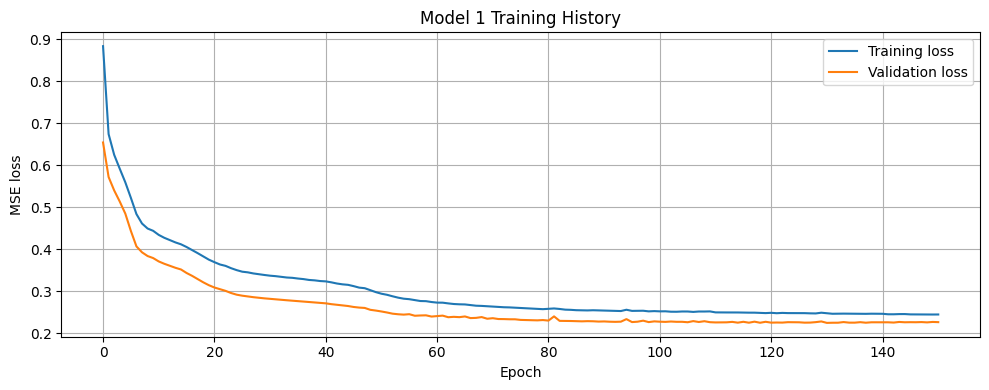

In [ ]:
# Plot training and validation loss

plt.figure(figsize=(10, 4))

plt.plot(history_1.history["loss"], label="Training loss")
plt.plot(history_1.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Model 1 Training History")

plt.legend()
plt.grid(True)
plt.tight_layout()

if SAVE_ARTIFACTS:
    plt.savefig(
        save_path(
            "results/training_history/"
            "31_model_1_training_history.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

plt.show()

**Сохранение обученной модели № 1**

In [ ]:
if SAVE_ARTIFACTS:
    model_1.save(
        save_path(
            "models/autoencoders/41_model_1.keras"
        )
    )

**Эксперимент 1.1 - Оценка работы модели с эвристическим порогом ошибки реконструкции**

In [ ]:
# Reconstruction errors on the Validation set
val_recon_1 = model_1.predict(X_val, verbose=0)

val_mse_1 = np.mean(
    np.square(X_val - val_recon_1),
    axis=1
)

# Heuristic threshold: mean + 2 standard deviations
threshold_heur_1 = np.mean(val_mse_1) + 2 * np.std(val_mse_1)

# Reconstruction errors on the Calibration set
calibration_recon_1 = model_1.predict(
    X_calibration,
    verbose=0
)

calibration_mse_1 = np.mean(
    np.square(X_calibration - calibration_recon_1),
    axis=1
)

print(f"Heuristic threshold: {threshold_heur_1:.6f}")
print(f"Mean Validation MSE:  {np.mean(val_mse_1):.6f}")
print(f"Std Validation MSE:   {np.std(val_mse_1):.6f}")

Heuristic threshold: 2.146864
Mean Validation MSE:  0.224297
Std Validation MSE:   0.961284


In [ ]:
# Predictions on the Calibration set
y_pred_heur_1 = (
    calibration_mse_1 > threshold_heur_1
).astype(int)

print("=== Calibration Classification Report ===")
print(
    classification_report(
        y_calibration,
        y_pred_heur_1,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

print(
    f"AUC-ROC: "
    f"{roc_auc_score(y_calibration, calibration_mse_1):.4f}"
)

print()
print("=== Calibration Confusion Matrix ===")

cm_heur_1 = confusion_matrix(
    y_calibration,
    y_pred_heur_1
)

print(cm_heur_1)

=== Calibration Classification Report ===
              precision    recall  f1-score   support

      Normal       0.91      0.99      0.95      6506
       Fraud       0.53      0.07      0.12       697

    accuracy                           0.90      7203
   macro avg       0.72      0.53      0.53      7203
weighted avg       0.87      0.90      0.87      7203

AUC-ROC: 0.7353

=== Calibration Confusion Matrix ===
[[6465   41]
 [ 650   47]]


**Вывод по результатам эксперимента 1.1**

Эвристический пороговый уровень приводит к низкой частоте ложных срабатываний, но обнаруживает лишь небольшую долю мошеннических транзакций. На калибровочном наборе данных Модель 1 идентифицирует 47 из 697 мошеннических транзакций, что соответствует показателю полноты обнаружения мошенничества приблизительно 0,07 и показателю точности обнаружения мошенничества приблизительно 0,53. Таким образом, эвристический пороговый уровень представляет собой чрезмерно ограничительную рабочую точку для Модели 1.

**Эксперимент 1.2 - Оценка с использованием порога ошибки реконструкции, оптимизированного по F1**

In [ ]:
threshold_opt_1, best_f1_1 = select_f1_optimal_threshold(
    y_calibration,
    calibration_mse_1
)

print(f"Optimized threshold: {threshold_opt_1:.6f}")
print(f"Best Calibration Fraud F1: {best_f1_1:.4f}")
print()

Optimized threshold: 1.868172
Best Calibration Fraud F1: 0.4659



In [ ]:
# Predictions on the Calibration set using the optimized threshold
y_pred_opt_1 = (
    calibration_mse_1 >= threshold_opt_1
).astype(int)

print("=== Calibration Classification Report ===")
print(
    classification_report(
        y_calibration,
        y_pred_opt_1,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

print(
    f"AUC-ROC: "
    f"{roc_auc_score(y_calibration, calibration_mse_1):.4f}"
)

print()
print("=== Calibration Confusion Matrix ===")

cm_opt_1 = confusion_matrix(
    y_calibration,
    y_pred_opt_1
)

print(cm_opt_1)

=== Calibration Classification Report ===
              precision    recall  f1-score   support

      Normal       0.93      0.99      0.96      6506
       Fraud       0.80      0.33      0.47       697

    accuracy                           0.93      7203
   macro avg       0.87      0.66      0.71      7203
weighted avg       0.92      0.93      0.91      7203

AUC-ROC: 0.7353

=== Calibration Confusion Matrix ===
[[6449   57]
 [ 468  229]]


**Вывод по результатам эксперимента 1.2**

Оптимизация порога ошибки реконструкции на калибровочном наборе существенно улучшает зависящие от порога показатели обнаружения аномалий. Fraud Recall увеличивается примерно с 0,07 до 0,33, а Fraud Precision — примерно с 0,53 до 0,80. В результате Fraud F1 увеличивается примерно с 0,12 до 0,47.

AUC-ROC остается неизменным на уровне 0,7353, поскольку эта метрика не зависит от порога классификации и характеризует общую способность модели ранжировать транзакции по степени аномальности, а не качество классификации в конкретной рабочей точке.

## 3.3 Модель № 2

Модель 2 расширяет Модель 1 за счет увеличения глубины и ширины автокодировщика и добавления регуляризации Dropout.

**Создание модели № 2**

In [ ]:
# Reset random seed before model initialization
reset_seed()

# Input layer
inputs_2 = keras.Input(shape=(INPUT_DIM,), name="input")

# Encoder
x = layers.Dense(64, activation="relu", name="encoder_dense_1")(inputs_2)
x = layers.Dropout(0.2, name="encoder_dropout_1")(x)

x = layers.Dense(32, activation="relu", name="encoder_dense_2")(x)
x = layers.Dropout(0.2, name="encoder_dropout_2")(x)

x = layers.Dense(16, activation="relu", name="encoder_dense_3")(x)

# Bottleneck
bottleneck_2 = layers.Dense(8, activation="relu", name="bottleneck")(x)

# Decoder
x = layers.Dense(16, activation="relu", name="decoder_dense_1")(bottleneck_2)
x = layers.Dropout(0.2, name="decoder_dropout_1")(x)

x = layers.Dense(32, activation="relu", name="decoder_dense_2")(x)
x = layers.Dropout(0.2, name="decoder_dropout_2")(x)

x = layers.Dense(64, activation="relu", name="decoder_dense_3")(x)

# Output layer
outputs_2 = layers.Dense(
    INPUT_DIM,
    activation="linear",
    name="output"
)(x)

model_2 = keras.Model(
    inputs=inputs_2,
    outputs=outputs_2,
    name="autoencoder_model_2"
)

model_2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse"
)

model_2.summary()

Model: "autoencoder_model_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 21)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_1 (Dense)         │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_1 (Dropout)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_2 (Dense)         │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_2 (Dropout)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_3 (Dense)         │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout_1 (Dropout)     │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_2 (Dense)         │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout_2 (Dropout)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_3 (Dense)         │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 21)             │         1,365 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,317 (32.49 KB)

 Trainable params: 8,317 (32.49 KB)

 Non-trainable params: 0 (0.00 B)

**Обучение модели № 2**

In [ ]:
early_stopping_2 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOP_PATIENCE,
    restore_best_weights=True
)

history_2 = model_2.fit(
    X_train,
    X_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, X_val),
    callbacks=[early_stopping_2],
    verbose=1
)
best_epoch_2 = int(np.argmin(history_2.history["val_loss"]) + 1)

print()
print(f"Training epochs completed: {len(history_2.history['loss'])}")
print(f"Best epoch by Validation loss: {best_epoch_2}")

Epoch 1/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.8150 - val_loss: 0.5130
Epoch 2/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.6019 - val_loss: 0.4194
Epoch 3/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.5274 - val_loss: 0.3392
Epoch 4/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.4921 - val_loss: 0.3209
Epoch 5/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.4733 - val_loss: 0.3123
Epoch 6/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.4538 - val_loss: 0.3013
Epoch 7/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.4410 - val_loss: 0.2968
Epoch 8/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.4207 - val_loss: 0.2890
Epoch 9/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.4156 - val_loss: 0.2776
Epoch 10/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.4074 - val_loss: 0.2683
Epoch 11/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.3919 - val_loss: 0.2641
Epoch 12/300
238/238 ━━━━━━━━━━━━━━━━━

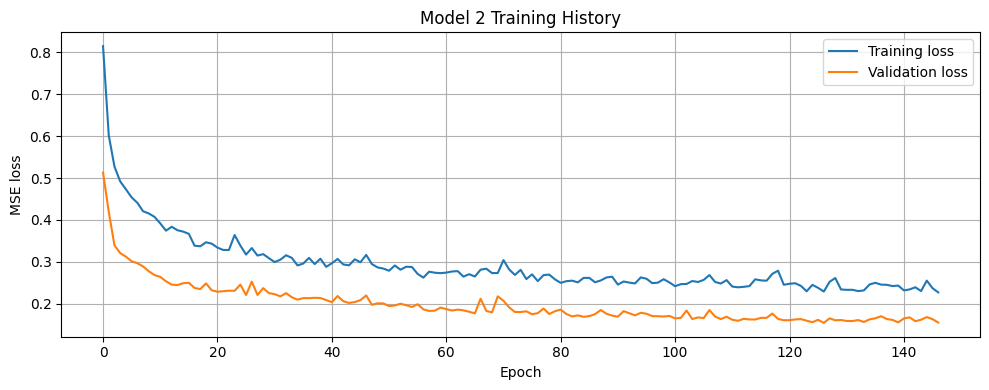

In [ ]:
# Plot training and validation loss

plt.figure(figsize=(10, 4))

plt.plot(history_2.history["loss"], label="Training loss")
plt.plot(history_2.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Model 2 Training History")
plt.legend()
plt.grid(True)
plt.tight_layout()

if SAVE_ARTIFACTS:
    plt.savefig(
        save_path(
            "results/training_history/"
            "32_model_2_training_history.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

plt.show()

**Сохранение обученной модели № 2**

In [ ]:
if SAVE_ARTIFACTS:
    model_2.save(
        save_path(
            "models/autoencoders/42_model_2.keras"
        )
    )

**Эксперимент 2.1 - Оценка работы модели с эвристическим порогом ошибки реконструкции**

In [ ]:
# Reconstruction errors on the Validation set
val_recon_2 = model_2.predict(X_val, verbose=0)

val_mse_2 = np.mean(
    np.square(X_val - val_recon_2),
    axis=1
)

# Heuristic threshold: mean + 2 standard deviations
threshold_heur_2 = np.mean(val_mse_2) + 2 * np.std(val_mse_2)

# Reconstruction errors on the Calibration set
calibration_recon_2 = model_2.predict(
    X_calibration,
    verbose=0
)

calibration_mse_2 = np.mean(
    np.square(X_calibration - calibration_recon_2),
    axis=1
)

print(f"Heuristic threshold: {threshold_heur_2:.6f}")
print(f"Mean Validation MSE:  {np.mean(val_mse_2):.6f}")
print(f"Std Validation MSE:   {np.std(val_mse_2):.6f}")

Heuristic threshold: 1.521816
Mean Validation MSE:  0.154248
Std Validation MSE:   0.683784


In [ ]:
# Predictions on the Calibration set
y_pred_heur_2 = (
    calibration_mse_2 > threshold_heur_2
).astype(int)

print("=== Calibration Classification Report ===")
print(
    classification_report(
        y_calibration,
        y_pred_heur_2,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

print(
    f"AUC-ROC: "
    f"{roc_auc_score(y_calibration, calibration_mse_2):.4f}"
)

print()
print("=== Calibration Confusion Matrix ===")

cm_heur_2 = confusion_matrix(
    y_calibration,
    y_pred_heur_2
)

print(cm_heur_2)

=== Calibration Classification Report ===
              precision    recall  f1-score   support

      Normal       0.91      0.99      0.95      6506
       Fraud       0.53      0.08      0.13       697

    accuracy                           0.90      7203
   macro avg       0.72      0.53      0.54      7203
weighted avg       0.87      0.90      0.87      7203

AUC-ROC: 0.7631

=== Calibration Confusion Matrix ===
[[6459   47]
 [ 644   53]]


**Вывод по результатам эксперимента 2.1**

Эвристический пороговый уровень приводит к низкой частоте ложных срабатываний, но обнаруживает лишь небольшую долю мошеннических транзакций. На калибровочном наборе данных Модель 2 идентифицирует 53 из 697 мошеннических транзакций, что соответствует показателю полноты обнаружения мошенничества приблизительно 0,08 и показателю точности обнаружения мошенничества приблизительно 0,53. Таким образом, полученная рабочая точка является чрезмерно ограничительной для Модели 2.

**Эксперимент 2.2 - Оценка с использованием порога ошибки реконструкции, оптимизированного по F1**

In [ ]:
threshold_opt_2, best_f1_2 = select_f1_optimal_threshold(
    y_calibration,
    calibration_mse_2
)

print(f"Optimized threshold: {threshold_opt_2:.6f}")
print(f"Best Calibration Fraud F1: {best_f1_2:.4f}")
print()

Optimized threshold: 1.133180
Best Calibration Fraud F1: 0.4646



In [ ]:
# Predictions on the Calibration set using the optimized threshold
y_pred_opt_2 = (
    calibration_mse_2 >= threshold_opt_2
).astype(int)

print("=== Calibration Classification Report ===")
print(
    classification_report(
        y_calibration,
        y_pred_opt_2,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

print(
    f"AUC-ROC: "
    f"{roc_auc_score(y_calibration, calibration_mse_2):.4f}"
)

print()
print("=== Calibration Confusion Matrix ===")

cm_opt_2 = confusion_matrix(
    y_calibration,
    y_pred_opt_2
)

print(cm_opt_2)

=== Calibration Classification Report ===
              precision    recall  f1-score   support

      Normal       0.93      0.99      0.96      6506
       Fraud       0.76      0.33      0.46       697

    accuracy                           0.93      7203
   macro avg       0.85      0.66      0.71      7203
weighted avg       0.92      0.93      0.91      7203

AUC-ROC: 0.7631

=== Calibration Confusion Matrix ===
[[6433   73]
 [ 464  233]]


**Вывод по результатам эксперимента 2.2**

Оптимизация порога ошибки реконструкции на калибровочном наборе существенно улучшает зависящие от порога показатели обнаружения аномалий. Fraud Recall увеличивается примерно с 0,08 до 0,33, а Fraud Precision — примерно с 0,53 до 0,76. В результате Fraud F1 увеличивается примерно с 0,13 до 0,46.

AUC-ROC остается неизменным на уровне 0,7631, поскольку эта метрика не зависит от порога классификации и характеризует общую способность модели ранжировать транзакции по степени аномальности, а не качество классификации в конкретной рабочей точке.

**Общий вывод по результатам оценки модели 2**

По сравнению с моделью 1 модель 2 демонстрирует более высокое значение AUC-ROC на калибровочном наборе: 0,7631 против 0,7353. Это указывает на улучшение общей способности модели ранжировать мошеннические и нормальные транзакции по ошибке реконструкции.

При оптимизированном по Fraud F1 пороге значения Fraud Recall и Fraud F1 у моделей 1 и 2 остаются практически одинаковыми: Fraud Recall составляет приблизительно 0,33, а Fraud F1 — приблизительно 0,47. При этом Fraud Precision у модели 2 несколько ниже — приблизительно 0,76 против 0,80 у модели 1. Таким образом, увеличение глубины и ширины архитектуры совместно с добавлением Dropout улучшает независимую от порога способность модели к ранжированию, но не обеспечивает улучшения Fraud F1 в выбранной рабочей точке.

Следующий эксперимент оценивает, может ли добавление BatchNormalization дополнительно улучшить качество модели.

## 3.4 Модель № 3

Модель 3 расширяет Модель 2 за счет добавления слоев пакетной нормализации, сохраняя при этом остальную архитектуру и коэффициент регуляризации Dropout

**Создание модели № 3**

In [ ]:
# Reset random seed before model initialization
reset_seed()

# Input layer
inputs_3 = keras.Input(shape=(INPUT_DIM,), name="input")

# Encoder
x = layers.Dense(64, activation="relu", name="encoder_dense_1")(inputs_3)
x = layers.BatchNormalization(name="encoder_batch_norm_1")(x)
x = layers.Dropout(0.2, name="encoder_dropout_1")(x)

x = layers.Dense(32, activation="relu", name="encoder_dense_2")(x)
x = layers.BatchNormalization(name="encoder_batch_norm_2")(x)
x = layers.Dropout(0.2, name="encoder_dropout_2")(x)

x = layers.Dense(16, activation="relu", name="encoder_dense_3")(x)

# Bottleneck
bottleneck_3 = layers.Dense(8, activation="relu", name="bottleneck")(x)

# Decoder
x = layers.Dense(16, activation="relu", name="decoder_dense_1")(bottleneck_3)
x = layers.BatchNormalization(name="decoder_batch_norm_1")(x)
x = layers.Dropout(0.2, name="decoder_dropout_1")(x)

x = layers.Dense(32, activation="relu", name="decoder_dense_2")(x)
x = layers.BatchNormalization(name="decoder_batch_norm_2")(x)
x = layers.Dropout(0.2, name="decoder_dropout_2")(x)

x = layers.Dense(64, activation="relu", name="decoder_dense_3")(x)

# Output layer
outputs_3 = layers.Dense(
    INPUT_DIM,
    activation="linear",
    name="output"
)(x)

model_3 = keras.Model(
    inputs=inputs_3,
    outputs=outputs_3,
    name="autoencoder_model_3"
)

model_3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse"
)

model_3.summary()

Model: "autoencoder_model_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 21)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_1 (Dense)         │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_batch_norm_1            │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_1 (Dropout)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_2 (Dense)         │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_batch_norm_2            │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_2 (Dropout)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_3 (Dense)         │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_batch_norm_1            │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout_1 (Dropout)     │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_2 (Dense)         │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_batch_norm_2            │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout_2 (Dropout)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_3 (Dense)         │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 21)             │         1,365 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,893 (34.74 KB)

 Trainable params: 8,605 (33.61 KB)

 Non-trainable params: 288 (1.12 KB)

**Обучение модели № 3**

In [ ]:
early_stopping_3 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOP_PATIENCE,
    restore_best_weights=True
)

history_3 = model_3.fit(
    X_train,
    X_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, X_val),
    callbacks=[early_stopping_3],
    verbose=1
)
best_epoch_3 = int(np.argmin(history_3.history["val_loss"]) + 1)

print()
print(f"Training epochs completed: {len(history_3.history['loss'])}")
print(f"Best epoch by Validation loss: {best_epoch_3}")

Epoch 1/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.8666 - val_loss: 0.4877
Epoch 2/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.5982 - val_loss: 0.3342
Epoch 3/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.5297 - val_loss: 0.2937
Epoch 4/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.4805 - val_loss: 0.2659
Epoch 5/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.4576 - val_loss: 0.2496
Epoch 6/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.4389 - val_loss: 0.2342
Epoch 7/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.4240 - val_loss: 0.2210
Epoch 8/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.4111 - val_loss: 0.2043
Epoch 9/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.3967 - val_loss: 0.1949
Epoch 10/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.3748 - val_loss: 0.1941
Epoch 11/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.3582 - val_loss: 0.1971
Epoch 12/300
238/238 ━━━━━━━━━

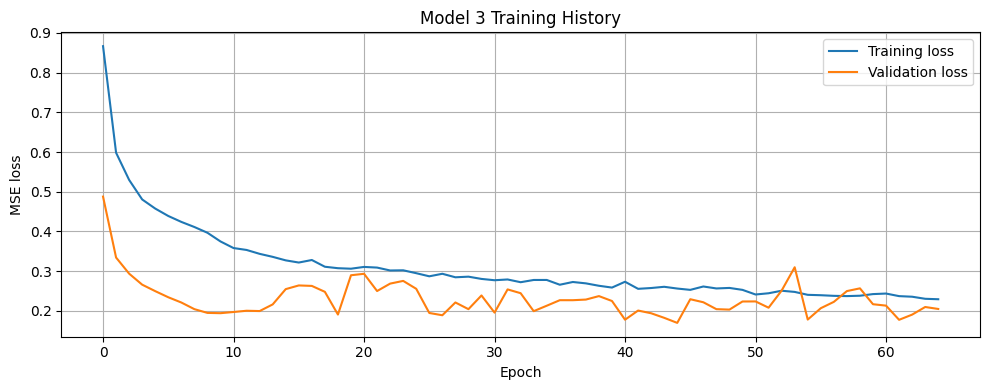

In [ ]:
# Plot training and validation loss

plt.figure(figsize=(10, 4))

plt.plot(history_3.history["loss"], label="Training loss")
plt.plot(history_3.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Model 3 Training History")
plt.legend()
plt.grid(True)
plt.tight_layout()

if SAVE_ARTIFACTS:
    plt.savefig(
        save_path(
            "results/training_history/"
            "33_model_3_training_history.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

plt.show()

**Сохранение обученной модели № 3**

In [ ]:
if SAVE_ARTIFACTS:
    model_3.save(
        save_path(
            "models/autoencoders/43_model_3.keras"
        )
    )

**Эксперимент 3.1 - Оценка работы модели с эвристическим порогом ошибки реконструкции**

In [ ]:
# Reconstruction errors on the Validation set
val_recon_3 = model_3.predict(X_val, verbose=0)

val_mse_3 = np.mean(
    np.square(X_val - val_recon_3),
    axis=1
)

# Heuristic threshold: mean + 2 standard deviations
threshold_heur_3 = np.mean(val_mse_3) + 2 * np.std(val_mse_3)

# Reconstruction errors on the Calibration set
calibration_recon_3 = model_3.predict(
    X_calibration,
    verbose=0
)

calibration_mse_3 = np.mean(
    np.square(X_calibration - calibration_recon_3),
    axis=1
)

print(f"Heuristic threshold: {threshold_heur_3:.6f}")
print(f"Mean Validation MSE:  {np.mean(val_mse_3):.6f}")
print(f"Std Validation MSE:   {np.std(val_mse_3):.6f}")

Heuristic threshold: 6.772716
Mean Validation MSE:  0.169701
Std Validation MSE:   3.301508


In [ ]:
# Predictions on the Calibration set
y_pred_heur_3 = (
    calibration_mse_3 > threshold_heur_3
).astype(int)

print("=== Calibration Classification Report ===")
print(
    classification_report(
        y_calibration,
        y_pred_heur_3,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

print(
    f"AUC-ROC: "
    f"{roc_auc_score(y_calibration, calibration_mse_3):.4f}"
)

print()
print("=== Calibration Confusion Matrix ===")

cm_heur_3 = confusion_matrix(
    y_calibration,
    y_pred_heur_3
)

print(cm_heur_3)

=== Calibration Classification Report ===
              precision    recall  f1-score   support

      Normal       0.91      1.00      0.95      6506
       Fraud       0.83      0.04      0.08       697

    accuracy                           0.91      7203
   macro avg       0.87      0.52      0.52      7203
weighted avg       0.90      0.91      0.87      7203

AUC-ROC: 0.8196

=== Calibration Confusion Matrix ===
[[6500    6]
 [ 667   30]]


**Вывод по результатам эксперимента 3.1**

Эвристический пороговый уровень обеспечивает очень низкий уровень ложноположительных результатов, но выявляет лишь небольшую долю мошеннических транзакций. На калибровочном наборе данных модель 3 идентифицирует 30 из 697 мошеннических транзакций, что соответствует показателю полноты обнаружения мошенничества приблизительно 0,04. Следовательно, эвристический пороговый уровень представляет собой чрезмерно ограничительную рабочую точку для этой модели.


**Эксперимент 3.2 - Оценка с использованием порога ошибки реконструкции, оптимизированного по F1**

In [ ]:
threshold_opt_3, best_f1_3 = select_f1_optimal_threshold(
    y_calibration,
    calibration_mse_3
)

print(f"Optimized threshold: {threshold_opt_3:.6f}")
print(f"Best Calibration Fraud F1: {best_f1_3:.4f}")
print()

Optimized threshold: 1.194232
Best Calibration Fraud F1: 0.4615



In [ ]:
# Predictions on the Calibration set using the optimized threshold
y_pred_opt_3 = (
    calibration_mse_3 >= threshold_opt_3
).astype(int)

print("=== Calibration Classification Report ===")
print(
    classification_report(
        y_calibration,
        y_pred_opt_3,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

print(
    f"AUC-ROC: "
    f"{roc_auc_score(y_calibration, calibration_mse_3):.4f}"
)

print()
print("=== Calibration Confusion Matrix ===")

cm_opt_3 = confusion_matrix(
    y_calibration,
    y_pred_opt_3
)

print(cm_opt_3)

=== Calibration Classification Report ===
              precision    recall  f1-score   support

      Normal       0.93      0.99      0.96      6506
       Fraud       0.78      0.33      0.46       697

    accuracy                           0.93      7203
   macro avg       0.86      0.66      0.71      7203
weighted avg       0.92      0.93      0.91      7203

AUC-ROC: 0.8196

=== Calibration Confusion Matrix ===
[[6443   63]
 [ 469  228]]


**Вывод по результатам эксперимента 3.2**

Оптимизация порога ошибки реконструкции на калибровочном наборе существенно увеличивает Fraud Recall примерно с 0,04 до 0,33 и Fraud F1 примерно с 0,08 до 0,46. Это сопровождается небольшим снижением Fraud Precision примерно с 0,83 до 0,78, поскольку при более низком пороге больше транзакций классифицируется как аномальные.

AUC-ROC остается неизменным на уровне 0,8196, поскольку эта метрика не зависит от порога классификации и характеризует общую способность модели ранжировать транзакции по степени аномальности.

**Общий вывод по результатам оценки модели 3**

По сравнению с моделью 2 добавление BatchNormalization существенно улучшает качество ранжирования на калибровочном наборе: AUC-ROC увеличивается с 0,7631 до 0,8196.

При оптимизированном по Fraud F1 пороге значения зависящих от порога метрик изменяются незначительно. Fraud Precision увеличивается приблизительно с 0,76 до 0,78, Fraud Recall немного снижается с 0,33 до 0,33 в округленном представлении, а Fraud F1 остается на уровне около 0,46.

Таким образом, в рассматриваемой конфигурации BatchNormalization существенно улучшает независимую от порога способность модели ранжировать нормальные и мошеннические транзакции, но не обеспечивает сопоставимого улучшения метрик классификации в выбранной рабочей точке.

В следующем эксперименте оценивается влияние добавления механизма внимания к архитектуре автокодировщика.

# 4 Автокодировщики с механизмом внимания

## 4.1 Создание слоя внимания

In [ ]:
@keras.utils.register_keras_serializable(package="AE_XAI_Ethereum")
class AttentionLayer(layers.Layer):
    """Trainable attention-based weighting of hidden representations."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        hidden_dim = int(input_shape[-1])

        self.W = self.add_weight(
            shape=(hidden_dim, hidden_dim),
            initializer="glorot_uniform",
            trainable=True,
            name="attention_weights"
        )

        self.b = self.add_weight(
            shape=(hidden_dim,),
            initializer="zeros",
            trainable=True,
            name="attention_bias"
        )

        super().build(input_shape)

    def call(self, inputs):
        scores = tf.nn.tanh(
            tf.matmul(inputs, self.W) + self.b
        )

        attention_weights = tf.nn.softmax(
            scores,
            axis=-1
        )

        return inputs * attention_weights

    def get_config(self):
        return super().get_config()

print(
    "AttentionLayer defined and registered successfully."
)

## 4.2 Модель № 4

Модель 4 расширяет Модель 3, добавляя слой внимания (AttentionLayer) между финальным слоем кодировщика и слоем сжатого представления. Все остальные архитектурные компоненты и параметры обучения сохраняются, чтобы изолировать эффект механизма внимания.

**Создание модели № 4**

In [ ]:
# Reset random seed before model initialization
reset_seed()

# Input layer
inputs_4 = keras.Input(shape=(INPUT_DIM,), name="input")

# Encoder
x = layers.Dense(64, activation="relu", name="encoder_dense_1")(inputs_4)
x = layers.BatchNormalization(name="encoder_batch_norm_1")(x)
x = layers.Dropout(0.2, name="encoder_dropout_1")(x)

x = layers.Dense(32, activation="relu", name="encoder_dense_2")(x)
x = layers.BatchNormalization(name="encoder_batch_norm_2")(x)
x = layers.Dropout(0.2, name="encoder_dropout_2")(x)

x = layers.Dense(16, activation="relu", name="encoder_dense_3")(x)

# Attention layer
attention_4 = AttentionLayer(name="attention")(x)

# Bottleneck
bottleneck_4 = layers.Dense(
    8,
    activation="relu",
    name="bottleneck"
)(attention_4)

# Decoder
x = layers.Dense(16, activation="relu", name="decoder_dense_1")(bottleneck_4)
x = layers.BatchNormalization(name="decoder_batch_norm_1")(x)
x = layers.Dropout(0.2, name="decoder_dropout_1")(x)

x = layers.Dense(32, activation="relu", name="decoder_dense_2")(x)
x = layers.BatchNormalization(name="decoder_batch_norm_2")(x)
x = layers.Dropout(0.2, name="decoder_dropout_2")(x)

x = layers.Dense(64, activation="relu", name="decoder_dense_3")(x)

# Output layer
outputs_4 = layers.Dense(
    INPUT_DIM,
    activation="linear",
    name="output"
)(x)

model_4 = keras.Model(
    inputs=inputs_4,
    outputs=outputs_4,
    name="autoencoder_model_4"
)

model_4.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse"
)

model_4.summary()

Model: "autoencoder_model_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 21)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_1 (Dense)         │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_batch_norm_1            │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_1 (Dropout)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_2 (Dense)         │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_batch_norm_2            │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_2 (Dropout)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_3 (Dense)         │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (AttentionLayer)      │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_batch_norm_1            │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout_1 (Dropout)     │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_2 (Dense)         │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_batch_norm_2            │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout_2 (Dropout)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_3 (Dense)         │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 21)             │         1,365 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,165 (35.80 KB)

 Trainable params: 8,877 (34.68 KB)

 Non-trainable params: 288 (1.12 KB)

**Обучение модели № 4**

In [ ]:
early_stopping_4 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOP_PATIENCE,
    restore_best_weights=True
)

history_4 = model_4.fit(
    X_train,
    X_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, X_val),
    callbacks=[early_stopping_4],
    verbose=1
)

best_epoch_4 = int(np.argmin(history_4.history["val_loss"]) + 1)

print()
print(f"Training epochs completed: {len(history_4.history['loss'])}")
print(f"Best epoch by Validation loss: {best_epoch_4}")

Epoch 1/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.8752 - val_loss: 0.7915
Epoch 2/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.6084 - val_loss: 0.4553
Epoch 3/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.5121 - val_loss: 0.3028
Epoch 4/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.4605 - val_loss: 0.2479
Epoch 5/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.4262 - val_loss: 0.2608
Epoch 6/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.4042 - val_loss: 0.2682
Epoch 7/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.3755 - val_loss: 0.2550
Epoch 8/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.3643 - val_loss: 0.3152
Epoch 9/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.3440 - val_loss: 0.2547
Epoch 10/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3290 - val_loss: 0.2517
Epoch 11/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.3184 - val_loss: 0.2493
Epoch 12/300
238/238 ━━━━━━━━━

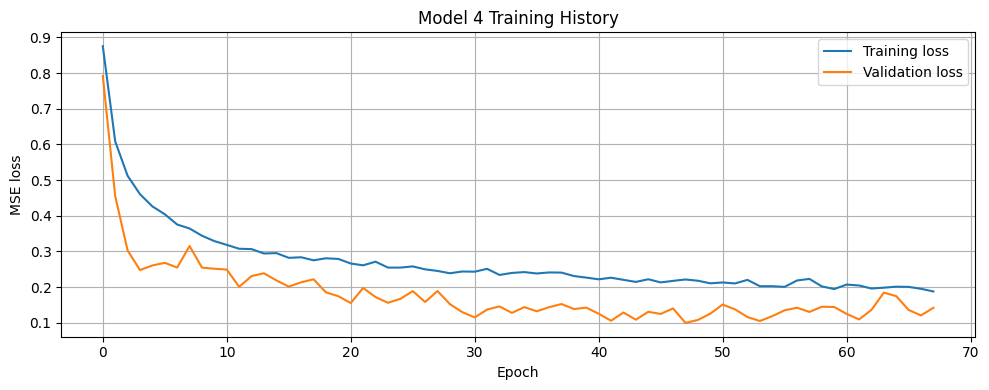

In [ ]:
# Plot training and validation loss

plt.figure(figsize=(10, 4))

plt.plot(history_4.history["loss"], label="Training loss")
plt.plot(history_4.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Model 4 Training History")
plt.legend()
plt.grid(True)
plt.tight_layout()

if SAVE_ARTIFACTS:
    plt.savefig(
        save_path(
            "results/training_history/"
            "34_model_4_training_history.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

plt.show()

**Сохранение обученной модели № 4**

In [ ]:
if SAVE_ARTIFACTS:
    model_4.save(
        save_path(
            "models/autoencoders/44_model_4.keras"
        )
    )

**Эксперимент 4.1 - Оценка работы модели с эвристическим порогом ошибки реконструкции**

In [ ]:
# Reconstruction errors on the Validation set
val_recon_4 = model_4.predict(X_val, verbose=0)

val_mse_4 = np.mean(
    np.square(X_val - val_recon_4),
    axis=1
)

# Heuristic threshold: mean + 2 standard deviations
threshold_heur_4 = np.mean(val_mse_4) + 2 * np.std(val_mse_4)

# Reconstruction errors on the Calibration set
calibration_recon_4 = model_4.predict(
    X_calibration,
    verbose=0
)

calibration_mse_4 = np.mean(
    np.square(X_calibration - calibration_recon_4),
    axis=1
)

print(f"Heuristic threshold: {threshold_heur_4:.6f}")
print(f"Mean Validation MSE:  {np.mean(val_mse_4):.6f}")
print(f"Std Validation MSE:   {np.std(val_mse_4):.6f}")

Heuristic threshold: 2.702257
Mean Validation MSE:  0.099899
Std Validation MSE:   1.301179


In [ ]:
# Predictions on the Calibration set
y_pred_heur_4 = (
    calibration_mse_4 > threshold_heur_4
).astype(int)

print("=== Calibration Classification Report ===")
print(
    classification_report(
        y_calibration,
        y_pred_heur_4,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

print(
    f"AUC-ROC: "
    f"{roc_auc_score(y_calibration, calibration_mse_4):.4f}"
)

print()
print("=== Calibration Confusion Matrix ===")

cm_heur_4 = confusion_matrix(
    y_calibration,
    y_pred_heur_4
)

print(cm_heur_4)

=== Calibration Classification Report ===
              precision    recall  f1-score   support

      Normal       0.91      1.00      0.95      6506
       Fraud       0.73      0.05      0.09       697

    accuracy                           0.91      7203
   macro avg       0.82      0.52      0.52      7203
weighted avg       0.89      0.91      0.87      7203

AUC-ROC: 0.8030

=== Calibration Confusion Matrix ===
[[6494   12]
 [ 665   32]]


**Вывод по результатам эксперимента 4.1**

Эвристический пороговый уровень обеспечивает низкий уровень ложноположительных результатов, но выявляет лишь небольшую долю мошеннических транзакций. На калибровочном наборе данных модель 4 выявила 32 из 697 мошеннических транзакций, что соответствует показателю полноты обнаружения мошенничества приблизительно 0,05. Следовательно, эвристический пороговый уровень является чрезмерно ограничительной рабочей точкой для этой модели.

**Эксперимент 4.2 - Оценка с использованием порога ошибки реконструкции, оптимизированного по F1**

In [ ]:
threshold_opt_4, best_f1_4 = select_f1_optimal_threshold(
    y_calibration,
    calibration_mse_4
)

print(f"Optimized threshold: {threshold_opt_4:.6f}")
print(f"Best Calibration Fraud F1: {best_f1_4:.4f}")
print()

Optimized threshold: 1.162520
Best Calibration Fraud F1: 0.4750



In [ ]:
# Predictions on the Calibration set using the optimized threshold
y_pred_opt_4 = (
    calibration_mse_4 >= threshold_opt_4
).astype(int)

print("=== Calibration Classification Report ===")
print(
    classification_report(
        y_calibration,
        y_pred_opt_4,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

print(
    f"AUC-ROC: "
    f"{roc_auc_score(y_calibration, calibration_mse_4):.4f}"
)

print()
print("=== Calibration Confusion Matrix ===")

cm_opt_4 = confusion_matrix(
    y_calibration,
    y_pred_opt_4
)

print(cm_opt_4)

=== Calibration Classification Report ===
              precision    recall  f1-score   support

      Normal       0.93      0.99      0.96      6506
       Fraud       0.87      0.33      0.47       697

    accuracy                           0.93      7203
   macro avg       0.90      0.66      0.72      7203
weighted avg       0.93      0.93      0.92      7203

AUC-ROC: 0.8030

=== Calibration Confusion Matrix ===
[[6471   35]
 [ 469  228]]


**Вывод по результатам эксперимента 4.2**

Оптимизация порога ошибки реконструкции на калибровочном наборе существенно улучшает зависящие от порога показатели обнаружения аномалий. Fraud Recall увеличивается примерно с 0,05 до 0,33, а Fraud Precision — примерно с 0,73 до 0,87. В результате Fraud F1 увеличивается примерно с 0,09 до 0,47.

AUC-ROC остается неизменным на уровне 0,8030, поскольку эта метрика не зависит от порога классификации и характеризует общую способность модели ранжировать транзакции по степени аномальности.

**Общий вывод по результатам оценки модели 4**

По сравнению с моделью 3 добавление AttentionLayer снижает AUC-ROC с 0,8196 до 0,8030, что указывает на небольшое ухудшение общей способности модели ранжировать транзакции по значению ошибки реконструкции.

Вместе с тем при оптимизированном по Fraud F1 пороге модель 4 достигает более высокого Fraud Precision — приблизительно 0,87 против 0,78 у модели 3 — при практически одинаковом Fraud Recall, составляющем приблизительно 0,33. Количество ложноположительных срабатываний уменьшается с 63 до 35, а Fraud F1 увеличивается приблизительно с 0,46 до 0,47.

Таким образом, в рассматриваемой конфигурации добавление AttentionLayer улучшает Fraud Precision и Fraud F1 в выбранной рабочей точке, но не улучшает независимую от порога способность модели к ранжированию.

## 4.3 Модель № 5

В модели 5 пакетная нормализация удалена из модели 4, при этом сохраняется слой внимания (AttentionLayer) и остальная архитектура. Такая конфигурация позволяет изучить взаимодействие между пакетной нормализацией и механизмом внимания, а также обеспечивает прямое сравнение с моделью 2, от которой модель 5 отличается только наличием слоя внимания (AttentionLayer).

**Создание модели № 5**

In [ ]:
# Reset random seed before model initialization
reset_seed()

# Input layer
inputs_5 = keras.Input(shape=(INPUT_DIM,), name="input")

# Encoder
x = layers.Dense(64, activation="relu", name="encoder_dense_1")(inputs_5)
x = layers.Dropout(0.2, name="encoder_dropout_1")(x)

x = layers.Dense(32, activation="relu", name="encoder_dense_2")(x)
x = layers.Dropout(0.2, name="encoder_dropout_2")(x)

x = layers.Dense(16, activation="relu", name="encoder_dense_3")(x)

# Attention layer
attention_5 = AttentionLayer(name="attention")(x)

# Bottleneck
bottleneck_5 = layers.Dense(
    8,
    activation="relu",
    name="bottleneck"
)(attention_5)

# Decoder
x = layers.Dense(16, activation="relu", name="decoder_dense_1")(bottleneck_5)
x = layers.Dropout(0.2, name="decoder_dropout_1")(x)

x = layers.Dense(32, activation="relu", name="decoder_dense_2")(x)
x = layers.Dropout(0.2, name="decoder_dropout_2")(x)

x = layers.Dense(64, activation="relu", name="decoder_dense_3")(x)

# Output layer
outputs_5 = layers.Dense(
    INPUT_DIM,
    activation="linear",
    name="output"
)(x)

model_5 = keras.Model(
    inputs=inputs_5,
    outputs=outputs_5,
    name="autoencoder_model_5"
)

model_5.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse"
)

model_5.summary()

Model: "autoencoder_model_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 21)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_1 (Dense)         │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_1 (Dropout)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_2 (Dense)         │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_2 (Dropout)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_3 (Dense)         │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (AttentionLayer)      │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout_1 (Dropout)     │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_2 (Dense)         │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout_2 (Dropout)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_3 (Dense)         │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 21)             │         1,365 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,589 (33.55 KB)

 Trainable params: 8,589 (33.55 KB)

 Non-trainable params: 0 (0.00 B)

**Обучение модели № 5**

In [ ]:
early_stopping_5 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOP_PATIENCE,
    restore_best_weights=True
)

history_5 = model_5.fit(
    X_train,
    X_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, X_val),
    callbacks=[early_stopping_5],
    verbose=1
)

best_epoch_5 = int(np.argmin(history_5.history["val_loss"]) + 1)

print()
print(f"Training epochs completed: {len(history_5.history['loss'])}")
print(f"Best epoch by Validation loss: {best_epoch_5}")

Epoch 1/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.8174 - val_loss: 0.5378
Epoch 2/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.6099 - val_loss: 0.4613
Epoch 3/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.5612 - val_loss: 0.4294
Epoch 4/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.5310 - val_loss: 0.4039
Epoch 5/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.5099 - val_loss: 0.3764
Epoch 6/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.4814 - val_loss: 0.3429
Epoch 7/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.4581 - val_loss: 0.3093
Epoch 8/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.4275 - val_loss: 0.2908
Epoch 9/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.4175 - val_loss: 0.2820
Epoch 10/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.4025 - val_loss: 0.2684
Epoch 11/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.3906 - val_loss: 0.2638
Epoch 12/300
238/238 ━━━━━━━━━━━━━━━━

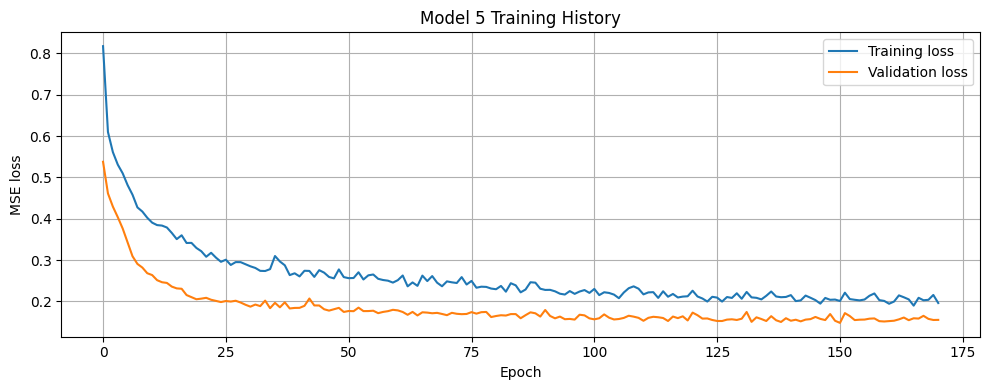

In [ ]:
# Plot training and validation loss

plt.figure(figsize=(10, 4))

plt.plot(history_5.history["loss"], label="Training loss")
plt.plot(history_5.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Model 5 Training History")
plt.legend()
plt.grid(True)
plt.tight_layout()

if SAVE_ARTIFACTS:
    plt.savefig(
        save_path(
            "results/training_history/"
            "35_model_5_training_history.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

plt.show()

**Сохранение обученной модели № 5**

In [ ]:
if SAVE_ARTIFACTS:
    model_5.save(
        save_path(
            "models/autoencoders/45_model_5.keras"
        )
    )

**Эксперимент 5.1 - Оценка работы модели с эвристическим порогом ошибки реконструкции**

In [ ]:
# Reconstruction errors on the Validation set
val_recon_5 = model_5.predict(X_val, verbose=0)

val_mse_5 = np.mean(
    np.square(X_val - val_recon_5),
    axis=1
)

# Heuristic threshold: mean + 2 standard deviations
threshold_heur_5 = np.mean(val_mse_5) + 2 * np.std(val_mse_5)

# Reconstruction errors on the Calibration set
calibration_recon_5 = model_5.predict(
    X_calibration,
    verbose=0
)

calibration_mse_5 = np.mean(
    np.square(X_calibration - calibration_recon_5),
    axis=1
)

print(f"Heuristic threshold: {threshold_heur_5:.6f}")
print(f"Mean Validation MSE:  {np.mean(val_mse_5):.6f}")
print(f"Std Validation MSE:   {np.std(val_mse_5):.6f}")

Heuristic threshold: 0.991141
Mean Validation MSE:  0.148229
Std Validation MSE:   0.421456


In [ ]:
# Predictions on the Calibration set
y_pred_heur_5 = (
    calibration_mse_5 > threshold_heur_5
).astype(int)

print("=== Calibration Classification Report ===")
print(
    classification_report(
        y_calibration,
        y_pred_heur_5,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

print(
    f"AUC-ROC: "
    f"{roc_auc_score(y_calibration, calibration_mse_5):.4f}"
)

print()
print("=== Calibration Confusion Matrix ===")

cm_heur_5 = confusion_matrix(
    y_calibration,
    y_pred_heur_5
)

print(cm_heur_5)

=== Calibration Classification Report ===
              precision    recall  f1-score   support

      Normal       0.91      0.99      0.95      6506
       Fraud       0.40      0.09      0.15       697

    accuracy                           0.90      7203
   macro avg       0.66      0.54      0.55      7203
weighted avg       0.86      0.90      0.87      7203

AUC-ROC: 0.7714

=== Calibration Confusion Matrix ===
[[6409   97]
 [ 632   65]]


**Вывод по результатам эксперимента 5.1**

Эвристический пороговый уровень обеспечивает относительно низкий уровень ложноположительных результатов, но выявляет лишь небольшую долю мошеннических транзакций. На калибровочном наборе модель 5 идентифицирует 65 из 697 мошеннических транзакций, что соответствует Fraud Recall приблизительно 0,09 и Fraud Precision приблизительно 0,40. Fraud F1 составляет приблизительно 0,15. Таким образом, эвристический порог представляет собой чрезмерно ограничительную рабочую точку для этой модели.

**Эксперимент 5.2 - Оценка с использованием порога ошибки реконструкции, оптимизированного по F1**

In [ ]:
threshold_opt_5, best_f1_5 = select_f1_optimal_threshold(
    y_calibration,
    calibration_mse_5
)

print(f"Optimized threshold: {threshold_opt_5:.6f}")
print(f"Best Calibration Fraud F1: {best_f1_5:.4f}")
print()

Optimized threshold: 0.750277
Best Calibration Fraud F1: 0.4442



In [ ]:
# Predictions on the Calibration set using the optimized threshold
y_pred_opt_5 = (
    calibration_mse_5 >= threshold_opt_5
).astype(int)

print("=== Calibration Classification Report ===")
print(
    classification_report(
        y_calibration,
        y_pred_opt_5,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

print(
    f"AUC-ROC: "
    f"{roc_auc_score(y_calibration, calibration_mse_5):.4f}"
)

print()
print("=== Calibration Confusion Matrix ===")

cm_opt_5 = confusion_matrix(
    y_calibration,
    y_pred_opt_5
)

print(cm_opt_5)

=== Calibration Classification Report ===
              precision    recall  f1-score   support

      Normal       0.93      0.98      0.96      6506
       Fraud       0.64      0.34      0.44       697

    accuracy                           0.92      7203
   macro avg       0.79      0.66      0.70      7203
weighted avg       0.90      0.92      0.91      7203

AUC-ROC: 0.7714

=== Calibration Confusion Matrix ===
[[6373  133]
 [ 460  237]]


**Вывод по результатам эксперимента 5.2**

Оптимизация порога ошибки реконструкции на калибровочном наборе существенно улучшает зависящие от порога показатели обнаружения аномалий. Fraud Recall увеличивается примерно с 0,09 до 0,34, Fraud Precision — примерно с 0,40 до 0,64, а Fraud F1 — примерно с 0,15 до 0,44.

AUC-ROC остается неизменным на уровне 0,7714, поскольку эта метрика не зависит от порога классификации и характеризует общую способность модели ранжировать транзакции по степени аномальности.

**Общий вывод по результатам оценки модели 5**

По сравнению с моделью 4 исключение BatchNormalization сопровождается снижением AUC-ROC с 0,8030 до 0,7714. При оптимизированном по Fraud F1 пороге Fraud Recall незначительно увеличивается приблизительно с 0,33 до 0,34, однако Fraud Precision снижается с 0,87 до 0,64, а Fraud F1 — с 0,47 до 0,44. Количество ложноположительных срабатываний увеличивается с 35 до 133. Таким образом, полученные результаты не указывают на улучшение attention-based архитектуры вследствие исключения BatchNormalization.

По сравнению с моделью 2, имеющей ту же основную архитектуру, но не содержащей AttentionLayer, модель 5 демонстрирует немного более высокое значение AUC-ROC — 0,7714 против 0,7631 — и практически такое же значение Fraud Recall. При этом Fraud Precision снижается приблизительно с 0,76 до 0,64, а Fraud F1 — приблизительно с 0,46 до 0,44. Следовательно, в данной конфигурации добавление AttentionLayer обеспечивает небольшое улучшение независимой от порога способности к ранжированию, но не улучшает качество классификации при пороге, оптимизированном по Fraud F1.

Среди рассмотренных на данном этапе моделей с механизмом внимания модель 4 демонстрирует лучшие результаты по AUC-ROC и Fraud F1.

## 4.4 Модель № 6

Модель 6 сохраняет архитектуру и конфигурацию обучения модели 5, одновременно снижая коэффициент Dropout с 0,2 до 0,1. В этом эксперименте оценивается влияние более слабой регуляризации Dropout на производительность автокодировщика на основе механизма внимания.

**Создание модели № 6**

In [ ]:
# Reset random seed before model initialization
reset_seed()

# Input layer
inputs_6 = keras.Input(shape=(INPUT_DIM,), name="input")

# Encoder
x = layers.Dense(64, activation="relu", name="encoder_dense_1")(inputs_6)
x = layers.Dropout(0.1, name="encoder_dropout_1")(x)

x = layers.Dense(32, activation="relu", name="encoder_dense_2")(x)
x = layers.Dropout(0.1, name="encoder_dropout_2")(x)

x = layers.Dense(16, activation="relu", name="encoder_dense_3")(x)

# Attention layer
attention_6 = AttentionLayer(name="attention")(x)

# Bottleneck
bottleneck_6 = layers.Dense(
    8,
    activation="relu",
    name="bottleneck"
)(attention_6)

# Decoder
x = layers.Dense(16, activation="relu", name="decoder_dense_1")(bottleneck_6)
x = layers.Dropout(0.1, name="decoder_dropout_1")(x)

x = layers.Dense(32, activation="relu", name="decoder_dense_2")(x)
x = layers.Dropout(0.1, name="decoder_dropout_2")(x)

x = layers.Dense(64, activation="relu", name="decoder_dense_3")(x)

# Output layer
outputs_6 = layers.Dense(
    INPUT_DIM,
    activation="linear",
    name="output"
)(x)

model_6 = keras.Model(
    inputs=inputs_6,
    outputs=outputs_6,
    name="autoencoder_model_6"
)

model_6.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse"
)

model_6.summary()

Model: "autoencoder_model_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 21)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_1 (Dense)         │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_1 (Dropout)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_2 (Dense)         │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_2 (Dropout)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_3 (Dense)         │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (AttentionLayer)      │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout_1 (Dropout)     │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_2 (Dense)         │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout_2 (Dropout)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_3 (Dense)         │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 21)             │         1,365 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,589 (33.55 KB)

 Trainable params: 8,589 (33.55 KB)

 Non-trainable params: 0 (0.00 B)

**Обучение модели № 6**

In [ ]:
early_stopping_6 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOP_PATIENCE,
    restore_best_weights=True
)

history_6 = model_6.fit(
    X_train,
    X_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, X_val),
    callbacks=[early_stopping_6],
    verbose=1
)

best_epoch_6 = int(np.argmin(history_6.history["val_loss"]) + 1)

print()
print(f"Training epochs completed: {len(history_6.history['loss'])}")
print(f"Best epoch by Validation loss: {best_epoch_6}")

Epoch 1/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.7784 - val_loss: 0.4896
Epoch 2/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.5313 - val_loss: 0.3690
Epoch 3/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.4595 - val_loss: 0.3215
Epoch 4/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.4110 - val_loss: 0.2742
Epoch 5/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3762 - val_loss: 0.2428
Epoch 6/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.3467 - val_loss: 0.2154
Epoch 7/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3159 - val_loss: 0.1934
Epoch 8/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2912 - val_loss: 0.1808
Epoch 9/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2761 - val_loss: 0.1717
Epoch 10/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2670 - val_loss: 0.1644
Epoch 11/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2503 - val_loss: 0.1600
Epoch 12/300
238/238 ━━━━━━━━━━━━━━━━━

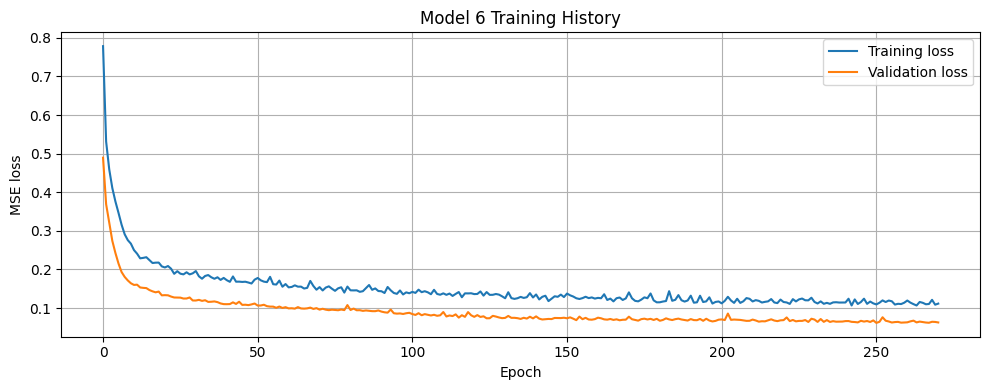

In [ ]:
# Plot training and validation loss

plt.figure(figsize=(10, 4))

plt.plot(history_6.history["loss"], label="Training loss")
plt.plot(history_6.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Model 6 Training History")
plt.legend()
plt.grid(True)
plt.tight_layout()

if SAVE_ARTIFACTS:
    plt.savefig(
        save_path(
            "results/training_history/"
            "36_model_6_training_history.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

plt.show()

**Сохранение обученной модели № 6**

In [ ]:
if SAVE_ARTIFACTS:
    model_6.save(
        save_path(
            "models/autoencoders/46_model_6.keras"
        )
    )

**Эксперимент 6.1 - Оценка работы модели с эвристическим порогом ошибки реконструкции**

In [ ]:
# Reconstruction errors on the Validation set
val_recon_6 = model_6.predict(X_val, verbose=0)

val_mse_6 = np.mean(
    np.square(X_val - val_recon_6),
    axis=1
)

# Heuristic threshold: mean + 2 standard deviations
threshold_heur_6 = np.mean(val_mse_6) + 2 * np.std(val_mse_6)

# Reconstruction errors on the Calibration set
calibration_recon_6 = model_6.predict(
    X_calibration,
    verbose=0
)

calibration_mse_6 = np.mean(
    np.square(X_calibration - calibration_recon_6),
    axis=1
)

print(f"Heuristic threshold: {threshold_heur_6:.6f}")
print(f"Mean Validation MSE:  {np.mean(val_mse_6):.6f}")
print(f"Std Validation MSE:   {np.std(val_mse_6):.6f}")

Heuristic threshold: 0.409361
Mean Validation MSE:  0.061723
Std Validation MSE:   0.173819


In [ ]:
# Predictions on the Calibration set
y_pred_heur_6 = (
    calibration_mse_6 > threshold_heur_6
).astype(int)

print("=== Calibration Classification Report ===")
print(
    classification_report(
        y_calibration,
        y_pred_heur_6,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

print(
    f"AUC-ROC: "
    f"{roc_auc_score(y_calibration, calibration_mse_6):.4f}"
)

print()
print("=== Calibration Confusion Matrix ===")

cm_heur_6 = confusion_matrix(
    y_calibration,
    y_pred_heur_6
)

print(cm_heur_6)

=== Calibration Classification Report ===
              precision    recall  f1-score   support

      Normal       0.93      0.98      0.95      6506
       Fraud       0.62      0.35      0.45       697

    accuracy                           0.92      7203
   macro avg       0.78      0.67      0.70      7203
weighted avg       0.90      0.92      0.91      7203

AUC-ROC: 0.8420

=== Calibration Confusion Matrix ===
[[6355  151]
 [ 450  247]]


**Вывод по результатам эксперимента 6.1**

Эвристический пороговый уровень выявляет 247 из 697 мошеннических транзакций на калибровочном наборе, что соответствует показателю полноты обнаружения мошенничества приблизительно 0,35 и показателю точности обнаружения мошенничества приблизительно 0,62. Хотя эта рабочая точка обеспечивает относительно высокий показатель полноты обнаружения мошенничества, она также приводит к 151 ложноположительному результату.

**Эксперимент 6.2 - Оценка с использованием порога ошибки реконструкции, оптимизированного по F1**

In [ ]:
threshold_opt_6, best_f1_6 = select_f1_optimal_threshold(
    y_calibration,
    calibration_mse_6
)

if SAVE_ARTIFACTS:
    joblib.dump(
        float(threshold_opt_6),
        save_path(
            "results/model_6_analysis/"
            "91_model_6_threshold.pkl"
        )
    )

    print(
        "Model 6 calibrated threshold saved to "
        "91_model_6_threshold.pkl."
    )

print()

print(f"Optimized threshold: {threshold_opt_6:.6f}")
print(f"Best Calibration Fraud F1: {best_f1_6:.4f}")
print()

Model 6 calibrated threshold saved to 91_model_6_threshold.pkl.

Optimized threshold: 0.246948
Best Calibration Fraud F1: 0.4772



In [ ]:
# Predictions on the Calibration set using the optimized threshold
y_pred_opt_6 = (
    calibration_mse_6 >= threshold_opt_6
).astype(int)

print("=== Calibration Classification Report ===")
print(
    classification_report(
        y_calibration,
        y_pred_opt_6,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

print(
    f"AUC-ROC: "
    f"{roc_auc_score(y_calibration, calibration_mse_6):.4f}"
)

print()
print("=== Calibration Confusion Matrix ===")

cm_opt_6 = confusion_matrix(
    y_calibration,
    y_pred_opt_6
)

print(cm_opt_6)

=== Calibration Classification Report ===
              precision    recall  f1-score   support

      Normal       0.94      0.96      0.95      6506
       Fraud       0.54      0.43      0.48       697

    accuracy                           0.91      7203
   macro avg       0.74      0.69      0.71      7203
weighted avg       0.90      0.91      0.90      7203

AUC-ROC: 0.8420

=== Calibration Confusion Matrix ===
[[6252  254]
 [ 399  298]]


**Вывод по результатам эксперимента 6.2**

Оптимизация порога ошибки реконструкции на калибровочном наборе смещает рабочую точку модели в сторону более высокой полноты обнаружения мошеннических транзакций. Fraud Recall увеличивается примерно с 0,35 до 0,43, тогда как Fraud Precision снижается примерно с 0,62 до 0,54. Количество истинно положительных срабатываний увеличивается с 247 до 298, одновременно с увеличением числа ложноположительных срабатываний со 151 до 254. В результате Fraud F1 увеличивается примерно с 0,45 до 0,48.

AUC-ROC остается неизменным на уровне 0,8420, поскольку эта метрика не зависит от порога классификации и характеризует общую способность модели ранжировать транзакции по степени аномальности.

**Общий вывод по результатам оценки модели 6**

По сравнению с моделью 5 снижение коэффициента Dropout с 0,2 до 0,1 сопровождается существенным улучшением результатов модели 6. AUC-ROC увеличивается с 0,7714 до 0,8420, Fraud Recall при оптимизированном пороге — приблизительно с 0,34 до 0,43, а Fraud F1 — приблизительно с 0,44 до 0,48. При этом Fraud Precision снижается приблизительно с 0,64 до 0,54, что отражает смещение оптимальной по Fraud F1 рабочей точки в сторону более высокой полноты обнаружения.

Наилучшее значение Validation loss было достигнуто на 251-й эпохе, а обучение завершилось после 271 эпохи вследствие EarlyStopping. Это подтверждает достаточность общего максимального бюджета обучения в 300 эпох для модели 6.

Среди моделей 1–6 модель 6 демонстрирует наибольшие значения AUC-ROC и Fraud Recall на калибровочном наборе, а также незначительно наибольшее значение Fraud F1. Таким образом, на данном этапе модель 6 является наиболее сильным кандидатом для дальнейшего использования.

## 4.5 Модель № 7

Модель 7 сохраняет структуру полносвязных слоёв, коэффициент Dropout и конфигурацию обучения модели 6, но перемещает AttentionLayer из скрытого представления перед bottleneck непосредственно на вход модели. Поскольку размерность входа AttentionLayer при этом изменяется с 16 до 21, число его обучаемых параметров увеличивается с 272 до 462. Таким образом, эксперимент преимущественно оценивает влияние расположения механизма внимания, хотя перенос слоя также сопровождается небольшим увеличением общего числа параметров модели.

**Создание модели № 7**

In [ ]:
# Reset random seed before model initialization
reset_seed()

# Input layer
inputs_7 = keras.Input(shape=(INPUT_DIM,), name="input")

# Attention applied directly to the input features
attention_7 = AttentionLayer(name="attention")(inputs_7)

# Encoder
x = layers.Dense(64, activation="relu", name="encoder_dense_1")(attention_7)
x = layers.Dropout(0.1, name="encoder_dropout_1")(x)

x = layers.Dense(32, activation="relu", name="encoder_dense_2")(x)
x = layers.Dropout(0.1, name="encoder_dropout_2")(x)

x = layers.Dense(16, activation="relu", name="encoder_dense_3")(x)

# Bottleneck
bottleneck_7 = layers.Dense(
    8,
    activation="relu",
    name="bottleneck"
)(x)

# Decoder
x = layers.Dense(16, activation="relu", name="decoder_dense_1")(bottleneck_7)
x = layers.Dropout(0.1, name="decoder_dropout_1")(x)

x = layers.Dense(32, activation="relu", name="decoder_dense_2")(x)
x = layers.Dropout(0.1, name="decoder_dropout_2")(x)

x = layers.Dense(64, activation="relu", name="decoder_dense_3")(x)

# Output layer
outputs_7 = layers.Dense(
    INPUT_DIM,
    activation="linear",
    name="output"
)(x)

model_7 = keras.Model(
    inputs=inputs_7,
    outputs=outputs_7,
    name="autoencoder_model_7"
)

model_7.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse"
)

model_7.summary()

Model: "autoencoder_model_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 21)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (AttentionLayer)      │ (None, 21)             │           462 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_1 (Dense)         │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_1 (Dropout)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_2 (Dense)         │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_2 (Dropout)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_3 (Dense)         │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_1 (Dense)         │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout_1 (Dropout)     │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_2 (Dense)         │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout_2 (Dropout)     │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_3 (Dense)         │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 21)             │         1,365 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,779 (34.29 KB)

 Trainable params: 8,779 (34.29 KB)

 Non-trainable params: 0 (0.00 B)

**Обучение модели № 7**

In [ ]:
early_stopping_7 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOP_PATIENCE,
    restore_best_weights=True
)

history_7 = model_7.fit(
    X_train,
    X_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, X_val),
    callbacks=[early_stopping_7],
    verbose=1
)

best_epoch_7 = int(np.argmin(history_7.history["val_loss"]) + 1)

print()
print(f"Training epochs completed: {len(history_7.history['loss'])}")
print(f"Best epoch by Validation loss: {best_epoch_7}")

Epoch 1/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.7809 - val_loss: 0.4867
Epoch 2/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.5354 - val_loss: 0.3742
Epoch 3/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.4572 - val_loss: 0.3165
Epoch 4/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3687 - val_loss: 0.2239
Epoch 5/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.3189 - val_loss: 0.1872
Epoch 6/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2876 - val_loss: 0.1767
Epoch 7/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2702 - val_loss: 0.1697
Epoch 8/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.2579 - val_loss: 0.1635
Epoch 9/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2551 - val_loss: 0.1608
Epoch 10/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2347 - val_loss: 0.1553
Epoch 11/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2264 - val_loss: 0.1507
Epoch 12/300
238/238 ━━━━━━━━━━━━━━━━

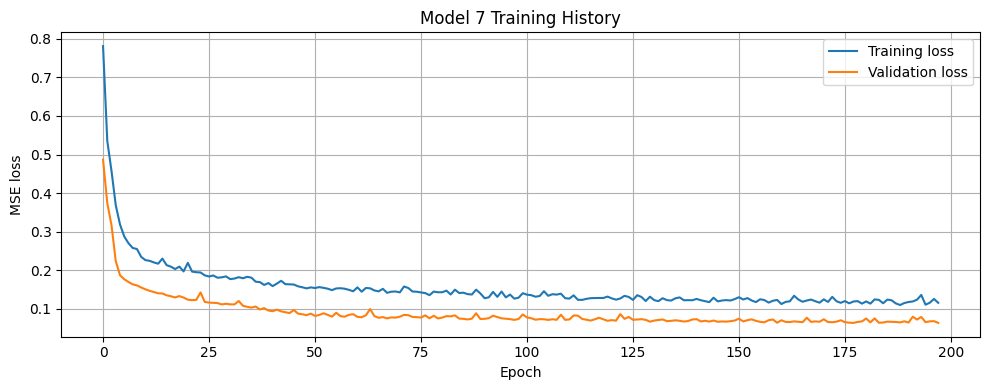

In [ ]:
# Plot training and validation loss

plt.figure(figsize=(10, 4))

plt.plot(history_7.history["loss"], label="Training loss")
plt.plot(history_7.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Model 7 Training History")
plt.legend()
plt.grid(True)
plt.tight_layout()

if SAVE_ARTIFACTS:
    plt.savefig(
        save_path(
            "results/training_history/"
            "37_model_7_training_history.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

plt.show()

**Сохранение весов модели № 7**

In [ ]:
if SAVE_ARTIFACTS:
    model_7.save(
        save_path(
            "models/autoencoders/47_model_7.keras"
        )
    )

**Эксперимент 7.1 - Оценка работы модели с эвристическим порогом ошибки реконструкции**

In [ ]:
# Reconstruction errors on the Validation set
val_recon_7 = model_7.predict(X_val, verbose=0)

val_mse_7 = np.mean(
    np.square(X_val - val_recon_7),
    axis=1
)

# Heuristic threshold: mean + 2 standard deviations
threshold_heur_7 = np.mean(val_mse_7) + 2 * np.std(val_mse_7)

# Reconstruction errors on the Calibration set
calibration_recon_7 = model_7.predict(
    X_calibration,
    verbose=0
)

calibration_mse_7 = np.mean(
    np.square(X_calibration - calibration_recon_7),
    axis=1
)

print(f"Heuristic threshold: {threshold_heur_7:.6f}")
print(f"Mean Validation MSE:  {np.mean(val_mse_7):.6f}")
print(f"Std Validation MSE:   {np.std(val_mse_7):.6f}")

Heuristic threshold: 0.421867
Mean Validation MSE:  0.063657
Std Validation MSE:   0.179105


In [ ]:
# Predictions on the Calibration set
y_pred_heur_7 = (
    calibration_mse_7 > threshold_heur_7
).astype(int)

print("=== Calibration Classification Report ===")
print(
    classification_report(
        y_calibration,
        y_pred_heur_7,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

print(
    f"AUC-ROC: "
    f"{roc_auc_score(y_calibration, calibration_mse_7):.4f}"
)

print()
print("=== Calibration Confusion Matrix ===")

cm_heur_7 = confusion_matrix(
    y_calibration,
    y_pred_heur_7
)

print(cm_heur_7)

=== Calibration Classification Report ===
              precision    recall  f1-score   support

      Normal       0.94      0.98      0.96      6506
       Fraud       0.64      0.37      0.47       697

    accuracy                           0.92      7203
   macro avg       0.79      0.67      0.71      7203
weighted avg       0.91      0.92      0.91      7203

AUC-ROC: 0.8098

=== Calibration Confusion Matrix ===
[[6361  145]
 [ 439  258]]


**Вывод по результатам эксперимента 7.1**

Эвристический порог обеспечивает для модели 7 сравнительно высокую полноту обнаружения мошеннических транзакций. На калибровочном наборе Fraud Recall составляет примерно 0,37, а Fraud Precision — примерно 0,64. Модель корректно выявляет 258 из 697 мошеннических транзакций, при этом допускает 145 ложноположительных срабатываний. Fraud F1 составляет примерно 0,47.

AUC-ROC модели равен 0,8098, что указывает на достаточно высокую общую способность ранжировать нормальные и мошеннические транзакции по значению ошибки реконструкции.

**Эксперимент 7.2 - Оценка с использованием порога ошибки реконструкции, оптимизированного по F1**

In [ ]:
threshold_opt_7, best_f1_7 = select_f1_optimal_threshold(
    y_calibration,
    calibration_mse_7
)

print(f"Optimized threshold: {threshold_opt_7:.6f}")
print(f"Best Calibration Fraud F1: {best_f1_7:.4f}")
print()

Optimized threshold: 0.836006
Best Calibration Fraud F1: 0.4753



In [ ]:
# Predictions on the Calibration set using the optimized threshold
y_pred_opt_7 = (
    calibration_mse_7 >= threshold_opt_7
).astype(int)

print("=== Calibration Classification Report ===")
print(
    classification_report(
        y_calibration,
        y_pred_opt_7,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

print(
    f"AUC-ROC: "
    f"{roc_auc_score(y_calibration, calibration_mse_7):.4f}"
)

print()
print("=== Calibration Confusion Matrix ===")

cm_opt_7 = confusion_matrix(
    y_calibration,
    y_pred_opt_7
)

print(cm_opt_7)

=== Calibration Classification Report ===
              precision    recall  f1-score   support

      Normal       0.93      0.99      0.96      6506
       Fraud       0.84      0.33      0.48       697

    accuracy                           0.93      7203
   macro avg       0.89      0.66      0.72      7203
weighted avg       0.92      0.93      0.91      7203

AUC-ROC: 0.8098

=== Calibration Confusion Matrix ===
[[6462   44]
 [ 466  231]]


**Вывод по результатам эксперимента 7.2**

Оптимизация порога ошибки реконструкции на калибровочном наборе изменяет баланс между Fraud Precision и Fraud Recall. Fraud Recall снижается примерно с 0,37 до 0,33, тогда как Fraud Precision увеличивается примерно с 0,64 до 0,84. Количество ложноположительных срабатываний уменьшается со 145 до 44. В результате Fraud F1 незначительно увеличивается примерно с 0,47 до 0,48.

AUC-ROC остается неизменным на уровне 0,8098, поскольку эта метрика не зависит от порога классификации и характеризует общую способность модели ранжировать транзакции по степени аномальности.

**Общий вывод по результатам оценки модели 7**

По сравнению с моделью 6 перенос AttentionLayer из скрытого представления перед bottleneck непосредственно на вход модели сопровождается снижением AUC-ROC с 0,8420 до 0,8098. При оптимизированном по Fraud F1 пороге Fraud Precision существенно увеличивается приблизительно с 0,54 до 0,84, однако Fraud Recall снижается приблизительно с 0,43 до 0,33. Fraud F1 остается практически на том же уровне: приблизительно 0,48 у обеих моделей.

Таким образом, размещение AttentionLayer непосредственно на входе формирует рабочую точку с меньшим количеством ложноположительных срабатываний и более высоким Fraud Precision, но ухудшает как независимую от порога способность модели к ранжированию, так и Fraud Recall. С учетом принятого приоритета AUC-ROC и Fraud Recall результаты не подтверждают преимущество переноса механизма внимания на вход модели.

## 4.6 Вывод

По результатам последовательного сравнения архитектур модель 6 выбрана в качестве основной модели для последующих этапов исследования. На калибровочном наборе она продемонстрировала наибольшее среди моделей 1–7 значение AUC-ROC, равное 0,8420, что указывает на наилучшую общую способность ранжировать нормальные и мошеннические транзакции по ошибке реконструкции.

При пороге, оптимизированном по Fraud F1, модель 6 также продемонстрировала наибольшее значение Fraud Recall — приблизительно 0,43 — и незначительно наибольшее значение Fraud F1 — приблизительно 0,48. Более высокий Fraud Precision отдельных моделей достигается при существенно меньшем Fraud Recall и поэтому не компенсирует их более низкие значения AUC-ROC с учетом принятой приоритетности метрик.

Перемещение AttentionLayer непосредственно на вход модели 7 не обеспечило дальнейшего улучшения: AUC-ROC снизился до 0,8098, а Fraud Recall — приблизительно до 0,33. Поэтому для дальнейшего анализа объяснимости и последующей финальной оценки выбрана архитектура модели 6, в которой AttentionLayer расположен между последним слоем энкодера и bottleneck, а коэффициент Dropout составляет 0,1.

Архитектура, гиперпараметры и оптимизированный порог модели после завершения этапа калибровки должны быть зафиксированы до однократной оценки на Holdout Test.

# 5 Объяснимость

## 5.1 SHAP

SHAP (SHapley Additive exPlanations) — это метод объяснения, не зависящий от модели и основанный на значениях Шепли из теории кооперативных игр.

В данном анализе SHAP используется для объяснения скалярной ошибки реконструкции, вычисляемой выбранным автокодировщиком. Для каждой транзакции SHAP оценивает, как каждый из 21 входных признаков влияет на ошибку реконструкции относительно фонового распределения. Положительное значение SHAP соответствует вкладу, увеличивающему ошибку реконструкции относительно базового уровня, тогда как отрицательное значение соответствует вкладу, уменьшающему её.

Поскольку ошибка реконструкции используется в качестве показателя аномальности, больший положительный вклад связан с более высоким показателем аномальности. Однако значения SHAP объясняют ошибку реконструкции, а не напрямую указывают на то, является ли транзакция мошеннической.

**Анализ важности признаков на основе SHAP для модели 6**

In [ ]:
SHAP_BACKGROUND_SIZE = 100
SHAP_EXPLAIN_SIZE = len(X_calibration)
SHAP_RANDOM_STATE = 42

N_FEATURES = len(feature_cols)

assert N_FEATURES == 21
assert SHAP_BACKGROUND_SIZE <= len(X_train)

rng_shap = np.random.default_rng(SHAP_RANDOM_STATE)


# ============================================================
# Background dataset
# ============================================================

background_idx = rng_shap.choice(
    len(X_train),
    size=SHAP_BACKGROUND_SIZE,
    replace=False
)

background = np.asarray(
    X_train[background_idx],
    dtype=np.float32
)


# ============================================================
# Transactions to explain
# ============================================================

# Use the entire Calibration set
explain_data = np.asarray(
    X_calibration,
    dtype=np.float32
)

explain_labels = y_calibration

In [ ]:
# ============================================================
# Scalar reconstruction error of Model 6
# ============================================================

def reconstruction_error_for_shap(x):
    x_tensor = tf.convert_to_tensor(
        x,
        dtype=tf.float32
    )

    x_pred = model_6(
        x_tensor,
        training=False
    )

    reconstruction_error = tf.reduce_mean(
        tf.square(x_tensor - x_pred),
        axis=1
    )

    return reconstruction_error.numpy().reshape(-1, 1)


# ============================================================
# SHAP PermutationExplainer
# ============================================================

masker = shap.maskers.Independent(
    background,
    max_samples=SHAP_BACKGROUND_SIZE
)

explainer = shap.PermutationExplainer(
    reconstruction_error_for_shap,
    masker,
    feature_names=feature_cols,
    seed=SHAP_RANDOM_STATE
)

# This is the computationally expensive step
shap_values = explainer(
    explain_data
)

print(
    "SHAP value calculation completed successfully."
)

PermutationExplainer explainer: 7204it [25:46,  4.65it/s]


In [ ]:
# Validate SHAP output shapes and report class composition

print("Background shape:", background.shape)
print("Explained dataset shape:", explain_data.shape)
print("SHAP values shape:", shap_values.values.shape)

print()
print("=== Explained Calibration Set ===")
print(f"Normal: {np.sum(explain_labels == 0)}")
print(f"Fraud:  {np.sum(explain_labels == 1)}")

assert background.shape == (
    SHAP_BACKGROUND_SIZE,
    N_FEATURES
)

assert explain_data.shape == (
    SHAP_EXPLAIN_SIZE,
    N_FEATURES
)

assert shap_values.values.shape[0] == SHAP_EXPLAIN_SIZE
assert shap_values.values.shape[1] == N_FEATURES

Background shape: (100, 21)
Explained dataset shape: (7203, 21)
SHAP values shape: (7203, 21)

=== Explained Calibration Set ===
Normal: 6506
Fraud:  697


**Сохранение индексов**

In [ ]:
if SAVE_ARTIFACTS:
    np.save(
        save_path(
            "results/shap/"
            "51_shap_background_indices.npy"
        ),
        background_idx
    )

Для каждой транзакции выборки Calibration SHAP возвращает вектор из 21 значения, представляющего вклад 21 входного признака в скалярную ошибку реконструкции *e*(*x*). Поскольку анализ выполняется для всей выборки Calibration, ожидаемая форма массива SHAP - (7203, 21).

In [ ]:
# Convert SHAP values to a NumPy array
shap_array = np.asarray(shap_values.values)

# For a model with a single scalar output, SHAP may return
# an additional singleton output dimension.
if shap_array.ndim == 3 and shap_array.shape[-1] == 1:
    shap_array = shap_array[..., 0]

assert shap_array.shape == (
    SHAP_EXPLAIN_SIZE,
    N_FEATURES
), (
    f"Unexpected SHAP array shape: {shap_array.shape}"
)

print("SHAP array shape:", shap_array.shape)


# Global feature importance:
# mean absolute SHAP value across explained transactions
shap_importance_values = np.mean(
    np.abs(shap_array),
    axis=0
)

importance = (
    pd.DataFrame({
        "feature": feature_cols,
        "shap_importance": shap_importance_values
    })
    .sort_values(
        "shap_importance",
        ascending=False
    )
    .reset_index(drop=True)
)

# Rank 1 corresponds to the most important feature
importance["rank"] = np.arange(
    1,
    len(importance) + 1
)

importance = importance[
    ["rank", "feature", "shap_importance"]
]

print()
print("=== SHAP Feature Importance ===")
print(importance.to_string(index=False))

SHAP array shape: (7203, 21)

=== SHAP Feature Importance ===
 rank              feature  shap_importance
    1                nonce         0.051103
    2     is_contract_call         0.040290
    3             is_error         0.038871
    4     sender_unique_to         0.038207
    5  method_id_frequency         0.031083
    6 sender_avg_value_eth         0.030477
    7          is_first_tx         0.029856
    8        is_zero_value         0.029292
    9           is_weekend         0.024851
   10      sender_tx_count         0.023103
   11            gas_limit         0.020547
   12             gas_used         0.020030
   13   sender_avg_gas_eff         0.019666
   14       gas_price_gwei         0.019085
   15       gas_efficiency         0.018093
   16    sender_error_rate         0.017110
   17            value_eth         0.014514
   18             hour_cos         0.014491
   19             hour_sin         0.013611
   20      input_len_bytes         0.013417
   21         

**Сохранение значений по SHAP**

In [ ]:
if SAVE_ARTIFACTS:
    importance.to_csv(
        save_path(
            "results/shap/52_shap_importance.csv"
        ),
        index=False
    )

    np.save(
        save_path(
            "results/shap/53_shap_values.npy"
        ),
        shap_array
    )

**Визуализация**

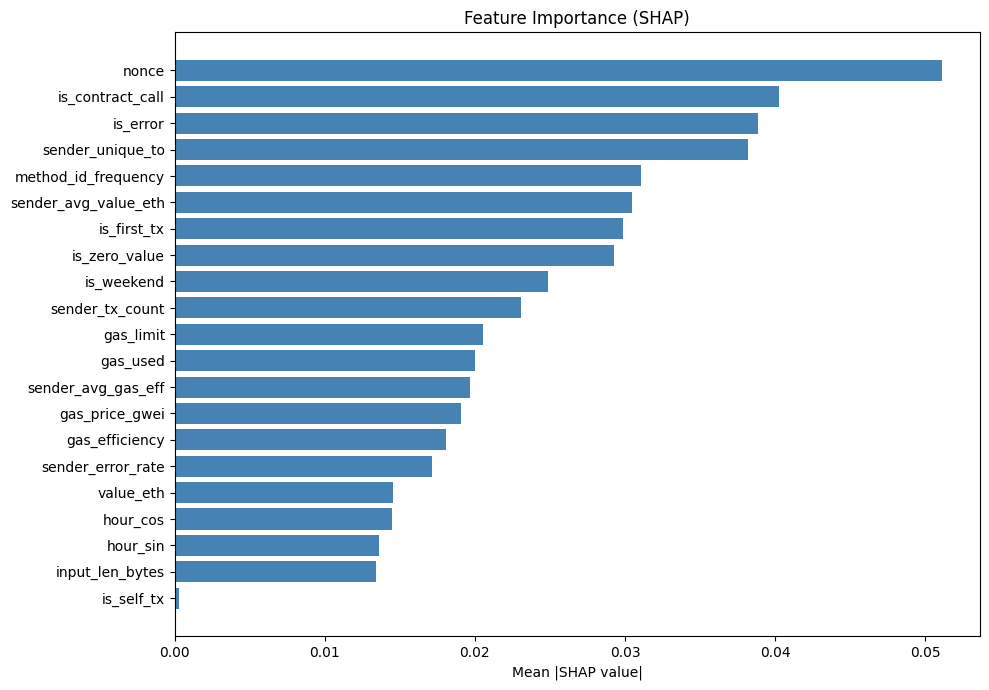

In [ ]:
plt.figure(figsize=(10, 7))

plt.barh(
    importance["feature"],
    importance["shap_importance"],
    color="steelblue"
)

plt.xlabel("Mean |SHAP value|")
plt.title("Feature Importance (SHAP)")
plt.gca().invert_yaxis()
plt.tight_layout()

if SAVE_ARTIFACTS:
    plt.savefig(
        save_path(
            "results/shap/54_shap_importance.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

plt.show()

## 5.2 Attention

Выходные активации слоя внимания в модели 6 извлекаются и используются для оценки связи между 21 входным признаком и 16 нейронами взвешенного скрытого представления посредством корреляционного анализа Пирсона.

In [ ]:
# Auxiliary model returning the output activations
# of the AttentionLayer in Model 6: h * alpha, dimension = 16

attention_layer = model_6.get_layer("attention")

attention_model = keras.Model(
    inputs=model_6.input,
    outputs=attention_layer.output,
    name="model_6_attention_output"
)

print("Model 6 output shape:", model_6.output_shape)
print("AttentionLayer output shape:", attention_model.output_shape)

Model 6 output shape: (None, 21)
AttentionLayer output shape: (None, 16)


In [ ]:
# Use the entire Calibration set.
# For each transaction, extract the 16 output activations
# of the AttentionLayer.

X_attention = np.asarray(
    X_calibration,
    dtype=np.float32
)

att_out = attention_model.predict(
    X_attention,
    batch_size=BATCH_SIZE,
    verbose=0
)

n_samples, n_features = X_attention.shape
n_attention_units = att_out.shape[1]


# ============================================================
# Shape checks
# ============================================================

assert n_features == len(feature_cols) == 21, (
    f"Expected 21 input features, got {n_features}"
)

assert att_out.shape[0] == n_samples, (
    "The number of input transactions and "
    "AttentionLayer outputs does not match"
)

assert n_attention_units == 16, (
    f"Expected 16 AttentionLayer units, "
    f"got {n_attention_units}"
)


# ============================================================
# Variability checks
# ============================================================

# Pearson correlation is undefined for variables
# with zero variance.

constant_feature_idx = np.where(
    np.isclose(
        np.std(X_attention, axis=0),
        0.0
    )
)[0]

constant_attention_idx = np.where(
    np.isclose(
        np.std(att_out, axis=0),
        0.0
    )
)[0]

if len(constant_feature_idx) > 0:
    constant_features = [
        feature_cols[i]
        for i in constant_feature_idx
    ]

    raise ValueError(
        "Input features with zero variance detected: "
        f"{constant_features}"
    )

if len(constant_attention_idx) > 0:
    raise ValueError(
        "AttentionLayer units with zero variance detected: "
        f"{constant_attention_idx.tolist()}"
    )


# ============================================================
# Correlation analysis
# ============================================================

# Combine:
# 21 input features + 16 AttentionLayer activations
combined = np.concatenate(
    [X_attention, att_out],
    axis=1
)

# Full correlation matrix:
# (21 + 16) x (21 + 16) = 37 x 37
corr_matrix = np.corrcoef(
    combined,
    rowvar=False
)

# Absolute correlations between:
# 21 input features x 16 AttentionLayer units
corr_block = np.abs(
    corr_matrix[
        :n_features,
        n_features:
    ]
)

if not np.isfinite(corr_block).all():
    raise ValueError(
        "NaN or infinite values detected "
        "in the correlation matrix"
    )


# ============================================================
# Global correlation-based feature importance
# ============================================================

# For each input feature, calculate the mean absolute
# Pearson correlation across all 16 AttentionLayer units.
attention_feature_importance = corr_block.mean(
    axis=1
)

att_importance = (
    pd.DataFrame({
        "feature": feature_cols,
        "attention_importance":
            attention_feature_importance
    })
    .sort_values(
        "attention_importance",
        ascending=False
    )
    .reset_index(drop=True)
)

att_importance["rank"] = np.arange(
    1,
    len(att_importance) + 1
)

att_importance = att_importance[
    [
        "rank",
        "feature",
        "attention_importance"
    ]
]


# ============================================================
# Results
# ============================================================

print("Calibration input shape:", X_attention.shape)
print("AttentionLayer output shape:", att_out.shape)
print("Correlation matrix shape:", corr_matrix.shape)
print("Feature-attention correlation shape:", corr_block.shape)

print()
print("=== AttentionLayer Correlation-Based Feature Importance ===")
print(att_importance.to_string(index=False))

Calibration input shape: (7203, 21)
AttentionLayer output shape: (7203, 16)
Correlation matrix shape: (37, 37)
Feature-attention correlation shape: (21, 16)

=== AttentionLayer Correlation-Based Feature Importance ===
 rank              feature  attention_importance
    1            value_eth              0.268717
    2       gas_price_gwei              0.262213
    3            gas_limit              0.222060
    4     sender_unique_to              0.216447
    5             gas_used              0.212832
    6 sender_avg_value_eth              0.204601
    7     is_contract_call              0.195198
    8      input_len_bytes              0.176766
    9             is_error              0.175571
   10   sender_avg_gas_eff              0.173271
   11        is_zero_value              0.166852
   12                nonce              0.160920
   13           is_self_tx              0.159523
   14  method_id_frequency              0.157245
   15      sender_tx_count              0.15300

**Сохранение исходной матрицы корреляций**

In [ ]:
attention_corr_df = pd.DataFrame(
    corr_block,
    index=feature_cols,
    columns=[
        f"attention_neuron_{i + 1}"
        for i in range(n_attention_units)
    ]
)

if SAVE_ARTIFACTS:
    attention_corr_df.to_csv(
        save_path(
            "results/attention/"
            "61_attention_feature_neuron_correlations.csv"
        ),
        index_label="feature"
    )

**Сохранение значений по Attention**

In [ ]:
if SAVE_ARTIFACTS:
    att_importance.to_csv(
        save_path(
            "results/attention/62_att_importance.csv"
        ),
        index=False
    )

**Визуализация**

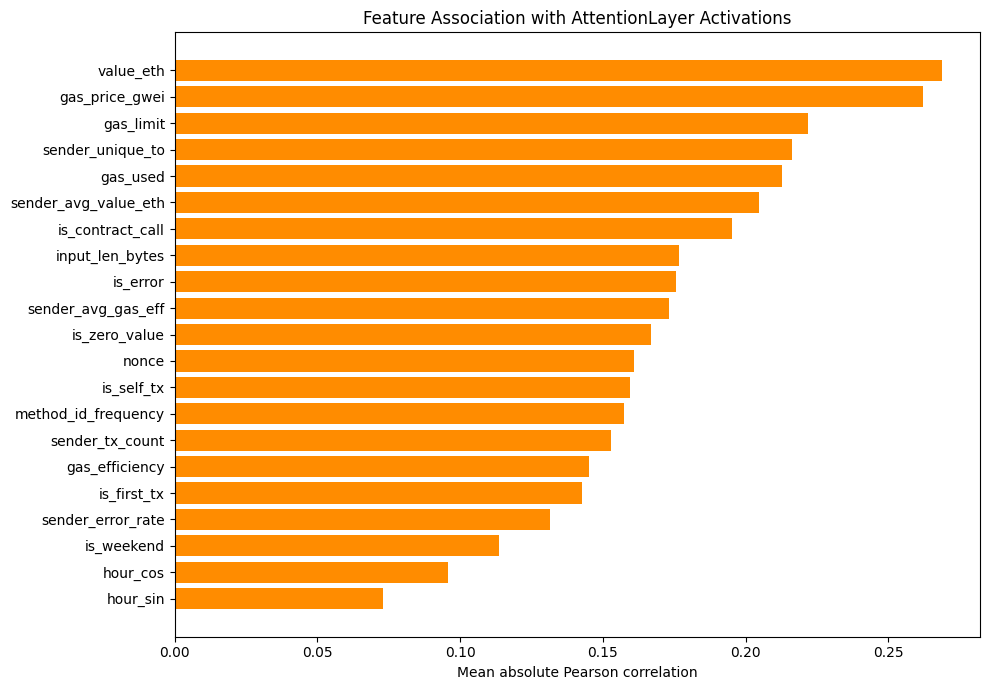

In [ ]:
plt.figure(figsize=(10, 7))

plt.barh(
    att_importance["feature"],
    att_importance["attention_importance"],
    color="darkorange"
)

plt.xlabel("Mean absolute Pearson correlation")
plt.title("Feature Association with AttentionLayer Activations")

plt.gca().invert_yaxis()
plt.tight_layout()

if SAVE_ARTIFACTS:
    plt.savefig(
        save_path(
            "results/attention/63_attention_importance.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

plt.show()

## 5.3 Сравнение двух методов

**Сравнение рангов**

In [ ]:
shap_comparison = importance[
    ["feature", "shap_importance", "rank"]
].rename(
    columns={"rank": "shap_rank"}
)

attention_comparison = att_importance[
    ["feature", "attention_importance", "rank"]
].rename(
    columns={"rank": "attention_rank"}
)

comparison = shap_comparison.merge(
    attention_comparison,
    on="feature",
    how="inner",
    validate="one_to_one"
)

# Sanity checks
assert len(comparison) == len(feature_cols) == 21
assert set(comparison["feature"]) == set(feature_cols)

comparison = (
    comparison
    .sort_values("shap_rank")
    .reset_index(drop=True)
)

print("=== SHAP vs Attention Rank Comparison ===")
print(
    comparison[
        ["feature", "shap_rank", "attention_rank"]
    ].to_string(index=False)
)

=== SHAP vs Attention Rank Comparison ===
             feature  shap_rank  attention_rank
               nonce          1              12
    is_contract_call          2               7
            is_error          3               9
    sender_unique_to          4               4
 method_id_frequency          5              14
sender_avg_value_eth          6               6
         is_first_tx          7              17
       is_zero_value          8              11
          is_weekend          9              19
     sender_tx_count         10              15
           gas_limit         11               3
            gas_used         12               5
  sender_avg_gas_eff         13              10
      gas_price_gwei         14               2
      gas_efficiency         15              16
   sender_error_rate         16              18
           value_eth         17               1
            hour_cos         18              20
            hour_sin         19              2

**Сохранение результатов сравнения**

In [ ]:
if SAVE_ARTIFACTS:
    comparison.to_csv(
        save_path(
            "results/explainability_comparison/"
            "71_shap_att_comparison.csv"
        ),
        index=False
    )

**Визуализация**

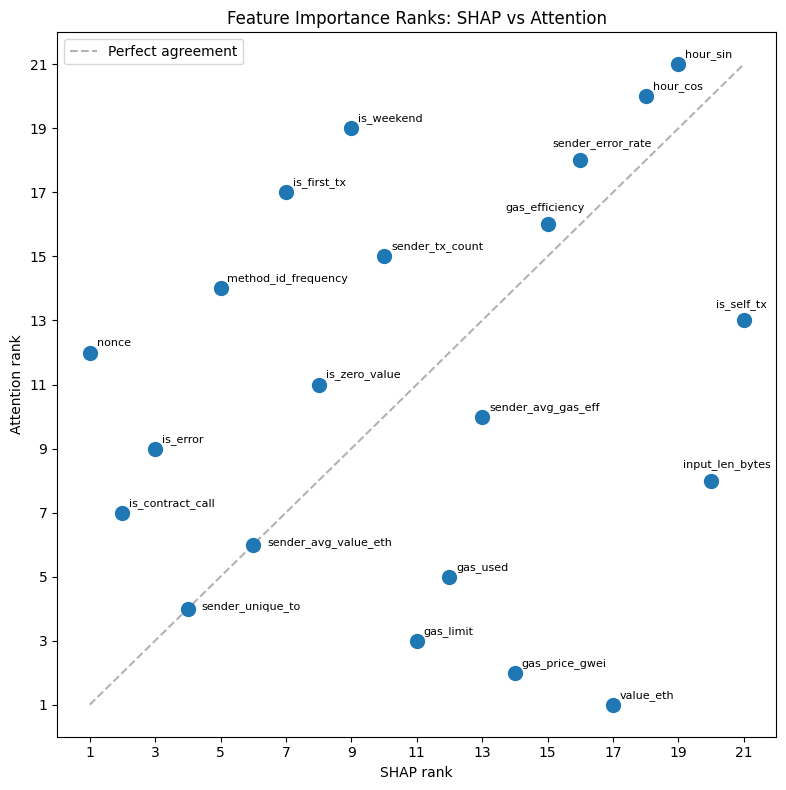

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

n_features = len(comparison)

# Scatter plot
ax.scatter(
    comparison["shap_rank"],
    comparison["attention_rank"],
    s=100,
    zorder=5
)

# Perfect rank agreement diagonal
ax.plot(
    [1, n_features],
    [1, n_features],
    "k--",
    alpha=0.3,
    label="Perfect agreement"
)

# Individual label offsets for readability
custom_offsets = {
    "sender_error_rate": (-20, 10),
    "gas_efficiency": (-30, 10),
    "sender_unique_to": (10, 0),
    "is_self_tx": (-20, 10),
    "sender_avg_value_eth": (10, 0),
    "input_len_bytes": (-20, 10),
}

# Feature labels
for _, row in comparison.iterrows():
    feature = row["feature"]

    offset = custom_offsets.get(
        feature,
        (5, 5)
    )

    ax.annotate(
        feature,
        (
            row["shap_rank"],
            row["attention_rank"]
        ),
        textcoords="offset points",
        xytext=offset,
        fontsize=8
    )

ax.set_xlabel("SHAP rank")
ax.set_ylabel("Attention rank")
ax.set_title("Feature Importance Ranks: SHAP vs Attention")

ax.set_xlim(0, n_features + 1)
ax.set_ylim(0, n_features + 1)

ax.set_xticks(range(1, n_features + 1, 2))
ax.set_yticks(range(1, n_features + 1, 2))

ax.legend()

plt.tight_layout()

if SAVE_ARTIFACTS:
    plt.savefig(
        save_path(
            "results/explainability_comparison/"
            "72_rank_scatter.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

plt.show()

**Сравнительная горизонтальная диаграмма**

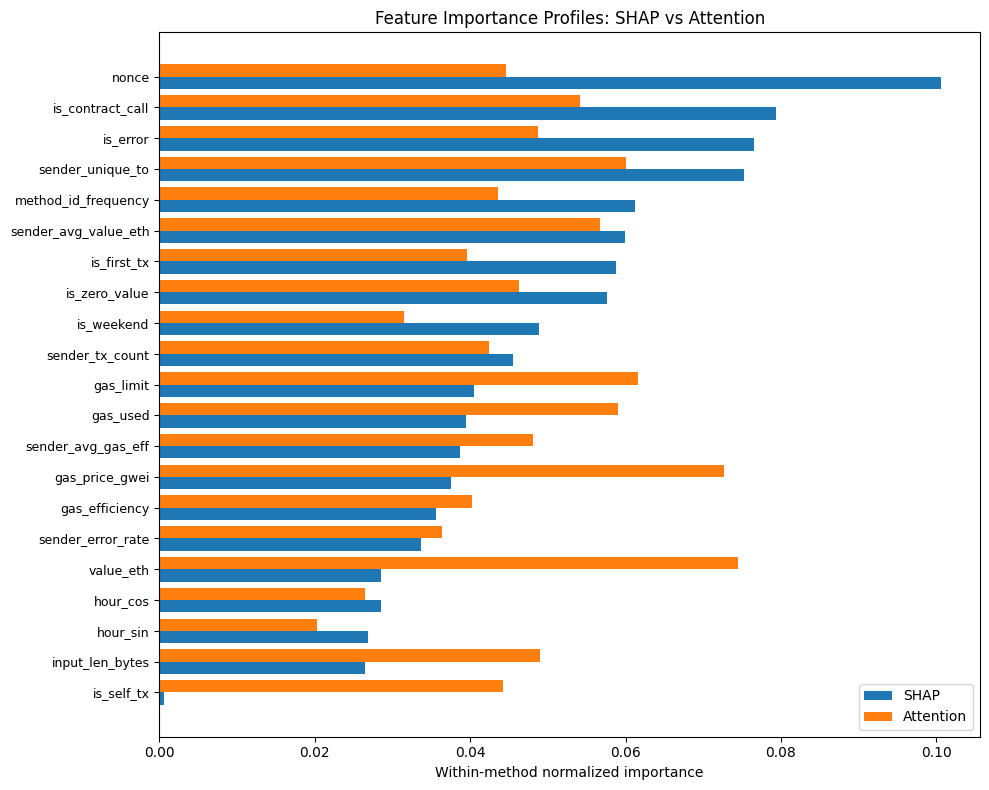

In [ ]:
# ============================================================
# Within-method normalization
# ============================================================

shap_vals = (
    importance
    .set_index("feature")["shap_importance"]
)

att_vals = (
    att_importance
    .set_index("feature")["attention_importance"]
)

# Normalize each method independently so that its values sum to 1
shap_norm = shap_vals / shap_vals.sum()
att_norm = att_vals / att_vals.sum()

# Sort features by SHAP importance for visualization
features_sorted = (
    shap_norm
    .sort_values(ascending=True)
    .index
)

shap_sorted = shap_norm.loc[features_sorted]
att_sorted = att_norm.loc[features_sorted]


# ============================================================
# Visualization
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

y = np.arange(len(features_sorted))
height = 0.4

ax.barh(
    y,
    shap_sorted.values,
    height=height,
    label="SHAP"
)

ax.barh(
    y + height,
    att_sorted.values,
    height=height,
    label="Attention"
)

ax.set_yticks(y + height / 2)
ax.set_yticklabels(
    features_sorted,
    fontsize=9
)

ax.set_xlabel("Within-method normalized importance")
ax.set_title("Feature Importance Profiles: SHAP vs Attention")

ax.legend()

plt.tight_layout()

if SAVE_ARTIFACTS:
    plt.savefig(
        save_path(
            "results/explainability_comparison/"
            "73_feature_importance_bar.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

plt.show()

**Ранговая корреляция Спирмена**

In [ ]:
rho, pvalue = spearmanr(
    comparison["shap_rank"],
    comparison["attention_rank"]
)

alpha = 0.05

print(f"Spearman rank correlation (rho): {rho:.4f}")
print(f"p-value: {pvalue:.4f}")

if pvalue < alpha:
    print(
        "The rank correlation is statistically significant "
        "(p < 0.05)."
    )
else:
    print(
        "The rank correlation is not statistically significant "
        "(p >= 0.05)."
    )

Spearman rank correlation (rho): 0.1948
p-value: 0.3974
The rank correlation is not statistically significant (p >= 0.05).


# 6 Сравнение с другими методами

## 6.1 Базовый автокодировщик

Базовый автокодировщик (Модель 1) определен, обучен и откалиброван в подразделе 3.3.

Для сравнения с альтернативными методами обнаружения аномалий повторно используются ошибки реконструкции и оптимизированный порог Fraud-F1, полученные ранее на калибровочном наборе данных. Набор данных для контрольного тестирования на данном этапе не используется.

In [ ]:
# Baseline Autoencoder (Model 1)
# Reuse the Calibration scores and the optimized threshold
# obtained in Section 3.2.

baseline_scores = calibration_mse_1
baseline_threshold = threshold_opt_1

baseline_pred = (
    baseline_scores >= baseline_threshold
).astype(int)

print("=== Baseline Autoencoder (Model 1) ===")
print(f"Optimized threshold: {baseline_threshold:.6f}")
print()

print("=== Calibration Classification Report ===")
print(
    classification_report(
        y_calibration,
        baseline_pred,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

print(
    f"AUC-ROC: "
    f"{roc_auc_score(y_calibration, baseline_scores):.4f}"
)

print()
print("=== Calibration Confusion Matrix ===")

baseline_cm = confusion_matrix(
    y_calibration,
    baseline_pred
)

print(baseline_cm)

=== Baseline Autoencoder (Model 1) ===
Optimized threshold: 1.868172

=== Calibration Classification Report ===
              precision    recall  f1-score   support

      Normal       0.93      0.99      0.96      6506
       Fraud       0.80      0.33      0.47       697

    accuracy                           0.93      7203
   macro avg       0.87      0.66      0.71      7203
weighted avg       0.92      0.93      0.91      7203

AUC-ROC: 0.7353

=== Calibration Confusion Matrix ===
[[6449   57]
 [ 468  229]]


## 6.2 Вариационный автокодировщик

**Создание модели VAE**

In [ ]:
# Reset random seed before model initialization
reset_seed(SEED)

# VAE configuration
input_dim = INPUT_DIM
latent_dim = 8
VAE_DROPOUT_RATE = 0.1
VAE_BETA = 0.2


# ============================================================
# Custom VAE layers
# ============================================================

@keras.utils.register_keras_serializable(package="ArticleAE")
class Sampling(layers.Layer):
    """Reparameterization layer: z = μ + σ·ε."""

    def call(self, inputs):
        z_mean, z_log_var = inputs

        epsilon = tf.random.normal(
            shape=tf.shape(z_mean)
        )

        return (
            z_mean
            + tf.exp(0.5 * z_log_var) * epsilon
        )

    def get_config(self):
        return super().get_config()


@keras.utils.register_keras_serializable(package="ArticleAE")
class VAELoss(layers.Layer):
    """
    Adds the VAE loss:
    reconstruction loss + beta * KL divergence.
    """

    def __init__(self, beta=0.2, **kwargs):
        super().__init__(**kwargs)
        self.beta = beta

    def call(self, inputs):
        x, x_decoded, z_mean, z_log_var = inputs

        # Reconstruction loss:
        # mean squared reconstruction error
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_mean(
                tf.square(x - x_decoded),
                axis=1
            )
        )

        # KL divergence:
        # averaged over latent dimensions and samples
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_mean(
                1
                + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = (
            reconstruction_loss
            + self.beta * kl_loss
        )

        self.add_loss(total_loss)

        return x_decoded

    def get_config(self):
        config = super().get_config()

        config.update({
            "beta": self.beta
        })

        return config


# ============================================================
# Encoder
# ============================================================

inputs_vae = keras.Input(
    shape=(input_dim,),
    name="input"
)

encoder_dense_64 = layers.Dense(
    64,
    activation="relu",
    name="encoder_dense_64"
)

encoder_dropout_1 = layers.Dropout(
    VAE_DROPOUT_RATE,
    name="encoder_dropout_1"
)

encoder_dense_32 = layers.Dense(
    32,
    activation="relu",
    name="encoder_dense_32"
)

encoder_dropout_2 = layers.Dropout(
    VAE_DROPOUT_RATE,
    name="encoder_dropout_2"
)

encoder_dense_16 = layers.Dense(
    16,
    activation="relu",
    name="encoder_dense_16"
)


x = encoder_dense_64(inputs_vae)
x = encoder_dropout_1(x)
x = encoder_dense_32(x)
x = encoder_dropout_2(x)
x = encoder_dense_16(x)


# Latent distribution parameters
z_mean = layers.Dense(
    latent_dim,
    name="z_mean"
)(x)

z_log_var = layers.Dense(
    latent_dim,
    name="z_log_var"
)(x)


# Stochastic latent representation used during VAE training
z = Sampling(
    name="sampling"
)([z_mean, z_log_var])


# ============================================================
# Decoder layers
# ============================================================

decoder_dense_16 = layers.Dense(
    16,
    activation="relu",
    name="decoder_dense_16"
)

decoder_dropout_1 = layers.Dropout(
    VAE_DROPOUT_RATE,
    name="decoder_dropout_1"
)

decoder_dense_32 = layers.Dense(
    32,
    activation="relu",
    name="decoder_dense_32"
)

decoder_dropout_2 = layers.Dropout(
    VAE_DROPOUT_RATE,
    name="decoder_dropout_2"
)

decoder_dense_64 = layers.Dense(
    64,
    activation="relu",
    name="decoder_dense_64"
)

decoder_output_layer = layers.Dense(
    input_dim,
    activation="linear",
    name="decoder_output"
)


# Stochastic decoding path used during training
x_decoded = decoder_dense_16(z)
x_decoded = decoder_dropout_1(x_decoded)
x_decoded = decoder_dense_32(x_decoded)
x_decoded = decoder_dropout_2(x_decoded)
x_decoded = decoder_dense_64(x_decoded)

decoder_output = decoder_output_layer(
    x_decoded
)


# ============================================================
# VAE training loss
# ============================================================

outputs_vae = VAELoss(
    beta=VAE_BETA,
    name="vae_loss"
)(
    [
        inputs_vae,
        decoder_output,
        z_mean,
        z_log_var
    ]
)


# ============================================================
# Full VAE model
# ============================================================

vae = keras.Model(
    inputs=inputs_vae,
    outputs=outputs_vae,
    name="variational_autoencoder"
)

vae.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    )
)


# ============================================================
# Deterministic inference model
# ============================================================

# For anomaly detection, use z_mean instead of stochastic
# latent sampling to obtain reproducible reconstruction errors.

x_inference = decoder_dense_16(z_mean)
x_inference = decoder_dropout_1(
    x_inference,
    training=False
)

x_inference = decoder_dense_32(
    x_inference
)

x_inference = decoder_dropout_2(
    x_inference,
    training=False
)

x_inference = decoder_dense_64(
    x_inference
)

inference_output = decoder_output_layer(
    x_inference
)


vae_inference = keras.Model(
    inputs=inputs_vae,
    outputs=inference_output,
    name="vae_inference"
)


# ============================================================
# Model summary
# ============================================================

vae.summary()

Model: "variational_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 21)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dense_64    │ (None, 64)        │      1,408 │ input[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dropout_1   │ (None, 64)        │          0 │ encoder_dense_64… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dense_32    │ (None, 32)        │      2,080 │ encoder_dropout_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dropout_2   │ (None, 32)        │          0 │ encoder_dense_32… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dense_16    │ (None, 16)        │        528 │ encoder_dropout_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 8)         │        136 │ encoder_dense_16… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 8)         │        136 │ encoder_dense_16… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 8)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense_16    │ (None, 16)        │        144 │ sampling[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dropout_1   │ (None, 16)        │          0 │ decoder_dense_16… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense_32    │ (None, 32)        │        544 │ decoder_dropout_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dropout_2   │ (None, 32)        │          0 │ decoder_dense_32… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense_64    │ (None, 64)        │      2,112 │ decoder_dropout_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 21)        │      1,365 │ decoder_dense_64… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_loss (VAELoss)  │ (None, 21)        │          0 │ input[0][0],      │
│                     │                   │            │ decoder_output[0… │
│                     │                   │            │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,453 (33.02 KB)

 Trainable params: 8,453 (33.02 KB)

 Non-trainable params: 0 (0.00 B)

**Обучение модели VAE**

In [ ]:
early_stopping_vae = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOP_PATIENCE,
    restore_best_weights=True,
    verbose=1
)

history_vae = vae.fit(
    x=X_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val,),
    callbacks=[
        early_stopping_vae
    ],
    shuffle=True,
    verbose=1
)

print()
print(
    f"VAE training completed after "
    f"{len(history_vae.history['loss'])} epochs."
)

print(
    f"Best validation loss: "
    f"{min(history_vae.history['val_loss']):.6f}"
)

Epoch 1/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 1.1774 - val_loss: 0.8108
Epoch 2/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.8254 - val_loss: 0.6486
Epoch 3/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.7268 - val_loss: 0.6007
Epoch 4/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.6872 - val_loss: 0.5703
Epoch 5/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.6574 - val_loss: 0.5406
Epoch 6/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.6316 - val_loss: 0.4960
Epoch 7/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.5944 - val_loss: 0.4654
Epoch 8/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.5731 - val_loss: 0.4533
Epoch 9/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.5499 - val_loss: 0.4321
Epoch 10/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.5372 - val_loss: 0.4239
Epoch 11/300
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.5105 - val_loss: 0.4136
Epoch 12/300
238/238 ━━━━━━━━━━━━━━

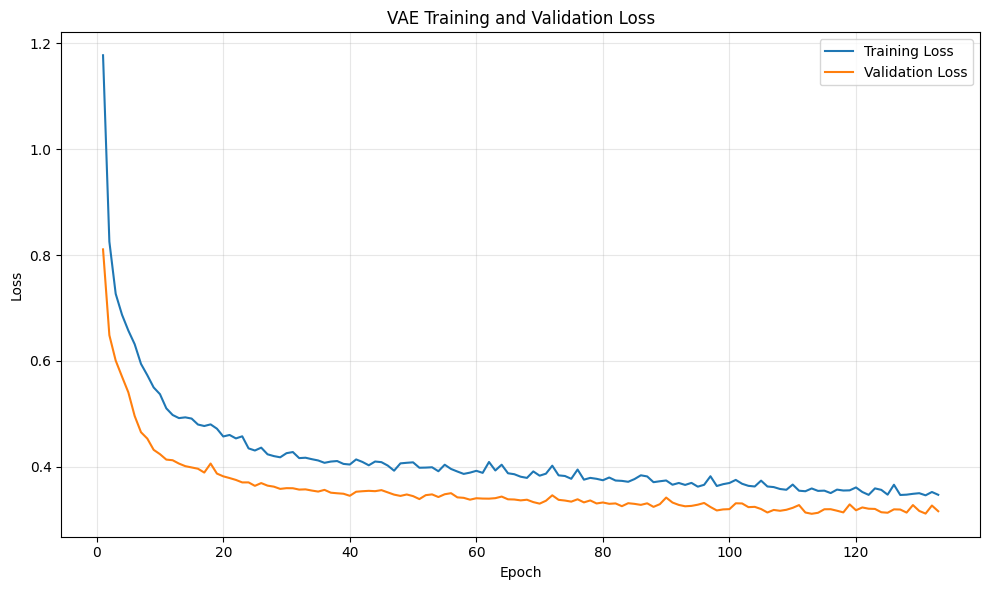

In [ ]:
# Plot VAE training and validation loss

epochs_ran = range(
    1,
    len(history_vae.history["loss"]) + 1
)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_ran,
    history_vae.history["loss"],
    label="Training Loss"
)

plt.plot(
    epochs_ran,
    history_vae.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training and Validation Loss")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

if SAVE_ARTIFACTS:
    plt.savefig(
        save_path(
            "results/alternative_methods/"
            "83_vae_training_history.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

plt.show()

**Сохранение обученной модели VAE**

In [ ]:
# ============================================================
# Save VAE models and weights
# ============================================================

if SAVE_ARTIFACTS:
    VAE_MODEL_PATH = save_path(
        "models/alternative_methods/"
        "84_vae_model.keras"
    )

    VAE_WEIGHTS_PATH = save_path(
        "models/alternative_methods/"
        "85_vae_model.weights.h5"
    )

    VAE_INFERENCE_PATH = save_path(
        "models/alternative_methods/"
        "86_vae_inference.keras"
    )


    # Save the complete VAE model
    # Includes architecture, trained weights, and optimizer state.
    vae.save(VAE_MODEL_PATH)


    # Save VAE weights separately
    vae.save_weights(VAE_WEIGHTS_PATH)


    # Save the deterministic inference model
    # This model uses z_mean instead of stochastic sampling.
    vae_inference.save(VAE_INFERENCE_PATH)


    print(f"VAE model saved to: {VAE_MODEL_PATH}")
    print(f"VAE weights saved to: {VAE_WEIGHTS_PATH}")
    print(f"VAE inference model saved to: {VAE_INFERENCE_PATH}")

VAE model saved to: /content/drive/My Drive/Article (AE-XAI-Ethereum)/84_vae_model.keras
VAE weights saved to: /content/drive/My Drive/Article (AE-XAI-Ethereum)/85_vae_model.weights.h5
VAE inference model saved to: /content/drive/My Drive/Article (AE-XAI-Ethereum)/86_vae_inference.keras


**Оценка модели VAE**

In [ ]:
# ============================================================
# Evaluate VAE on the Calibration set
# ============================================================

# Obtain deterministic reconstructions using z_mean
calibration_recon_vae = vae_inference.predict(
    X_calibration,
    verbose=0
)

# Calculate reconstruction error for each transaction
calibration_mse_vae = np.mean(
    np.square(
        X_calibration - calibration_recon_vae
    ),
    axis=1
)


# ============================================================
# Fraud-F1-optimized threshold
# ============================================================

threshold_opt_vae, best_f1_vae = select_f1_optimal_threshold(
    y_calibration,
    calibration_mse_vae
)

print(f"Optimized threshold: {threshold_opt_vae:.6f}")
print(f"Best Calibration Fraud F1: {best_f1_vae:.4f}")
print()


# ============================================================
# Predictions
# ============================================================

y_pred_vae = (
    calibration_mse_vae >= threshold_opt_vae
).astype(int)


# ============================================================
# Classification metrics
# ============================================================

print("=== Variational Autoencoder ===")
print("=== Calibration Classification Report ===")

print(
    classification_report(
        y_calibration,
        y_pred_vae,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

auc_roc_vae = roc_auc_score(
    y_calibration,
    calibration_mse_vae
)

print(f"AUC-ROC: {auc_roc_vae:.4f}")


# ============================================================
# Confusion matrix
# ============================================================

print()
print("=== Calibration Confusion Matrix ===")

cm_vae = confusion_matrix(
    y_calibration,
    y_pred_vae
)

print(cm_vae)

Optimized threshold: 0.965378
Best Calibration Fraud F1: 0.4586

=== Variational Autoencoder ===
=== Calibration Classification Report ===
              precision    recall  f1-score   support

      Normal       0.93      0.99      0.96      6506
       Fraud       0.75      0.33      0.46       697

    accuracy                           0.92      7203
   macro avg       0.84      0.66      0.71      7203
weighted avg       0.91      0.92      0.91      7203

AUC-ROC: 0.7757

=== Calibration Confusion Matrix ===
[[6430   76]
 [ 467  230]]


In [ ]:
# ============================================================
# Store VAE metrics for method comparison
# ============================================================

precision_vae = precision_score(
    y_calibration,
    y_pred_vae,
    pos_label=1,
    zero_division=0
)

recall_vae = recall_score(
    y_calibration,
    y_pred_vae,
    pos_label=1,
    zero_division=0
)

f1_vae = f1_score(
    y_calibration,
    y_pred_vae,
    pos_label=1,
    zero_division=0
)

print("=== VAE Calibration Metrics ===")
print(f"AUC-ROC:        {auc_roc_vae:.4f}")
print(f"Fraud Recall:   {recall_vae:.4f}")
print(f"Fraud Precision:{precision_vae:.4f}")
print(f"Fraud F1:       {f1_vae:.4f}")

=== VAE Calibration Metrics ===
AUC-ROC:        0.7757
Fraud Recall:   0.3300
Fraud Precision:0.7516
Fraud F1:       0.4586


## 6.3 Изолирующий лес

In [ ]:
# Train Isolation Forest on normal transactions only.
# The built-in decision threshold is not used because
# the anomaly-score threshold is calibrated separately.

iso_forest = IsolationForest(
    contamination="auto",
    random_state=SEED
)

iso_forest.fit(X_train)


# ============================================================
# Anomaly scores on the Calibration set
# ============================================================

# sklearn IsolationForest assigns lower scores
# to more anomalous observations.
# Negate the scores so that larger values correspond
# to a higher degree of anomaly.

calibration_score_if = -iso_forest.score_samples(
    X_calibration
)


# ============================================================
# Fraud-F1-optimized threshold
# ============================================================

threshold_opt_if, best_f1_if = select_f1_optimal_threshold(
    y_calibration,
    calibration_score_if
)

print(f"Optimized threshold: {threshold_opt_if:.6f}")
print(f"Best Calibration Fraud F1: {best_f1_if:.4f}")
print()


# ============================================================
# Evaluation on the Calibration set
# ============================================================

y_pred_if = (
    calibration_score_if >= threshold_opt_if
).astype(int)

print("=== Isolation Forest ===")
print("=== Calibration Classification Report ===")

print(
    classification_report(
        y_calibration,
        y_pred_if,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

print(
    f"AUC-ROC: "
    f"{roc_auc_score(y_calibration, calibration_score_if):.4f}"
)

print()
print("=== Calibration Confusion Matrix ===")

cm_if = confusion_matrix(
    y_calibration,
    y_pred_if
)

print(cm_if)

Optimized threshold: 0.449711
Best Calibration Fraud F1: 0.2643

=== Isolation Forest ===
=== Calibration Classification Report ===
              precision    recall  f1-score   support

      Normal       0.96      0.58      0.72      6506
       Fraud       0.16      0.75      0.26       697

    accuracy                           0.60      7203
   macro avg       0.56      0.66      0.49      7203
weighted avg       0.88      0.60      0.68      7203

AUC-ROC: 0.7021

=== Calibration Confusion Matrix ===
[[3775 2731]
 [ 175  522]]


**Сохранение**

In [ ]:
# ============================================================
# Save Isolation Forest model and calibrated threshold
# ============================================================

if SAVE_ARTIFACTS:
    ISOLATION_FOREST_PATH = save_path(
        "models/alternative_methods/"
        "81_isolation_forest.pkl"
    )

    isolation_forest_artifact = {
        "model": iso_forest,
        "threshold": threshold_opt_if
    }

    joblib.dump(
        isolation_forest_artifact,
        ISOLATION_FOREST_PATH
    )

    print(
        f"Isolation Forest model and threshold saved to: "
        f"{ISOLATION_FOREST_PATH}"
    )

Isolation Forest model and threshold saved to: /content/drive/My Drive/Article (AE-XAI-Ethereum)/81_isolation_forest.pkl


## 6.4 Локальный фактор выброса

In [ ]:
# Train Local Outlier Factor on normal transactions only.
# novelty=True allows scoring previously unseen transactions.
# The built-in decision threshold is not used because
# the anomaly-score threshold is calibrated separately.

lof = LocalOutlierFactor(
    contamination="auto",
    novelty=True
)

lof.fit(X_train)


# ============================================================
# Anomaly scores on the Calibration set
# ============================================================

# sklearn LOF assigns lower scores to more anomalous observations.
# Negate the scores so that larger values correspond
# to a higher degree of anomaly.

calibration_score_lof = -lof.score_samples(
    X_calibration
)


# ============================================================
# Fraud-F1-optimized threshold
# ============================================================

threshold_opt_lof, best_f1_lof = select_f1_optimal_threshold(
    y_calibration,
    calibration_score_lof
)

print(f"Optimized threshold: {threshold_opt_lof:.6f}")
print(f"Best Calibration Fraud F1: {best_f1_lof:.4f}")
print()


# ============================================================
# Evaluation on the Calibration set
# ============================================================

y_pred_lof = (
    calibration_score_lof >= threshold_opt_lof
).astype(int)

print("=== Local Outlier Factor ===")
print("=== Calibration Classification Report ===")

print(
    classification_report(
        y_calibration,
        y_pred_lof,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

print(
    f"AUC-ROC: "
    f"{roc_auc_score(y_calibration, calibration_score_lof):.4f}"
)

print()
print("=== Calibration Confusion Matrix ===")

cm_lof = confusion_matrix(
    y_calibration,
    y_pred_lof
)

print(cm_lof)

Optimized threshold: 1.137897
Best Calibration Fraud F1: 0.3011

=== Local Outlier Factor ===
=== Calibration Classification Report ===
              precision    recall  f1-score   support

      Normal       0.98      0.56      0.71      6506
       Fraud       0.18      0.91      0.30       697

    accuracy                           0.59      7203
   macro avg       0.58      0.73      0.51      7203
weighted avg       0.90      0.59      0.67      7203

AUC-ROC: 0.7351

=== Calibration Confusion Matrix ===
[[3637 2869]
 [  65  632]]


**Сохранение**

In [ ]:
# ============================================================
# Save Local Outlier Factor model and calibrated threshold
# ============================================================

if SAVE_ARTIFACTS:
    LOF_MODEL_PATH = save_path(
    "models/alternative_methods/"
    "82_lof_model.pkl"
    )

    lof_artifact = {
        "model": lof,
        "threshold": threshold_opt_lof
    }

    joblib.dump(
        lof_artifact,
        LOF_MODEL_PATH
    )

    print(
        f"LOF model and threshold saved to: "
        f"{LOF_MODEL_PATH}"
    )

LOF model and threshold saved to: /content/drive/My Drive/Article (AE-XAI-Ethereum)/82_lof_model.pkl


## 6.5 Результаты и выводы

**Результаты**

In [ ]:
# ============================================================
# Comparison of anomaly detection methods
# ============================================================

def collect_metrics(
    method_name,
    scores,
    y_true,
    threshold
):
    """
    Calculate anomaly detection metrics using
    a threshold calibrated on the Calibration set.
    """

    y_pred = (
        scores >= threshold
    ).astype(int)

    return {
        "Method": method_name,

        "AUC-ROC": roc_auc_score(
            y_true,
            scores
        ),

        "Fraud Recall": recall_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0
        ),

        "Fraud Precision": precision_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0
        ),

        "Fraud F1": f1_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0
        )
    }


# ============================================================
# Collect Calibration metrics
# ============================================================

comparison_rows = [

    collect_metrics(
        "Baseline AE (Model 1)",
        calibration_mse_1,
        y_calibration,
        threshold_opt_1
    ),

    collect_metrics(
        "VAE",
        calibration_mse_vae,
        y_calibration,
        threshold_opt_vae
    ),

    collect_metrics(
        "Isolation Forest",
        calibration_score_if,
        y_calibration,
        threshold_opt_if
    ),

    collect_metrics(
        "LOF",
        calibration_score_lof,
        y_calibration,
        threshold_opt_lof
    ),

    collect_metrics(
        "AE + Attention (Model 6)",
        calibration_mse_6,
        y_calibration,
        threshold_opt_6
    )
]


# ============================================================
# Comparison table
# ============================================================

df_comparison = pd.DataFrame(
    comparison_rows
)

print(
    "=== Calibration Set: Method Comparison ==="
)

print(
    df_comparison
    .round(4)
    .to_string(index=False)
)


# ============================================================
# Styled table for notebook display
# ============================================================

metric_columns = [
    "AUC-ROC",
    "Fraud Recall",
    "Fraud Precision",
    "Fraud F1"
]

df_styled = (
    df_comparison.style
    .highlight_max(
        subset=metric_columns,
        color="lightgreen"
    )
    .set_caption(
        "Comparison of Anomaly Detection Methods "
        "on the Calibration Set"
    )
    .format({
        column: "{:.4f}"
        for column in metric_columns
    })
)


# ============================================================
# Save comparison results
# ============================================================

if SAVE_ARTIFACTS:
    df_comparison.to_csv(
        save_path(
            "results/alternative_methods/"
            "87_method_comparison.csv"
        ),
        index=False
    )

df_styled

=== Calibration Set: Method Comparison ===
                  Method  AUC-ROC  Fraud Recall  Fraud Precision  Fraud F1
   Baseline AE (Model 1)   0.7353        0.3286           0.8007    0.4659
                     VAE   0.7757        0.3300           0.7516    0.4586
        Isolation Forest   0.7021        0.7489           0.1605    0.2643
                     LOF   0.7351        0.9067           0.1805    0.3011
AE + Attention (Model 6)   0.8420        0.4275           0.5399    0.4772


,Method,AUC-ROC,Fraud Recall,Fraud Precision,Fraud F1
0,Baseline AE (Model 1),0.7353,0.3286,0.8007,0.4659
1,VAE,0.7757,0.3300,0.7516,0.4586
2,Isolation Forest,0.7021,0.7489,0.1605,0.2643
3,LOF,0.7351,0.9067,0.1805,0.3011
4,AE + Attention (Model 6),0.8420,0.4275,0.5399,0.4772


**Выводы**

Сравнение на калибровочной выборке показало, что AE + Attention (модель № 6) достиг наибольших среди всех рассмотренных методов значений AUC-ROC (0.8420) и Fraud F1 (0.4772). Значение Fraud Recall составило 0.4275, что превышает результаты базового AE (0.3286) и VAE (0.3300), тогда как Fraud Precision (0.5399) уступает значениям этих двух методов.

Базовый AE продемонстрировал наибольшее значение Fraud Precision (0.8007), однако его Fraud Recall составило только 0.3286, а AUC-ROC — 0.7353. VAE достиг AUC-ROC = 0.7757, Fraud Recall = 0.3300, Fraud Precision = 0.7516 и Fraud F1 = 0.4586, уступив модели № 6 по AUC-ROC, Fraud Recall и Fraud F1.

Isolation Forest и LOF продемонстрировали существенно более высокие значения Fraud Recall — 0.7489 и 0.9067 соответственно. Вместе с тем это сопровождалось низкими значениями Fraud Precision — 0.1605 и 0.1805 — и соответствующими значениями Fraud F1 = 0.2643 и 0.3011. Полученные результаты указывают на рабочие точки, существенно смещённые в сторону высокой полноты обнаружения аномалий ценой большого числа ложноположительных срабатываний.

Таким образом, ни один из рассмотренных методов не превосходит остальные по всем метрикам одновременно. С учётом принятой в настоящем исследовании приоритетности метрик модель № 6 продемонстрировала наилучший совокупный результат: наибольшее независимое от порога значение AUC-ROC и наибольшее значение Fraud F1, а также более высокое Fraud Recall по сравнению с базовым AE и VAE. Полученные результаты подтверждают ранее сделанный выбор модели № 6 в качестве финальной архитектуры.

Отложенная тестовая выборка не использовалась ни для выбора метода, ни для оптимизации порога. Поэтому архитектура, гиперпараметры и откалиброванный порог принятия решения модели № 6 оставались зафиксированными до проведения финальной оценки на отложенной тестовой выборке.

# 7 Итоговая оценка на отложенной тестовой выборке

После завершения выбора и сравнения моделей на калибровочном наборе данных была зафиксирована модель 6, ее архитектура, гиперпараметры и пороговое значение для принятия решения. Затем для окончательной независимой оценки был использован тестовый набор данных.

In [ ]:
# ------------------------------------------------------------
# Holdout Test data
# ------------------------------------------------------------

X_holdout_test = holdout_test_features[
    feature_cols
].to_numpy(dtype=np.float32)

y_holdout_test = holdout_test_features[
    "label"
].to_numpy(dtype=int)

assert X_holdout_test.shape == (7204, 21)
assert np.sum(y_holdout_test == 0) == 6507
assert np.sum(y_holdout_test == 1) == 697


# ------------------------------------------------------------
# Obtain reconstructions for the Holdout Test set
# ------------------------------------------------------------

holdout_recon_6 = model_6.predict(
    X_holdout_test,
    batch_size=256,
    verbose=0
)


# ------------------------------------------------------------
# Calculate reconstruction error for each transaction
# ------------------------------------------------------------

holdout_mse_6 = np.mean(
    np.square(
        X_holdout_test - holdout_recon_6
    ),
    axis=1
)


# ------------------------------------------------------------
# Apply the threshold previously selected
# on the Calibration set
# ------------------------------------------------------------

y_pred_holdout_6 = (
    holdout_mse_6 >= threshold_opt_6
).astype(int)


# ============================================================
# Final Holdout Test metrics
# ============================================================

print(
    "=== Model 6: Final Holdout Test Evaluation ==="
)

print()

print(
    classification_report(
        y_holdout_test,
        y_pred_holdout_6,
        target_names=[
            "Normal",
            "Fraud"
        ],
        zero_division=0
    )
)

holdout_auc_roc_6 = roc_auc_score(
    y_holdout_test,
    holdout_mse_6
)

print(
    f"AUC-ROC: "
    f"{holdout_auc_roc_6:.4f}"
)

print()

print(
    "=== Holdout Test Confusion Matrix ==="
)

cm_holdout_6 = confusion_matrix(
    y_holdout_test,
    y_pred_holdout_6
)

print(
    cm_holdout_6
)

=== Model 6: Final Holdout Test Evaluation ===

              precision    recall  f1-score   support

      Normal       0.94      0.96      0.95      6507
       Fraud       0.57      0.46      0.51       697

    accuracy                           0.91      7204
   macro avg       0.76      0.71      0.73      7204
weighted avg       0.91      0.91      0.91      7204

AUC-ROC: 0.8489

=== Holdout Test Confusion Matrix ===
[[6267  240]
 [ 378  319]]


In [ ]:
# ============================================================
# Store final Holdout Test metrics
# ============================================================

holdout_precision_6 = precision_score(
    y_holdout_test,
    y_pred_holdout_6,
    pos_label=1,
    zero_division=0
)

holdout_recall_6 = recall_score(
    y_holdout_test,
    y_pred_holdout_6,
    pos_label=1,
    zero_division=0
)

holdout_f1_6 = f1_score(
    y_holdout_test,
    y_pred_holdout_6,
    pos_label=1,
    zero_division=0
)

print("=== Final Model 6 Holdout Test Metrics ===")
print(f"AUC-ROC:         {holdout_auc_roc_6:.4f}")
print(f"Fraud Recall:    {holdout_recall_6:.4f}")
print(f"Fraud Precision: {holdout_precision_6:.4f}")
print(f"Fraud F1:        {holdout_f1_6:.4f}")
print(f"Threshold:       {threshold_opt_6:.6f}")

=== Final Model 6 Holdout Test Metrics ===
AUC-ROC:         0.8489
Fraud Recall:    0.4577
Fraud Precision: 0.5707
Fraud F1:        0.5080
Threshold:       0.246948


Для дополнительной оценки выборочной неопределённости полученных метрик в подразделе 8.4 выполнена стратифицированная бутстрэп-оценка.

# 8 Дополнительные проверки

Проверки 8.1–8.4 носят характер post-hoc exploratory analysis и выполняются без изменения архитектуры модели, её параметров или выбранного порога. Подраздел 8.4 отдельно оценивает выборочную неопределённость финальных Holdout-метрик.

## 8.1 Вариативность весов механизма внимания

### 8.1.1 Задача

**Утверждение (факт):**

В модели №6 AttentionLayer получает 16-мерное скрытое представление *h* после encoder_dense_3. Для каждой транзакции слой вычисляет

$$s=tanh(hW+b), α=softmax(s)$$

, после чего формирует выходное представление

$$ \hat h=h\odot\alpha. $$

Следовательно, для каждой транзакции формируется собственный 16-мерный вектор весов α, сумма компонентов которого равна 1. Однако из самой архитектуры ещё не следует, что эти веса существенно отличаются от равномерных (1/16 = 0.0625) и заметно изменяются между транзакциями. В текущем анализе объяснимости используются выходные активации *h^*, а не непосредственно значения *α*.

**Гипотеза:**

Обученный AttentionLayer модели 6 формирует неравномерные и зависящие от конкретной транзакции веса внимания, то есть механизм не сводится к почти равномерному либо практически постоянному масштабированию 16 компонентов скрытого представления.


**Порядок проведения проверки:**

Для всех 7203 транзакций Calibration напрямую восстановить векторы *α* из обученных параметров AttentionLayer и проверить два независимых свойства.

Первое — неравномерность внутри одной транзакции. Для этого полезны:

- максимальный вес max(α_i);
- среднее абсолютное отклонение весов от равномерного значения \(1/16\);
- нормированная энтропия

$$ H_{\mathrm{norm}}(\alpha)= -\frac{\sum_i\alpha_i\ln\alpha_i}{\ln16}. $$

Для строго равномерного распределения она равна 1. Чем сильнее концентрация весов, тем она ниже.

Второе — изменчивость между транзакциями. Для этого:

- вычислить стандартное отклонение каждого из 16 весов *α_i* по Calibration;
- оценить среднее расстояние каждого вектора *α* от среднего вектора весов по всей Calibration.

Проверить: размерность (7203, 16), конечность значений, веса в диапазоне [0,1], сумма каждой строки ≈ 1.

**Возможные результаты и интерпретации:**

- Если энтропия почти равна 1.0, max(*α*) близок к 0.0625, а отклонение от равномерного распределения минимально, то слой фактически почти не осуществляет селективного перевзвешивания. Это ослабит трактовку AttentionLayer как содержательного механизма внимания.

- Если веса заметно неравномерны, но их стандартное отклонение между транзакциями практически нулевое, то слой выполняет главным образом статическое обученное перевзвешивание компонентов скрытого пространства. Утверждать о выраженной адаптации внимания к каждой транзакции будет нельзя.

- Если веса и неравномерны внутри транзакций, и заметно меняются между транзакциями, результат будет согласовываться с гипотезой: AttentionLayer действительно реализует входозависимое перераспределение относительных весов между компонентами скрытого представления.

- Возможен и промежуточный результат: например, большинство компонент изменяется слабо, а несколько — существенно. Тогда это будет означать, что адаптивность внимания сосредоточена лишь в части скрытого пространства.

### 8.1.2 Проверка

**Восстановление весов внимания и расчёт показателей**

In [ ]:
# The AttentionLayer in Model 6 receives the 16-dimensional
# output of encoder_dense_3.
attention_layer = model_6.get_layer("attention")

hidden_model = keras.Model(
    inputs=model_6.input,
    outputs=model_6.get_layer("encoder_dense_3").output,
    name="model_6_pre_attention_representation"
)

# Extract the hidden representation h for the entire
# Calibration set.
X_hypothesis = np.asarray(
    X_calibration,
    dtype=np.float32
)

hidden_out = hidden_model.predict(
    X_hypothesis,
    batch_size=BATCH_SIZE,
    verbose=0
)

# ============================================================
# Reconstruct attention weights:
#
# s = tanh(hW + b)
# alpha = softmax(s)
# ============================================================

W = attention_layer.W.numpy()
b = attention_layer.b.numpy()

attention_scores = np.tanh(
    hidden_out @ W + b
)

attention_alpha = tf.nn.softmax(
    attention_scores,
    axis=1
).numpy()


# ============================================================
# Sanity checks
# ============================================================

n_samples, n_attention_units = attention_alpha.shape

assert n_samples == X_calibration.shape[0]
assert n_attention_units == 16
assert np.isfinite(attention_alpha).all()
assert np.all(attention_alpha >= 0.0)
assert np.all(attention_alpha <= 1.0)

row_sums = attention_alpha.sum(axis=1)

assert np.allclose(
    row_sums,
    1.0,
    atol=1e-6
), "Attention weights do not sum to 1."


# ============================================================
# Reference value for uniform attention
# ============================================================

uniform_weight = 1.0 / n_attention_units


# ============================================================
# 1. Non-uniformity within individual transactions
# ============================================================

max_alpha = attention_alpha.max(axis=1)

mean_abs_deviation_from_uniform = np.mean(
    np.abs(attention_alpha - uniform_weight),
    axis=1
)

# Normalized entropy:
# 1.0 = perfectly uniform attention
# lower values = more concentrated attention
eps = 1e-12

entropy = -np.sum(
    attention_alpha
    * np.log(attention_alpha + eps),
    axis=1
)

normalized_entropy = (
    entropy / np.log(n_attention_units)
)


# ============================================================
# 2. Variability across transactions
# ============================================================

alpha_mean_by_unit = attention_alpha.mean(axis=0)
alpha_std_by_unit = attention_alpha.std(axis=0)

mean_alpha_std = alpha_std_by_unit.mean()
max_alpha_std = alpha_std_by_unit.max()

# Distance of each transaction-specific attention vector
# from the global mean attention vector
distance_from_mean_alpha = np.linalg.norm(
    attention_alpha - alpha_mean_by_unit,
    axis=1
)


# ============================================================
# Summary
# ============================================================

print("=== Variability of Attention Weights ===")
print()

print("Attention weights shape:", attention_alpha.shape)
print(f"Uniform reference weight: {uniform_weight:.6f}")
print()

print("--- Non-uniformity within transactions ---")

print(
    f"Mean max(alpha): "
    f"{np.mean(max_alpha):.6f}"
)

print(
    f"Median max(alpha): "
    f"{np.median(max_alpha):.6f}"
)

print(
    f"Mean absolute deviation from uniform: "
    f"{np.mean(mean_abs_deviation_from_uniform):.6f}"
)

print(
    f"Median normalized entropy: "
    f"{np.median(normalized_entropy):.6f}"
)

print(
    f"Mean normalized entropy: "
    f"{np.mean(normalized_entropy):.6f}"
)

print(
    f"Normalized entropy range: "
    f"{np.min(normalized_entropy):.6f} "
    f"to {np.max(normalized_entropy):.6f}"
)

print()

print("--- Variability across transactions ---")

print(
    f"Mean std(alpha) across attention units: "
    f"{mean_alpha_std:.6f}"
)

print(
    f"Maximum std(alpha) among attention units: "
    f"{max_alpha_std:.6f}"
)

print(
    f"Mean distance from global mean alpha: "
    f"{np.mean(distance_from_mean_alpha):.6f}"
)

print(
    f"Median distance from global mean alpha: "
    f"{np.median(distance_from_mean_alpha):.6f}"
)


# ============================================================
# Per-unit summary
# ============================================================

attention_weight_summary = pd.DataFrame({
    "attention_unit": [
        f"attention_unit_{i + 1}"
        for i in range(n_attention_units)
    ],
    "mean_alpha": alpha_mean_by_unit,
    "std_alpha": alpha_std_by_unit,
    "min_alpha": attention_alpha.min(axis=0),
    "max_alpha": attention_alpha.max(axis=0)
})

print()
print("=== Per-Unit Attention Weight Summary ===")

print(
    attention_weight_summary
    .round(6)
    .to_string(index=False)
)

=== Variability of Attention Weights ===

Attention weights shape: (7203, 16)
Uniform reference weight: 0.062500

--- Non-uniformity within transactions ---
Mean max(alpha): 0.162601
Median max(alpha): 0.165754
Mean absolute deviation from uniform: 0.046625
Median normalized entropy: 0.877926
Mean normalized entropy: 0.881630
Normalized entropy range: 0.829347 to 0.934106

--- Variability across transactions ---
Mean std(alpha) across attention units: 0.032461
Maximum std(alpha) among attention units: 0.054689
Mean distance from global mean alpha: 0.142318
Median distance from global mean alpha: 0.146345

=== Per-Unit Attention Weight Summary ===
   attention_unit  mean_alpha  std_alpha  min_alpha  max_alpha
 attention_unit_1    0.109300   0.041153   0.019717   0.256760
 attention_unit_2    0.086658   0.050367   0.016469   0.207720
 attention_unit_3    0.022303   0.002879   0.015884   0.049111
 attention_unit_4    0.044714   0.033432   0.015884   0.159000
 attention_unit_5    0.028960 

**Распределение нормированной энтропии весов внимания**

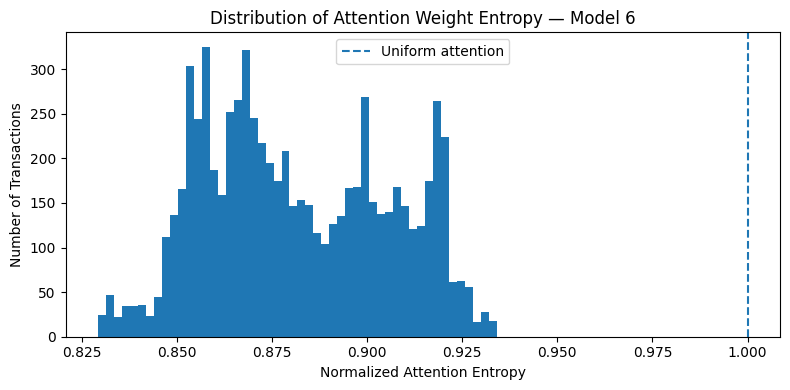

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(
    normalized_entropy,
    bins=50
)

ax.axvline(
    1.0,
    linestyle="--",
    label="Uniform attention"
)

ax.set_xlabel("Normalized Attention Entropy")
ax.set_ylabel("Number of Transactions")
ax.set_title(
    "Distribution of Attention Weight Entropy — Model 6"
)

ax.legend()

plt.tight_layout()
plt.show()

**Квантили нормированной энтропии и максимального веса внимания**

In [ ]:
quantiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

print("\n=== Normalized Entropy Quantiles ===")
for q in quantiles:
    print(
        f"Q{int(q * 100):02d}: "
        f"{np.quantile(normalized_entropy, q):.6f}"
    )

print("\n=== max(alpha) Quantiles ===")
for q in quantiles:
    print(
        f"Q{int(q * 100):02d}: "
        f"{np.quantile(max_alpha, q):.6f}"
    )


=== Normalized Entropy Quantiles ===
Q01: 0.833896
Q05: 0.847801
Q10: 0.852562
Q25: 0.861659
Q50: 0.877926
Q75: 0.901672
Q90: 0.917452
Q95: 0.920378
Q99: 0.927469

=== max(alpha) Quantiles ===
Q01: 0.122373
Q05: 0.133255
Q10: 0.135883
Q25: 0.147947
Q50: 0.165754
Q75: 0.176030
Q90: 0.187735
Q95: 0.191975
Q99: 0.204976


### 8.1.3 Результат и вывод

**Результат:**

Анализ весов AttentionLayer показал выраженное отклонение от равномерного распределения и заметную вариативность между транзакциями. Медиана нормированной энтропии составила 0.8779, а медиана максимального веса — 0.1658 при равномерном опорном значении 0.0625. Среднее стандартное отклонение весов между транзакциями составило 0.0325, при этом отдельные компоненты демонстрировали существенный диапазон значений.

**Вывод:**

Полученные результаты соответствуют исходной гипотезе: AttentionLayer формирует неравномерные и зависящие от конкретной транзакции веса внимания. Наблюдаемое распределение *α* указывает на выраженное адаптивное перевзвешивание компонентов 16-мерного скрытого представления.

## 8.2 Сравнение профилей объяснимости для Normal и Fraud

### 8.2.1 Задача

**Утверждение (факт):**

Основной анализ SHAP и AttentionLayer выполнен для всей Calibration целиком — 7203 транзакций, включая 6506 Normal и 697 Fraud. SHAP характеризует вклад признаков в ошибку реконструкции, а корреляционная оценка AttentionLayer — их линейную связь с 16 компонентами внутреннего взвешенного представления. Поскольку Normal существенно преобладает, агрегированное ранжирование может скрывать различия между классами.

**Гипотеза:**

Профили объяснимости модели различаются для Normal и Fraud. Слабая согласованность глобальных ранжирований SHAP и AttentionLayer (*ρ* = 0.1948) может частично быть связана с объединением двух классов, имеющих различную структуру важности и внутренних зависимостей.

**Порядок проведения проверки:**

1. Для SHAP отдельно рассчитываются значения mean(|SHAP|) по 6506 Normal и 697 Fraud и формируются ранжирования признаков внутри каждого класса. Поскольку SHAP объясняет ошибку реконструкции, абсолютные значения mean(|SHAP|) между классами напрямую не интерпретируются как различия в «силе важности»; основное сравнение проводится по рангам признаков.
2. Для AttentionLayer отдельно для Normal и Fraud рассчитывается средняя абсолютная корреляция Пирсона 21 входного признака с 16 выходными активациями.
3. Сравниваются:
- SHAP Normal ↔ SHAP Fraud;
- Attention Normal ↔ Attention Fraud;
- SHAP ↔ Attention внутри Normal;
- SHAP ↔ Attention внутри Fraud.
4. Дополнительно сравнивается состав Top-5 признаков.

**Возможные результаты и интерпретации:**

- Если SHAP и/или Attention ранжируют признаки по-разному для Normal и Fraud, это указывает на классовую специфичность профилей объяснимости.
- Если согласованность SHAP-Attention внутри Fraud заметно выше глобального (*ρ* = 0.1948), это согласуется c предположением, что pooled-анализ частично скрывает согласованность методов именно для аномального класса.
- Если классовые профили различаются, но SHAP–Attention внутри Fraud остаётся слабой, классовая специфичность существует, но не объясняет основное расхождение методов.
- Если Normal и Fraud дают близкие ранжирования, а SHAP–Attention остаётся слабо согласованным в обоих классах, объединение классов не является существенной причиной расхождения.
- p-value Spearman здесь относится к наличию ранговой связи, а не проверяет статистическую значимость различия двух коэффициентов *ρ*.

### 8.2.2 Проверка

**Подготовка SHAP-значений для каждой транзакции**

In [ ]:
# ------------------------------------------------------------
# Prepare per-transaction SHAP values
# ------------------------------------------------------------

shap_array_h2 = np.asarray(
    shap_array
)

assert shap_array_h2.shape == (
    7203,
    21
)

assert np.isfinite(
    shap_array_h2
).all()

PermutationExplainer explainer: 7204it [25:44,  4.63it/s]

Per-transaction SHAP values saved to 54_shap_values.npy.


**Анализ профилей SHAP для конкретных классов**

In [ ]:
# ------------------------------------------------------------
# Prepare Calibration data
# ------------------------------------------------------------

X_h2 = calibration_features[
    feature_cols
].to_numpy(dtype=np.float32)

y_h2 = calibration_features[
    "label"
].to_numpy(dtype=int)

assert X_h2.shape == (7203, 21)
assert np.sum(y_h2 == 0) == 6506
assert np.sum(y_h2 == 1) == 697

normal_mask_h2 = (
    y_h2 == 0
)

fraud_mask_h2 = (
    y_h2 == 1
)


# ------------------------------------------------------------
# Validate against canonical pooled SHAP importance
# ------------------------------------------------------------

pooled_shap_h2 = np.mean(
    np.abs(shap_array_h2),
    axis=0
)

pooled_shap_df_h2 = pd.DataFrame({
    "feature":
        feature_cols,

    "recomputed_shap_importance":
        pooled_shap_h2
})

shap_check_h2 = (
    importance[
        [
            "feature",
            "shap_importance"
        ]
    ]
    .merge(
        pooled_shap_df_h2,
        on="feature",
        how="inner",
        validate="one_to_one"
    )
)

shap_check_h2[
    "abs_difference"
] = np.abs(
    shap_check_h2[
        "shap_importance"
    ]
    - shap_check_h2[
        "recomputed_shap_importance"
    ]
)

max_shap_difference_h2 = (
    shap_check_h2[
        "abs_difference"
    ].max()
)

print(
    "Maximum pooled SHAP importance difference:",
    f"{max_shap_difference_h2:.10f}"
)

assert max_shap_difference_h2 < 1e-6, (
    "The per-transaction SHAP values do not "
    "reproduce the canonical Section 5.1 results."
)


# ------------------------------------------------------------
# Class-specific mean absolute SHAP values
# ------------------------------------------------------------

shap_normal_scores_h2 = np.mean(
    np.abs(
        shap_array_h2[
            normal_mask_h2
        ]
    ),
    axis=0
)

shap_fraud_scores_h2 = np.mean(
    np.abs(
        shap_array_h2[
            fraud_mask_h2
        ]
    ),
    axis=0
)


# ------------------------------------------------------------
# Rankings
# ------------------------------------------------------------

shap_normal_ranks_h2 = rankdata(
    -shap_normal_scores_h2,
    method="average"
)

shap_fraud_ranks_h2 = rankdata(
    -shap_fraud_scores_h2,
    method="average"
)


# ------------------------------------------------------------
# Normal vs Fraud SHAP agreement
# ------------------------------------------------------------

(
    rho_shap_classes_h2,
    p_shap_classes_h2
) = spearmanr(
    shap_normal_ranks_h2,
    shap_fraud_ranks_h2
)


# ------------------------------------------------------------
# Comparison table
# ------------------------------------------------------------

shap_comparison_h2 = pd.DataFrame({
    "feature":
        feature_cols,

    "shap_normal_score":
        shap_normal_scores_h2,

    "shap_normal_rank":
        shap_normal_ranks_h2,

    "shap_fraud_score":
        shap_fraud_scores_h2,

    "shap_fraud_rank":
        shap_fraud_ranks_h2
})

shap_comparison_h2[
    "shap_rank_change_fraud_minus_normal"
] = (
    shap_comparison_h2[
        "shap_fraud_rank"
    ]
    - shap_comparison_h2[
        "shap_normal_rank"
    ]
)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print()
print(
    "=== Class-Specific SHAP Profiles ==="
)

print()

print(
    "SHAP Normal vs Fraud ranking: "
    f"rho = {rho_shap_classes_h2:.4f}, "
    f"p = {p_shap_classes_h2:.4g}"
)

print()

print(
    shap_comparison_h2
    .sort_values(
        "shap_fraud_rank"
    )
    .round(6)
    .to_string(index=False)
)

Maximum pooled SHAP importance difference: 0.0000000000

=== Class-Specific SHAP Profiles ===

SHAP Normal vs Fraud ranking: rho = 0.0974, p = 0.6745

             feature  shap_normal_score  shap_normal_rank  shap_fraud_score  shap_fraud_rank  shap_rank_change_fraud_minus_normal
            is_error           0.010710              20.0          0.301735              1.0                                -19.0
sender_avg_value_eth           0.017889              13.0          0.147979              2.0                                -11.0
    is_contract_call           0.032082               3.0          0.116905              3.0                                  0.0
      gas_price_gwei           0.012940              17.0          0.076436              4.0                                -13.0
               nonce           0.048839               1.0          0.072242              5.0                                  4.0
      gas_efficiency           0.014711              15.0          0.

**Сравнение механизмов SHAP и Attention с учетом специфики классов**

Расчёт Attention для классов

In [ ]:
# ------------------------------------------------------------
# Extract AttentionLayer output
# ------------------------------------------------------------

attention_model_h2 = keras.Model(
    inputs=model_6.input,
    outputs=model_6.get_layer(
        "attention"
    ).output
)

attention_out_h2 = attention_model_h2.predict(
    X_h2,
    batch_size=256,
    verbose=0
)

assert attention_out_h2.shape == (
    7203,
    16
)


# ------------------------------------------------------------
# Mean absolute Pearson correlation between
# input features and AttentionLayer outputs
# ------------------------------------------------------------

def mean_abs_pearson_h2(
    X,
    representation
):

    scores = np.full(
        X.shape[1],
        np.nan,
        dtype=float
    )

    for j in range(
        X.shape[1]
    ):

        x = X[:, j]

        # Pearson correlation is undefined
        # for a constant feature.
        if np.isclose(
            np.std(x),
            0.0
        ):
            continue

        correlations = []

        for i in range(
            representation.shape[1]
        ):

            h = representation[:, i]

            if np.isclose(
                np.std(h),
                0.0
            ):
                continue

            corr = np.corrcoef(
                x,
                h
            )[0, 1]

            if np.isfinite(corr):
                correlations.append(
                    abs(corr)
                )

        if correlations:
            scores[j] = np.mean(
                correlations
            )

    return scores


# ------------------------------------------------------------
# Class-specific Attention scores
# ------------------------------------------------------------

attention_normal_scores_h2 = (
    mean_abs_pearson_h2(
        X_h2[
            normal_mask_h2
        ],
        attention_out_h2[
            normal_mask_h2
        ]
    )
)

attention_fraud_scores_h2 = (
    mean_abs_pearson_h2(
        X_h2[
            fraud_mask_h2
        ],
        attention_out_h2[
            fraud_mask_h2
        ]
    )
)


# ------------------------------------------------------------
# Identify features with undefined correlations
# ------------------------------------------------------------

undefined_normal_h2 = [
    feature_cols[i]
    for i in range(len(feature_cols))
    if not np.isfinite(
        attention_normal_scores_h2[i]
    )
]

undefined_fraud_h2 = [
    feature_cols[i]
    for i in range(len(feature_cols))
    if not np.isfinite(
        attention_fraud_scores_h2[i]
    )
]

Формирование и сравнение рангов SHAP и Attention

In [ ]:
# ------------------------------------------------------------
# Ranking helper
# ------------------------------------------------------------

def rank_scores_h2(scores):

    ranks = np.full(
        len(scores),
        np.nan,
        dtype=float
    )

    valid = np.isfinite(
        scores
    )

    ranks[valid] = rankdata(
        -scores[valid],
        method="average"
    )

    return ranks


attention_normal_ranks_h2 = (
    rank_scores_h2(
        attention_normal_scores_h2
    )
)

attention_fraud_ranks_h2 = (
    rank_scores_h2(
        attention_fraud_scores_h2
    )
)


# ------------------------------------------------------------
# Safe rank comparison
# ------------------------------------------------------------

def compare_ranks_h2(
    ranks_a,
    ranks_b
):

    valid = (
        np.isfinite(ranks_a)
        & np.isfinite(ranks_b)
    )

    rho, p_value = spearmanr(
        ranks_a[valid],
        ranks_b[valid]
    )

    return (
        rho,
        p_value,
        int(np.sum(valid))
    )


# ------------------------------------------------------------
# Between-class agreement
# ------------------------------------------------------------

(
    rho_attention_classes_h2,
    p_attention_classes_h2,
    n_attention_classes_h2
) = compare_ranks_h2(
    attention_normal_ranks_h2,
    attention_fraud_ranks_h2
)


# ------------------------------------------------------------
# SHAP vs Attention within each class
# ------------------------------------------------------------

(
    rho_normal_methods_h2,
    p_normal_methods_h2,
    n_normal_methods_h2
) = compare_ranks_h2(
    shap_normal_ranks_h2,
    attention_normal_ranks_h2
)

(
    rho_fraud_methods_h2,
    p_fraud_methods_h2,
    n_fraud_methods_h2
) = compare_ranks_h2(
    shap_fraud_ranks_h2,
    attention_fraud_ranks_h2
)

Проверка согласованности с глобальными оценками

In [ ]:
# ------------------------------------------------------------
# Pooled SHAP scores
# ------------------------------------------------------------

shap_all_scores_h2 = np.mean(
    np.abs(shap_array_h2),
    axis=0
)

shap_all_ranks_h2 = rank_scores_h2(
    shap_all_scores_h2
)


# ------------------------------------------------------------
# Pooled Attention scores
# ------------------------------------------------------------

attention_all_scores_h2 = (
    mean_abs_pearson_h2(
        X_h2,
        attention_out_h2
    )
)

attention_all_ranks_h2 = (
    rank_scores_h2(
        attention_all_scores_h2
    )
)


# ------------------------------------------------------------
# Validate pooled Attention against Section 5.2
# ------------------------------------------------------------

current_attention_h2 = pd.DataFrame({
    "feature":
        feature_cols,

    "current_attention_importance":
        attention_all_scores_h2
})

attention_check_h2 = (
    current_attention_h2
    .merge(
       att_importance[
            [
                "feature",
                "attention_importance"
            ]
        ],
        on="feature",
        how="inner",
        validate="one_to_one"
    )
)

attention_check_h2[
    "abs_difference"
] = np.abs(
    attention_check_h2[
        "current_attention_importance"
    ]
    - attention_check_h2[
        "attention_importance"
    ]
)

max_attention_difference_h2 = (
    attention_check_h2[
        "abs_difference"
    ].max()
)


# ------------------------------------------------------------
# Pooled SHAP-Attention agreement
# ------------------------------------------------------------

(
    rho_all_methods_h2,
    p_all_methods_h2,
    n_all_methods_h2
) = compare_ranks_h2(
    shap_all_ranks_h2,
    attention_all_ranks_h2
)


# ------------------------------------------------------------
# Top-5 helper
# ------------------------------------------------------------

def top_features_h2(
    features,
    ranks,
    k=5
):

    valid = np.isfinite(
        ranks
    )

    table = pd.DataFrame({
        "feature":
            np.asarray(features)[valid],

        "rank":
            ranks[valid]
    })

    return (
        table
        .sort_values("rank")
        .head(k)["feature"]
        .tolist()
    )


shap_normal_top5_h2 = top_features_h2(
    feature_cols,
    shap_normal_ranks_h2
)

attention_normal_top5_h2 = top_features_h2(
    feature_cols,
    attention_normal_ranks_h2
)

shap_fraud_top5_h2 = top_features_h2(
    feature_cols,
    shap_fraud_ranks_h2
)

attention_fraud_top5_h2 = top_features_h2(
    feature_cols,
    attention_fraud_ranks_h2
)


normal_top5_overlap_h2 = [
    feature
    for feature in shap_normal_top5_h2
    if feature in attention_normal_top5_h2
]

fraud_top5_overlap_h2 = [
    feature
    for feature in shap_fraud_top5_h2
    if feature in attention_fraud_top5_h2
]

**Итоговая таблица и проверки**

In [ ]:
# ------------------------------------------------------------
# Full comparison table
# ------------------------------------------------------------

comparison_h2 = pd.DataFrame({
    "feature":
        feature_cols,

    "shap_normal_score":
        shap_normal_scores_h2,

    "shap_normal_rank":
        shap_normal_ranks_h2,

    "shap_fraud_score":
        shap_fraud_scores_h2,

    "shap_fraud_rank":
        shap_fraud_ranks_h2,

    "attention_normal_score":
        attention_normal_scores_h2,

    "attention_normal_rank":
        attention_normal_ranks_h2,

    "attention_fraud_score":
        attention_fraud_scores_h2,

    "attention_fraud_rank":
        attention_fraud_ranks_h2
})


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print(
    "=== Class-Specific Explainability Comparison ==="
)

print()

print(
    "Undefined Attention scores in Normal:",
    undefined_normal_h2
)

print(
    "Undefined Attention scores in Fraud:",
    undefined_fraud_h2
)

print()

print(
    "--- Between-Class Agreement ---"
)

print(
    "SHAP Normal vs Fraud: "
    f"rho = {rho_shap_classes_h2:.4f}, "
    f"p = {p_shap_classes_h2:.4g}, "
    "n = 21"
)

print(
    "Attention Normal vs Fraud: "
    f"rho = {rho_attention_classes_h2:.4f}, "
    f"p = {p_attention_classes_h2:.4g}, "
    f"n = {n_attention_classes_h2}"
)

print()

print(
    "--- SHAP vs Attention Within Each Class ---"
)

print(
    "Normal: "
    f"rho = {rho_normal_methods_h2:.4f}, "
    f"p = {p_normal_methods_h2:.4g}, "
    f"n = {n_normal_methods_h2}"
)

print(
    "Fraud:  "
    f"rho = {rho_fraud_methods_h2:.4f}, "
    f"p = {p_fraud_methods_h2:.4g}, "
    f"n = {n_fraud_methods_h2}"
)

print()

print(
    "--- Consistency Checks ---"
)

print(
    "Maximum pooled Attention importance difference: "
    f"{max_attention_difference_h2:.10f}"
)

print(
    "All Calibration SHAP vs Attention: "
    f"rho = {rho_all_methods_h2:.4f}, "
    f"p = {p_all_methods_h2:.4g}, "
    f"n = {n_all_methods_h2}"
)

print()

print(
    "--- Top-5 Overlap ---"
)

print(
    "Normal SHAP Top-5:",
    shap_normal_top5_h2
)

print(
    "Normal Attention Top-5:",
    attention_normal_top5_h2
)

print(
    "Normal overlap:",
    normal_top5_overlap_h2,
    f"({len(normal_top5_overlap_h2)}/5)"
)

print()

print(
    "Fraud SHAP Top-5:",
    shap_fraud_top5_h2
)

print(
    "Fraud Attention Top-5:",
    attention_fraud_top5_h2
)

print(
    "Fraud overlap:",
    fraud_top5_overlap_h2,
    f"({len(fraud_top5_overlap_h2)}/5)"
)

print()

print(
    "=== Full Rank Comparison ==="
)

print(
    comparison_h2
    .sort_values(
        "shap_fraud_rank"
    )
    .round(6)
    .to_string(index=False)
)


# ------------------------------------------------------------
# Mandatory consistency checks
# ------------------------------------------------------------

assert max_attention_difference_h2 < 1e-8, (
    "The current Attention profile does not reproduce "
    "the canonical Section 5.2 results."
)

assert np.isclose(
    rho_all_methods_h2,
    0.1948,
    atol=5e-4
), (
    "The pooled SHAP-Attention ranking does not "
    "reproduce canonical rho = 0.1948."
)

assert np.isclose(
    p_all_methods_h2,
    0.3974,
    atol=5e-4
), (
    "The pooled SHAP-Attention comparison does not "
    "reproduce canonical p = 0.3974."
)

print()
print(
    "All consistency checks passed."
)

=== Class-Specific Explainability Comparison ===

Undefined Attention scores in Normal: []
Undefined Attention scores in Fraud: ['is_self_tx']

--- Between-Class Agreement ---
SHAP Normal vs Fraud: rho = 0.0974, p = 0.6745, n = 21
Attention Normal vs Fraud: rho = 0.0406, p = 0.865, n = 20

--- SHAP vs Attention Within Each Class ---
Normal: rho = 0.3714, p = 0.09736, n = 21
Fraud:  rho = 0.7173, p = 0.0003711, n = 20

--- Consistency Checks ---
Maximum pooled Attention importance difference: 0.0000000000
All Calibration SHAP vs Attention: rho = 0.1948, p = 0.3974, n = 21

--- Top-5 Overlap ---
Normal SHAP Top-5: ['nonce', 'sender_unique_to', 'is_contract_call', 'method_id_frequency', 'is_first_tx']
Normal Attention Top-5: ['value_eth', 'gas_limit', 'sender_unique_to', 'is_contract_call', 'gas_used']
Normal overlap: ['sender_unique_to', 'is_contract_call'] (2/5)

Fraud SHAP Top-5: ['is_error', 'sender_avg_value_eth', 'is_contract_call', 'gas_price_gwei', 'nonce']
Fraud Attention Top-5: 

### 8.2.3 Результат и вывод

**Результат:**

Раздельный анализ Normal и Fraud выявил выраженную классовую специфичность обоих профилей объяснимости. Согласованность SHAP-ранжирований между классами была практически отсутствующей (*ρ* = 0.0974, p-value = 0.6745), аналогичный результат получен для корреляционных оценок AttentionLayer (*ρ* = 0.0406, p-value = 0.8650); 20 сопоставимых признаков. Внутри класса Normal согласованность SHAP и AttentionLayer была умеренной, но статистически незначимой (*ρ* = 0.3714, p-value = 0.0974). Для Fraud, напротив, была выявлена сильная положительная и статистически значимая ранговая связь (*ρ* = 0.7173, p-value < 0.001). В первую пятёрку обоих Fraud-ранжирований одновременно вошли is_error, sender_avg_value_eth, gas_price_gwei и nonce, то есть четыре из пяти признаков. is_self_tx был постоянным внутри Fraud, поэтому его Pearson correlation не определена; соответствующие сравнения Attention выполнены по 20 признакам.

**Вывод:**

Полученные результаты согласуются с предположением, что объединённый анализ может скрывать более высокую согласованность методов внутри Fraud. Слабая глобальная корреляция не означает отсутствия согласованности во всех подгруппах данных: для Fraud оба подхода демонстрируют сильную положительную ранговую связь и в значительной степени выделяют сходный набор наиболее значимых признаков.

## 8.3 Устойчивость обнаружения для отправителей, отсутствовавших в Train

### 8.3.1 Задача

**Утверждение (факт):**

Разделение данных выполнено на уровне отдельных транзакций. Поэтому Calibration содержит транзакции как отправителей, ранее присутствовавших в Train, так и новых отправителей. Для отправителей, отсутствовавших в Train, значения пяти sender-level признаков заменяются медианами, рассчитанными исключительно по Train.

В текущей Calibration это особенно существенно: unseen senders составляют около 23.62% Normal, но 75.32% Fraud.

**Гипотеза:**

Отсутствие истории отправителя в Train связано с различиями в характеристиках обнаружения Model 6. При этом модель сохраняет способность различать Normal и Fraud среди транзакций unseen senders, несмотря на замену sender-level характеристик Train-медианами.

**Порядок проведения проверки:**

Calibration разделяется на две группы:

- seen sender — отправитель присутствовал в Train;
- unseen sender — отправитель отсутствовал в Train.

Для обеих групп при одной и той же зафиксированной Model 6 и одном и том же t_opt = 0.246948 сравниваются:

- AUC-ROC;
- Fraud Recall;
- FPR;
- дополнительно Precision и F1;
- распределения reconstruction error отдельно для Normal и Fraud.

Поскольку t_opt ранее выбран на всей выборке Calibration, показатели Recall, Precision, F1 и FPR для seen/unseen подгрупп рассматриваются как post-hoc descriptive estimates, а не как независимая out-of-sample оценка.

Особенно ориентируемся на AUC-ROC, Recall и FPR. Precision и F1 между seen/unseen нужно интерпретировать осторожно: доля Fraud в этих группах радикально различается, поэтому Precision сильно зависит от различной распространённости класса.

**Возможные результаты и интерпретации:**

- Если AUC-ROC, Recall и FPR у unseen senders близки к seen, это будет свидетельствовать об отсутствии выраженного ухудшения качества на Calibration при отсутствии истории отправителя.

- Если у unseen Normal reconstruction error выше и FPR возрастает, это будет согласовываться с тем, что замена sender-level признаков медианами затрудняет корректную реконструкцию новых отправителей.

- Если у unseen Fraud ошибки реконструкции и Recall выше, нельзя автоматически говорить, что модель «лучше обобщается»: новые мошеннические отправители могут просто сильнее отличаться от нормального Train-распределения.

- Если AUC-ROC и/или Fraud Recall в группе unseen senders снижаются, это будет указывать на ограничение применимости модели к новым отправителям.

### 8.3.2 Проверка

**Подготовка данных и определение Seen/Unseen**

In [ ]:
BATCH_SIZE_H3 = 256


# ------------------------------------------------------------
# Validate parsed transactions for sender-address recovery
# ------------------------------------------------------------

assert parsed_df["hash"].is_unique


# ------------------------------------------------------------
# Calibration data
# ------------------------------------------------------------

X_h3 = calibration_features[
    feature_cols
].to_numpy(dtype=np.float32)

y_h3 = calibration_features[
    "label"
].to_numpy(dtype=int)

assert X_h3.shape == (7203, 21)
assert np.sum(y_h3 == 0) == 6506
assert np.sum(y_h3 == 1) == 697


# ------------------------------------------------------------
# Restore sender addresses by transaction hash
# ------------------------------------------------------------

sender_by_hash_h3 = (
    parsed_df
    .set_index("hash")["from"]
)


train_sender_h3 = (
    train_features["hash"]
    .map(sender_by_hash_h3)
)

calibration_sender_h3 = (
    calibration_features["hash"]
    .map(sender_by_hash_h3)
)

assert train_sender_h3.notna().all()
assert calibration_sender_h3.notna().all()


# Normalize sender addresses
train_sender_h3 = (
    train_sender_h3
    .astype(str)
    .str.lower()
)

calibration_sender_h3 = (
    calibration_sender_h3
    .astype(str)
    .str.lower()
)


# ------------------------------------------------------------
# Seen / unseen sender status
# ------------------------------------------------------------

train_sender_set_h3 = set(
    train_sender_h3
)

seen_mask_h3 = (
    calibration_sender_h3
    .isin(train_sender_set_h3)
    .to_numpy()
)

unseen_mask_h3 = ~seen_mask_h3


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

print()

print(
    "Seen sender transactions:",
    np.sum(seen_mask_h3)
)

print(
    "Unseen sender transactions:",
    np.sum(unseen_mask_h3)
)

print()

print(
    "Unseen Normal:",
    np.sum(
        unseen_mask_h3
        & (y_h3 == 0)
    ),
    "/",
    np.sum(y_h3 == 0)
)

print(
    "Unseen Fraud:",
    np.sum(
        unseen_mask_h3
        & (y_h3 == 1)
    ),
    "/",
    np.sum(y_h3 == 1)
)


assert np.sum(
    unseen_mask_h3
    & (y_h3 == 0)
) == 1537

assert np.sum(
    unseen_mask_h3
    & (y_h3 == 1)
) == 525

Fixed Model 6 threshold: 0.246948

Seen sender transactions: 5141
Unseen sender transactions: 2062

Unseen Normal: 1537 / 6506
Unseen Fraud: 525 / 697


**Расчёт ошибок реконструкции и метрик**

In [ ]:
# ------------------------------------------------------------
# Reconstruction error
# ------------------------------------------------------------

reconstructed_h3 = model_6.predict(
    X_h3,
    batch_size=BATCH_SIZE_H3,
    verbose=0
)

reconstruction_error_h3 = np.mean(
    np.square(
        X_h3 - reconstructed_h3
    ),
    axis=1
)


# ------------------------------------------------------------
# Canonical AUC sanity check
# ------------------------------------------------------------

auc_all_h3 = roc_auc_score(
    y_h3,
    reconstruction_error_h3
)

print()

print(
    "Calibration AUC-ROC:",
    f"{auc_all_h3:.6f}"
)

assert np.isclose(
    auc_all_h3,
    0.841998,
    atol=5e-6
)


# ------------------------------------------------------------
# Performance helper
# ------------------------------------------------------------

def evaluate_sender_group_h3(mask):

    y = y_h3[mask]

    errors = reconstruction_error_h3[
        mask
    ]

    predictions = (
        errors >= threshold_opt_6
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y,
        predictions,
        labels=[0, 1]
    ).ravel()

    auc = roc_auc_score(
        y,
        errors
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else np.nan
    )

    f1 = (
        2 * precision * recall
        / (precision + recall)
        if (
            np.isfinite(precision)
            and np.isfinite(recall)
            and (precision + recall) > 0
        )
        else np.nan
    )

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else np.nan
    )

    return {
        "n": len(y),
        "normal": int(np.sum(y == 0)),
        "fraud": int(np.sum(y == 1)),
        "fraud_prevalence": np.mean(y == 1),

        "auc_roc": auc,
        "fraud_recall": recall,
        "fraud_precision": precision,
        "fraud_f1": f1,
        "fpr": fpr,

        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }


Calibration AUC-ROC: 0.841998


**Оценка качества обнаружения**

In [ ]:
# ------------------------------------------------------------
# Evaluate all groups
# ------------------------------------------------------------

results_all_h3 = evaluate_sender_group_h3(
    np.ones(
        len(y_h3),
        dtype=bool
    )
)

results_seen_h3 = evaluate_sender_group_h3(
    seen_mask_h3
)

results_unseen_h3 = evaluate_sender_group_h3(
    unseen_mask_h3
)


performance_h3 = pd.DataFrame(
    [
        {
            "group": "All Calibration",
            **results_all_h3
        },
        {
            "group": "Seen sender",
            **results_seen_h3
        },
        {
            "group": "Unseen sender",
            **results_unseen_h3
        }
    ]
)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print()
print(
    "=== Detection Performance by Sender Status ==="
)

print()

print(
    performance_h3[
        [
            "group",
            "n",
            "normal",
            "fraud",
            "fraud_prevalence",
            "auc_roc",
            "fraud_recall",
            "fraud_precision",
            "fraud_f1",
            "fpr"
        ]
    ]
    .round(6)
    .to_string(index=False)
)

print()

print(
    "=== Confusion Matrices ==="
)

print()

for _, row in performance_h3.iterrows():

    print(row["group"])

    print(
        np.array([
            [row["tn"], row["fp"]],
            [row["fn"], row["tp"]]
        ]).astype(int)
    )

    print()


=== Detection Performance by Sender Status ===

          group    n  normal  fraud  fraud_prevalence  auc_roc  fraud_recall  fraud_precision  fraud_f1      fpr
All Calibration 7203    6506    697          0.096765 0.841998      0.427547         0.539855  0.477182 0.039041
    Seen sender 5141    4969    172          0.033457 0.773282      0.389535         0.249071  0.303855 0.040652
  Unseen sender 2062    1537    525          0.254607 0.844501      0.440000         0.816254  0.571782 0.033832

=== Confusion Matrices ===

All Calibration
[[6252  254]
 [ 399  298]]

Seen sender
[[4767  202]
 [ 105   67]]

Unseen sender
[[1485   52]
 [ 294  231]]



**Статистическое сравнение ошибок реконструкции**

In [ ]:
# ------------------------------------------------------------
# Statistical comparison helper
# ------------------------------------------------------------

def compare_seen_unseen_errors_h3(
    class_label,
    class_name
):

    class_mask = (
        y_h3 == class_label
    )

    seen_errors = reconstruction_error_h3[
        class_mask
        & seen_mask_h3
    ]

    unseen_errors = reconstruction_error_h3[
        class_mask
        & unseen_mask_h3
    ]

    u_stat, p_value = mannwhitneyu(
        unseen_errors,
        seen_errors,
        alternative="two-sided",
        method="asymptotic"
    )

    # Positive value:
    # unseen senders tend to have larger errors.
    rank_biserial = (
        2 * u_stat
        / (
            len(unseen_errors)
            * len(seen_errors)
        )
        - 1
    )

    return {
        "class": class_name,

        "seen_n":
            len(seen_errors),

        "unseen_n":
            len(unseen_errors),

        "seen_mean":
            np.mean(seen_errors),

        "seen_median":
            np.median(seen_errors),

        "unseen_mean":
            np.mean(unseen_errors),

        "unseen_median":
            np.median(unseen_errors),

        "U":
            u_stat,

        "p_value":
            p_value,

        "rank_biserial":
            rank_biserial
    }


# ------------------------------------------------------------
# Run comparisons
# ------------------------------------------------------------

normal_error_h3 = compare_seen_unseen_errors_h3(
    0,
    "Normal"
)

fraud_error_h3 = compare_seen_unseen_errors_h3(
    1,
    "Fraud"
)


error_comparison_h3 = pd.DataFrame([
    normal_error_h3,
    fraud_error_h3
])


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print(
    "=== Reconstruction Error: "
    "Seen vs Unseen Senders ==="
)

print()

print(
    error_comparison_h3
    .round(6)
    .to_string(index=False)
)

=== Reconstruction Error: Seen vs Unseen Senders ===

 class  seen_n  unseen_n  seen_mean  seen_median  unseen_mean  unseen_median         U  p_value  rank_biserial
Normal    4969      1537   0.061276     0.021389     0.075130       0.039113 4766838.5 0.000000       0.248296
 Fraud     172       525   1.149342     0.132647     0.449524       0.122502   51566.0 0.005121       0.142104


### 8.3.3 Результат и вывод

**Результат:**

Разделение Calibration по наличию отправителя в Train показало существенные различия между группами. Среди транзакций unseen senders доля Fraud составляла 25.46%, тогда как среди seen senders — 3.35%. При использовании одной и той же Model 6 и фиксированного порога t_opt = 0.246948 для unseen senders были получены AUC-ROC = 0.8445, Fraud Recall = 0.4400 и FPR = 0.0338; для seen senders соответствующие значения составили 0.7733, 0.3895 и 0.0407. Для Normal reconstruction error у unseen senders был статистически значимо выше (медиана 0.0391 против 0.0214; rank-biserial = 0.2483; p-value < 0.001). Для Fraud также выявлено статистически значимое различие распределений (p-value = 0.0051), однако эффект был слабее (rank-biserial = 0.1421), а различия средних и медиан указывают на выраженную асимметрию распределения.

*Примечание: Mann–Whitney U применяется на уровне отдельных транзакций и не учитывает возможную зависимость между несколькими транзакциями одного отправителя. Поэтому соответствующие p-values интерпретируются как exploratory, а основной акцент делается на величине эффекта и описательных различиях распределений.*

**Вывод:**

Полученные результаты согласуются со сформулированной гипотезой. Отсутствие истории отправителя в Train связано с изменением распределения reconstruction error, особенно для Normal-транзакций. Вместе с тем на Calibration не выявлено снижения способности Model 6 различать Normal и Fraud среди unseen senders: точечные оценки AUC-ROC и Fraud Recall в этой подгруппе оказались не ниже, чем для seen senders. Однако данный результат не следует интерпретировать как доказательство лучшей обобщающей способности модели на новых отправителей, поскольку seen и unseen группы существенно различаются по составу и доле Fraud. Кроме того, для unseen senders sender-level признаки заменяются Train-медианами, поэтому часть наблюдаемого эффекта может быть связана со специфическим паттерном импутации.

## 8.4 Бутстрэп-оценка неопределённости финальных метрик

### 8.4.1 Задача

**Цель:**

Оценить выборочную неопределённость финальных метрик Model 6 на Holdout Test при неизменных архитектуре модели и пороге обнаружения.

**Порядок проведения проверки:**

Для Holdout Test выполняется стратифицированный bootstrap с возвращением отдельно внутри классов Normal и Fraud. В каждой итерации сохраняется исходное количество объектов каждого класса, после чего при фиксированном пороге t_opt = 0.246948 рассчитываются AUC-ROC, Fraud Recall, Fraud Precision, Fraud F1 и FPR. По 5000 bootstrap-итерациям определяются 95%-ные percentile confidence intervals. Модель не переобучается, а порог не переоптимизируется.

**Возможные результаты и интерпретации:**

Узкие доверительные интервалы будут указывать на относительную устойчивость полученных точечных метрик к изменению состава Holdout Test при фиксированном соотношении классов. Широкие интервалы, особенно для Recall, Precision или F1, будут свидетельствовать о существенной выборочной неопределённости. При этом bootstrap не оценивает вариативность, связанную с другим разбиением исходного датасета или повторным обучением модели с другим random seed, поэтому не устраняет соответствующее ограничение исследования.

### 8.4.2 Проверка

**Подготовка Bootstrap-анализа**

In [ ]:
# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

N_BOOTSTRAP_H4 = 5000
BOOTSTRAP_RANDOM_STATE_H4 = 42
CI_LEVEL_H4 = 0.95
BATCH_SIZE_H4 = 256


# ------------------------------------------------------------
# Holdout Test data
# ------------------------------------------------------------

X_holdout_h4 = holdout_test_features[
    feature_cols
].to_numpy(dtype=np.float32)

y_holdout_h4 = holdout_test_features[
    "label"
].to_numpy(dtype=int)


# ------------------------------------------------------------
# Basic dataset checks
# ------------------------------------------------------------

assert X_holdout_h4.shape == (
    7204,
    21
)

assert len(
    y_holdout_h4
) == 7204

assert np.sum(
    y_holdout_h4 == 0
) == 6507

assert np.sum(
    y_holdout_h4 == 1
) == 697

assert np.isfinite(
    X_holdout_h4
).all()


# ------------------------------------------------------------
# Reconstruction errors
# ------------------------------------------------------------

holdout_reconstructed_h4 = (
    model_6.predict(
        X_holdout_h4,
        batch_size=BATCH_SIZE_H4,
        verbose=0
    )
)

holdout_error_h4 = np.mean(
    np.square(
        X_holdout_h4
        - holdout_reconstructed_h4
    ),
    axis=1
)

assert np.isfinite(
    holdout_error_h4
).all()


# ------------------------------------------------------------
# Metric calculation helper
# ------------------------------------------------------------

def calculate_metrics_h4(
    y_true,
    scores,
    threshold
):

    y_pred = (
        scores >= threshold
    ).astype(int)

    normal_mask = (
        y_true == 0
    )

    fraud_mask = (
        y_true == 1
    )

    tp = int(
        np.sum(
            fraud_mask
            & (y_pred == 1)
        )
    )

    fn = int(
        np.sum(
            fraud_mask
            & (y_pred == 0)
        )
    )

    fp = int(
        np.sum(
            normal_mask
            & (y_pred == 1)
        )
    )

    tn = int(
        np.sum(
            normal_mask
            & (y_pred == 0)
        )
    )

    auc = roc_auc_score(
        y_true,
        scores
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else np.nan
    )

    f1 = (
        2 * precision * recall
        / (precision + recall)
        if (
            np.isfinite(precision)
            and np.isfinite(recall)
            and (precision + recall) > 0
        )
        else np.nan
    )

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else np.nan
    )

    return {
        "auc_roc": auc,
        "fraud_recall": recall,
        "fraud_precision": precision,
        "fraud_f1": f1,
        "fpr": fpr,

        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

print(
    "Bootstrap evaluation setup prepared successfully."
)

print(
    f"Holdout Test shape: {X_holdout_h4.shape}"
)

print(
    f"Bootstrap repetitions: {N_BOOTSTRAP_H4}"
)

**Точечные оценки на отложенной тестовой выборке**

In [ ]:
# ------------------------------------------------------------
# Point estimates on the original Holdout Test
# ------------------------------------------------------------

point_results_h4 = (
    calculate_metrics_h4(
        y_holdout_h4,
        holdout_error_h4,
        threshold_opt_6
    )
)


# ------------------------------------------------------------
# Model / Holdout consistency check
# ------------------------------------------------------------

assert np.isclose(
    point_results_h4[
        "auc_roc"
    ],
    0.848895,
    atol=5e-6
), (
    "The loaded Model 6 does not reproduce "
    "the expected Holdout AUC-ROC."
)


# ------------------------------------------------------------
# Display point estimates
# ------------------------------------------------------------

print(
    "=== Final Holdout Point Estimates ==="
)

print(
    "Threshold:",
    f"{threshold_opt_6:.6f}"
)

print(
    f"AUC-ROC         : "
    f"{point_results_h4['auc_roc']:.6f}"
)

print(
    f"Fraud Recall    : "
    f"{point_results_h4['fraud_recall']:.6f}"
)

print(
    f"Fraud Precision : "
    f"{point_results_h4['fraud_precision']:.6f}"
)

print(
    f"Fraud F1        : "
    f"{point_results_h4['fraud_f1']:.6f}"
)

print(
    f"FPR             : "
    f"{point_results_h4['fpr']:.6f}"
)

print()

print(
    "Confusion matrix:"
)

print(
    np.array([
        [
            point_results_h4["tn"],
            point_results_h4["fp"]
        ],
        [
            point_results_h4["fn"],
            point_results_h4["tp"]
        ]
    ])
)

=== Final Holdout Point Estimates ===
Threshold: 0.246948
AUC-ROC         : 0.848895
Fraud Recall    : 0.457676
Fraud Precision : 0.570662
Fraud F1        : 0.507962
FPR             : 0.036883

Confusion matrix:
[[6267  240]
 [ 378  319]]


**Стратифицированный bootstrap**

In [ ]:
# ------------------------------------------------------------
# Prepare class-specific index sets
# for stratified bootstrap
# ------------------------------------------------------------

normal_indices_h4 = np.flatnonzero(
    y_holdout_h4 == 0
)

fraud_indices_h4 = np.flatnonzero(
    y_holdout_h4 == 1
)

n_normal_h4 = len(
    normal_indices_h4
)

n_fraud_h4 = len(
    fraud_indices_h4
)


# ------------------------------------------------------------
# Random generator
# ------------------------------------------------------------

rng_h4 = np.random.default_rng(
    BOOTSTRAP_RANDOM_STATE_H4
)


# ------------------------------------------------------------
# Storage
# ------------------------------------------------------------

metric_names_h4 = [
    "AUC-ROC",
    "Fraud Recall",
    "Fraud Precision",
    "Fraud F1",
    "FPR"
]

bootstrap_results_h4 = np.empty(
    (
        N_BOOTSTRAP_H4,
        len(metric_names_h4)
    ),
    dtype=float
)


# ------------------------------------------------------------
# Stratified bootstrap
#
# Normal and Fraud are sampled separately so that
# every bootstrap sample preserves the original
# Holdout class sizes.
#
# Model parameters and the decision threshold
# remain fixed throughout the procedure.
# ------------------------------------------------------------

for i in range(N_BOOTSTRAP_H4):

    sampled_normal_h4 = rng_h4.choice(
        normal_indices_h4,
        size=n_normal_h4,
        replace=True
    )

    sampled_fraud_h4 = rng_h4.choice(
        fraud_indices_h4,
        size=n_fraud_h4,
        replace=True
    )

    sampled_indices_h4 = np.concatenate(
        [
            sampled_normal_h4,
            sampled_fraud_h4
        ]
    )

    y_sample_h4 = y_holdout_h4[
        sampled_indices_h4
    ]

    score_sample_h4 = holdout_error_h4[
        sampled_indices_h4
    ]

    sample_results_h4 = calculate_metrics_h4(
        y_sample_h4,
        score_sample_h4,
        threshold_opt_6
    )

    bootstrap_results_h4[i] = [
        sample_results_h4["auc_roc"],
        sample_results_h4["fraud_recall"],
        sample_results_h4["fraud_precision"],
        sample_results_h4["fraud_f1"],
        sample_results_h4["fpr"]
    ]


# ------------------------------------------------------------
# Check bootstrap output
# ------------------------------------------------------------

assert bootstrap_results_h4.shape == (
    N_BOOTSTRAP_H4,
    5
)

assert np.isfinite(
    bootstrap_results_h4
).all()

print(
    f"Stratified bootstrap completed successfully: "
    f"{N_BOOTSTRAP_H4} repetitions."
)

**Доверительные интервалы и итоговая таблица**

In [ ]:
# ------------------------------------------------------------
# Percentile confidence intervals
# ------------------------------------------------------------

alpha_h4 = (
    1.0 - CI_LEVEL_H4
)

lower_percentile_h4 = (
    100.0
    * alpha_h4
    / 2.0
)

upper_percentile_h4 = (
    100.0
    * (
        1.0
        - alpha_h4 / 2.0
    )
)


ci_lower_h4 = np.percentile(
    bootstrap_results_h4,
    lower_percentile_h4,
    axis=0
)

ci_upper_h4 = np.percentile(
    bootstrap_results_h4,
    upper_percentile_h4,
    axis=0
)

bootstrap_mean_h4 = np.mean(
    bootstrap_results_h4,
    axis=0
)

bootstrap_std_h4 = np.std(
    bootstrap_results_h4,
    axis=0,
    ddof=1
)


# ------------------------------------------------------------
# Point estimates in the same order as bootstrap metrics
# ------------------------------------------------------------

point_estimates_h4 = np.array([
    point_results_h4["auc_roc"],
    point_results_h4["fraud_recall"],
    point_results_h4["fraud_precision"],
    point_results_h4["fraud_f1"],
    point_results_h4["fpr"]
])


# ------------------------------------------------------------
# Summary table
# ------------------------------------------------------------

bootstrap_summary_h4 = pd.DataFrame({
    "metric":
        metric_names_h4,

    "point_estimate":
        point_estimates_h4,

    "bootstrap_mean":
        bootstrap_mean_h4,

    "bootstrap_std":
        bootstrap_std_h4,

    "ci_2.5%":
        ci_lower_h4,

    "ci_97.5%":
        ci_upper_h4
})


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print()

print(
    "=== Stratified Bootstrap "
    f"({N_BOOTSTRAP_H4} repetitions, "
    f"{CI_LEVEL_H4:.0%} CI) ==="
)

print()

print(
    bootstrap_summary_h4
    .round(6)
    .to_string(index=False)
)


=== Stratified Bootstrap (5000 repetitions, 95% CI) ===

         metric  point_estimate  bootstrap_mean  bootstrap_std  ci_2.5%  ci_97.5%
        AUC-ROC        0.848895        0.848909       0.007573 0.833731  0.863102
   Fraud Recall        0.457676        0.457785       0.019292 0.420373  0.494978
Fraud Precision        0.570662        0.570927       0.018549 0.534479  0.606829
       Fraud F1        0.507962        0.507967       0.017058 0.473941  0.541412
            FPR        0.036883        0.036878       0.002335 0.032273  0.041494


### 8.4.3 Результат и вывод

**Результат:**

Стратифицированный bootstrap с 5000 повторениями показал, что точечные оценки финальных метрик Model 6 на Holdout Test устойчивы к ресэмплированию транзакций при сохранении исходного числа объектов каждого класса. Для AUC-ROC = 0.8489 получен 95%-ный доверительный интервал [0.8337; 0.8631]. Для Fraud Recall = 0.4577 интервал составил [0.4204; 0.4950], для Fraud Precision = 0.5707 — [0.5345; 0.6068], для Fraud F1 = 0.5080 — [0.4739; 0.5414], а для FPR = 0.0369 — [0.0323; 0.0415]. Bootstrap-средние для всех метрик практически совпали с соответствующими точечными оценками.

**Вывод:**

Полученные доверительные интервалы указывают на относительную устойчивость финальных метрик Model 6 к изменению состава Holdout Test в рамках стратифицированного bootstrap. В частности, AUC-ROC сохраняется примерно в диапазоне 0.834–0.863, а Fraud F1 — 0.474–0.541. При этом данная проверка характеризует только выборочную неопределённость зафиксированных предсказаний на текущем Holdout Test и не оценивает вариативность, связанную с другим исходным разбиением данных, повторным обучением модели или изменением random seed.

*Примечание: Bootstrap выполняется на уровне отдельных транзакций и не учитывает возможную зависимость между несколькими транзакциями одного отправителя. Поэтому полученные интервалы характеризуют transaction-level выборочную неопределённость.*

## 8.5 Распределение признака is_self_tx и его SHAP-вклад

### 8.5.1 Задача

**Утверждение (факт):**

В глобальном SHAP-анализе признак is_self_tx получил наименьшую среднюю абсолютную важность среди 21 признака — около 0.000305. В классовом анализе подраздела 8.2 также установлено, что внутри Fraud данный признак является постоянным. Одним из возможных объяснений низкой глобальной SHAP-важности может быть редкость и, соответственно, низкая вариативность is_self_tx в калибровочной выборке.

**Гипотеза:**

Низкая глобальная SHAP-важность is_self_tx согласуется с низкой распространённостью и вариативностью данного признака в Calibration.

**Порядок проведения проверки:**

1. Для 7203 транзакций Calibration восстанавливаются исходные бинарные значения is_self_tx до стандартизации.
2. Определяются количество, доля и дисперсия значений is_self_tx = 1 для всей Calibration и отдельно для Normal и Fraud.
3. Из сохранённого массива per-transaction SHAP извлекаются абсолютные SHAP-значения is_self_tx.
4. Сравнивается средний абсолютный SHAP-вклад для транзакций с is_self_tx = 0 и is_self_tx = 1, а также определяется, какая доля суммарного абсолютного SHAP-вклада данного признака приходится на self-транзакции.

**Возможные результаты и интерпретации:**

- Если is_self_tx = 1 встречается крайне редко, низкая глобальная mean(|SHAP|) будет согласовываться с низкой вариативностью признака.
- Если при этом редкие self-транзакции имеют заметно больший локальный |SHAP|, чем остальные транзакции, это будет дополнительно указывать, что низкая глобальная важность частично связана с малой распространённостью события.
- Если is_self_tx встречается достаточно часто, но его |SHAP| остаётся близким к нулю независимо от значения признака, объяснение через редкость поддержки не получит.
- Проверка имеет описательный характер и сама по себе не устанавливает причинную связь между редкостью признака и его SHAP-важностью.

### 8.5.2 Проверка

**Восстановление is_self_tx и анализ распределения**

In [ ]:
# ------------------------------------------------------------
# Restore original feature values before standardization
# ------------------------------------------------------------

calibration_unscaled_h5 = calibration_features.copy()

calibration_unscaled_h5[
    feature_cols
] = scaler.inverse_transform(
    calibration_features[
        feature_cols
    ]
)

is_self_tx_raw_h5 = (
    calibration_unscaled_h5[
        "is_self_tx"
    ].to_numpy(dtype=float)
)

# is_self_tx must be binary before scaling
assert np.allclose(
    is_self_tx_raw_h5,
    np.rint(is_self_tx_raw_h5),
    atol=1e-6
)

is_self_tx_h5 = np.rint(
    is_self_tx_raw_h5
).astype(int)

assert set(
    np.unique(is_self_tx_h5)
).issubset({0, 1})


labels_h5 = calibration_features[
    "label"
].to_numpy(dtype=int)

assert len(is_self_tx_h5) == 7203
assert np.sum(labels_h5 == 0) == 6506
assert np.sum(labels_h5 == 1) == 697


# ------------------------------------------------------------
# Distribution helper
# ------------------------------------------------------------

def summarize_is_self_tx_h5(
    mask,
    group_name
):

    values = is_self_tx_h5[
        mask
    ]

    self_count = int(
        np.sum(values == 1)
    )

    return {
        "group":
            group_name,

        "n":
            len(values),

        "self_tx_count":
            self_count,

        "self_tx_share":
            self_count / len(values),

        "variance":
            np.var(values)
    }


# ------------------------------------------------------------
# Distribution in Calibration and by class
# ------------------------------------------------------------

distribution_h5 = pd.DataFrame([
    summarize_is_self_tx_h5(
        np.ones(
            len(labels_h5),
            dtype=bool
        ),
        "All Calibration"
    ),

    summarize_is_self_tx_h5(
        labels_h5 == 0,
        "Normal"
    ),

    summarize_is_self_tx_h5(
        labels_h5 == 1,
        "Fraud"
    )
])

**Проверка SHAP-значений**

In [ ]:
# ------------------------------------------------------------
# Extract SHAP contributions for is_self_tx
# ------------------------------------------------------------

assert shap_array.shape == (
    7203,
    21
)

idx_is_self_tx_h5 = feature_cols.index(
    "is_self_tx"
)

abs_shap_is_self_tx_h5 = np.abs(
    shap_array[
        :,
        idx_is_self_tx_h5
    ]
)


# ------------------------------------------------------------
# Validate against canonical global SHAP importance
# ------------------------------------------------------------

canonical_shap_h5 = (
    importance
    .loc[
       importance[
            "feature"
        ] == "is_self_tx",
        "shap_importance"
    ]
    .iloc[0]
)

recomputed_shap_h5 = np.mean(
    abs_shap_is_self_tx_h5
)

assert np.isclose(
    recomputed_shap_h5,
    canonical_shap_h5,
    atol=1e-6
)

**SHAP-вклад признака is_self_tx**

In [ ]:
# ------------------------------------------------------------
# SHAP contribution by feature state
# ------------------------------------------------------------

shap_state_results_h5 = []

total_abs_shap_h5 = np.sum(
    abs_shap_is_self_tx_h5
)

for state_h5 in [0, 1]:

    state_mask_h5 = (
        is_self_tx_h5
        == state_h5
    )

    state_abs_shap_h5 = (
        abs_shap_is_self_tx_h5[
            state_mask_h5
        ]
    )

    state_sum_h5 = np.sum(
        state_abs_shap_h5
    )

    shap_state_results_h5.append({
        "is_self_tx":
            state_h5,

        "n":
            int(
                np.sum(state_mask_h5)
            ),

        "sample_share":
            np.mean(state_mask_h5),

        "mean_abs_shap":
            np.mean(state_abs_shap_h5),

        "median_abs_shap":
            np.median(state_abs_shap_h5),

        "share_of_total_abs_shap":
            (
                state_sum_h5
                / total_abs_shap_h5
                if total_abs_shap_h5 > 0
                else np.nan
            )
    })


shap_by_state_h5 = pd.DataFrame(
    shap_state_results_h5
)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print(
    "=== Distribution of is_self_tx ==="
)

print()

print(
    distribution_h5
    .round(6)
    .to_string(index=False)
)

print()

print(
    "=== SHAP Contribution of is_self_tx ==="
)

print(
    "Canonical global mean(|SHAP|):",
    f"{canonical_shap_h5:.6f}"
)

print()

print(
    shap_by_state_h5
    .round(6)
    .to_string(index=False)
)

=== Distribution of is_self_tx ===

          group    n  self_tx_count  self_tx_share  variance
All Calibration 7203              2       0.000278  0.000278
         Normal 6506              2       0.000307  0.000307
          Fraud  697              0       0.000000  0.000000

=== SHAP Contribution of is_self_tx ===
Canonical global mean(|SHAP|): 0.000305

 is_self_tx    n  sample_share  mean_abs_shap  median_abs_shap  share_of_total_abs_shap
          0 7201      0.999722       0.000000         0.000000                      0.0
          1    2      0.000278       1.099643         1.099643                      1.0


### 8.5.3 Результаты и выводы

**Результат:**

В калибровочной выборке is_self_tx = 1 наблюдался только для 2 из 7203 транзакций (0.0278%), причём обе относились к классу Normal. Среди 697 Fraud-транзакций значение признака было постоянно равно нулю. Для 7201 транзакции с is_self_tx = 0 абсолютный SHAP-вклад признака был равен нулю, тогда как для двух self-транзакций среднее абсолютное SHAP-значение составило 1.099643. Таким образом, весь суммарный абсолютный SHAP-вклад is_self_tx приходился на две транзакции с активным значением признака.

**Вывод:**

Гипотеза получила подтверждение. Минимальная глобальная SHAP-важность is_self_tx (0.000305) обусловлена прежде всего чрезвычайно низкой распространённостью признака в Calibration. При этом в редких транзакциях, для которых is_self_tx = 1, его локальный SHAP-вклад был существенно выше глобального среднего. Следовательно, низкая глобальная важность в данном случае не следует интерпретировать как отсутствие влияния признака во всех отдельных транзакциях.

# Приложения

## A. Визуализация распределений ошибок реконструкции

**KDE-plot Normal vs Fraud**

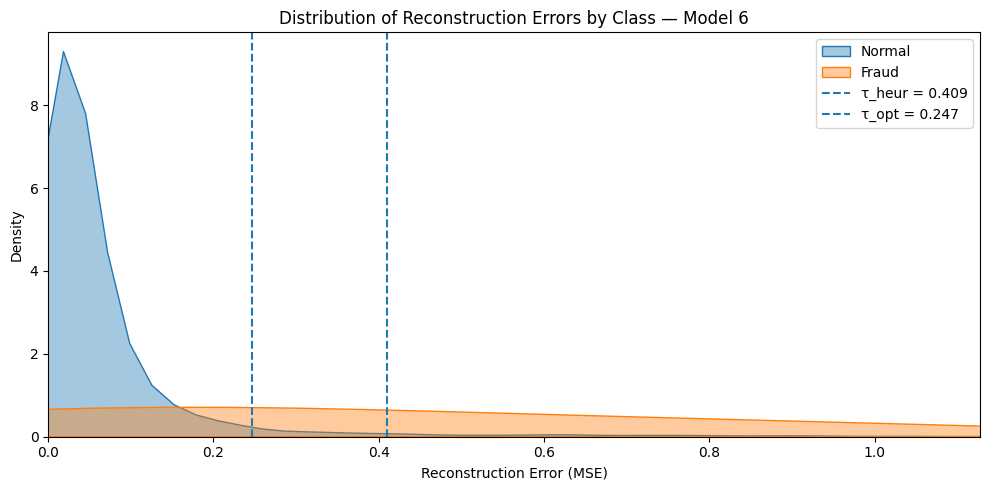

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

# KDE distributions for normal and fraudulent transactions
sns.kdeplot(
    calibration_mse_6[y_calibration == 0],
    ax=ax,
    label="Normal",
    fill=True,
    alpha=0.4
)

sns.kdeplot(
    calibration_mse_6[y_calibration == 1],
    ax=ax,
    label="Fraud",
    fill=True,
    alpha=0.4
)

# Decision thresholds
ax.axvline(
    threshold_heur_6,
    linestyle="--",
    label=f"τ_heur = {threshold_heur_6:.3f}"
)

ax.axvline(
    threshold_opt_6,
    linestyle="--",
    label=f"τ_opt = {threshold_opt_6:.3f}"
)

ax.set_xlabel("Reconstruction Error (MSE)")
ax.set_ylabel("Density")
ax.set_title(
    "Distribution of Reconstruction Errors by Class — Model 6"
)

ax.legend()

# Limit the displayed range only for visualization.
# The KDE itself is calculated using the complete Calibration set.
x_upper = np.quantile(calibration_mse_6, 0.99)
ax.set_xlim(0, x_upper)

plt.tight_layout()

if SAVE_ARTIFACTS:
    plt.savefig(
        save_path(
            "results/model_6_analysis/"
            "92_model_6_reconstruction_error_distribution.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

plt.show()

In [ ]:
x_upper = np.quantile(calibration_mse_6, 0.99)
print(x_upper)

1.1274087511033484


In [ ]:
for label, name in [(0, "Normal"), (1, "Fraud")]:
    values = calibration_mse_6[y_calibration == label]

    print(f"\n{name}")
    print(f"Count:  {len(values)}")
    print(f"Mean:   {np.mean(values):.6f}")
    print(f"Median: {np.median(values):.6f}")
    print(f"Std:    {np.std(values):.6f}")
    print(f"Q25:    {np.quantile(values, 0.25):.6f}")
    print(f"Q75:    {np.quantile(values, 0.75):.6f}")
    print(f"Q90:    {np.quantile(values, 0.90):.6f}")
    print(f"Q95:    {np.quantile(values, 0.95):.6f}")
    print(f"Q99:    {np.quantile(values, 0.99):.6f}")


Normal
Count:  6506
Mean:   0.064549
Median: 0.024693
Std:    0.175457
Q25:    0.012331
Q75:    0.056807
Q90:    0.125720
Q95:    0.212478
Q99:    0.725515

Fraud
Count:  697
Mean:   0.622219
Median: 0.125624
Std:    1.438195
Q25:    0.057372
Q75:    0.792645
Q90:    0.915531
Q95:    1.402726
Q99:    8.071012


## B. Загрузка готовых артефактов

Приложение B предназначено для загрузки ранее сохранённых результатов.

Отдельные ячейки намеренно частично дублируют определения из основных разделов.

Подразделы Приложения B необходимо выполнять только при явной необходимости - в рамках решения конкретных задач, связанных с восстановлением ранее полученных результатов.

### B.1 Сведения об основных готовых артефактах

СПИСОК ОСНОВНЫХ ГОТОВЫХ АРТЕФАКТОВ

*Source and Intermediate Datasets*

- **01_ethereum_raw.csv** - Raw Ethereum transaction dataset collected from Etherscan

- **02_ethereum_parsed.csv** - Parsed transaction dataset after basic data cleaning and field conversion

*Prepared Data Splits*

- **11_train.csv** - Training set used to train the autoencoder on normal transactions

- **12_validation.csv** - Validation set used for training monitoring and early stopping

- **13_calibration.csv** - Calibration set used for threshold selection and model comparison

- **14_holdout_test.csv**- Holdout test set used for final model evaluation

*Preprocessing Artifacts*

- **21_sender_stats.csv** - Sender-level reference statistics calculated from the training set

- **22_method_id_frequency.csv** - Training-based frequency mapping for methodId encoding

- **23_standard_scaler.pkl** - StandardScaler fitted exclusively on the training set

*Pretrained Models*

- **41_model_1.keras** - Model 1
- **42_model_2.keras** - Model 2
- **43_model_3.keras** - Model 3
- **44_model_4.keras** - Model 4
- **45_model_5.keras** - Model 5
- **46_model_6.keras** - Model 6
- **47_model_7.keras** - Model 7

*SHAP artifacts:*

- **51_shap_background_indices.npy** - Background sample indices

- **52_shap_importance.csv** - Feature importance values

- **53_shap_values.npy** - Per-transaction SHAP values for all Calibration transactions

*Attention artifacts:*

- **61_attention_feature_neuron_correlations.csv** - Absolute Attention feature-neuron correlation matrix

- **62_att_importance.csv** - Attention-based feature importance values

*Comparison of the two methods:*

- **71_shap_att_comparison.csv** - Comparison of feature importance ranks produced by the two methods

*Alternative Method Artifacts*

- **81_isolation_forest.pkl** - Trained Isolation Forest model and calibrated threshold

- **82_lof_model.pkl** - Trained Local Outlier Factor model and calibrated threshold

- **84_vae_model.keras** - Complete trained VAE model

- **85_vae_model.weights.h5** - Trained VAE model weights

- **86_vae_inference.keras** - Deterministic VAE inference model for anomaly scoring

- **87_method_comparison.csv** — Calibration-set comparison metrics for all evaluated anomaly detection methods

*Auxiliary Artifacts*

- **91_model_6_threshold.pkl** - Calibrated decision threshold for Model 6


---


СПИСОК ЗАВИСИМОСТЕЙ ПОДРАЗДЕЛОВ НОУТБУКА ОТ ГОТОВЫХ АРТЕФАКТОВ

(актуально для сенария запуска 2)

| Подраздел основной части | Необходимые подразделы Приложения B |
|---|---|
| 3.1 | B.3 |
| 5.1 | B.3, B.5, B.6 |
| 5.2 | B.3, B.5, B.6 |
| 5.3 | B.3, B.7, B.8 |
| 7 | B.3, B.5, B.6, B.14 |
| 8.1 | B.3, B.5, B.6 |
| 8.2 | B.3, B.5, B.6, B.7, B.8 |
| 8.3 | B.2, B.3, B.5, B.6, B.14 |
| 8.4 | B.3, B.5, B.6, B.14 |
| 8.5 | B.3, B.4, B.7 |

### B.2 Сырой и отпаршенный датасет

In [ ]:
raw_df = pd.read_csv(
    github_file(
        "data/source/01_ethereum_raw.csv"
    ),
    low_memory=False
)

parsed_df = pd.read_csv(
    github_file(
        "data/source/02_ethereum_parsed.csv"
    ),
    low_memory=False
)

print("Dataset loaded successfully.")

### B.3 Готовые выборки

In [ ]:
train_features = pd.read_csv(
    github_file(
        "data/splits/11_train.csv"
    ),
    low_memory=False
)

val_features = pd.read_csv(
    github_file(
        "data/splits/12_validation.csv"
    ),
    low_memory=False
)

calibration_features = pd.read_csv(
    github_file(
        "data/splits/13_calibration.csv"
    ),
    low_memory=False
)

holdout_test_features = pd.read_csv(
    github_file(
        "data/splits/14_holdout_test.csv"
    ),
    low_memory=False
)

feature_cols = [
    col for col in train_features.columns
    if col not in ["hash", "label"]
]

print("Prepared data splits loaded successfully.")

Prepared data splits loaded successfully.


### B.4 Готовые артефакты

In [ ]:
sender_stats = pd.read_csv(
    github_file(
        "preprocessing/21_sender_stats.csv"
    ),
    index_col=0
)

method_id_frequency = (
    pd.read_csv(
        github_file(
            "preprocessing/22_method_id_frequency.csv"
        ),
        index_col=0
    )
    .iloc[:, 0]
)

scaler = joblib.load(
    github_file(
        "preprocessing/23_standard_scaler.pkl"
    )
)

print("Preprocessing artifacts loaded successfully.")

Preprocessing artifacts loaded successfully.


### B.5 Слой внимания

In [ ]:
@keras.utils.register_keras_serializable(package="AE_XAI_Ethereum")
class AttentionLayer(layers.Layer):
    """Trainable attention-based weighting of hidden representations."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        hidden_dim = int(input_shape[-1])

        self.W = self.add_weight(
            shape=(hidden_dim, hidden_dim),
            initializer="glorot_uniform",
            trainable=True,
            name="attention_weights"
        )

        self.b = self.add_weight(
            shape=(hidden_dim,),
            initializer="zeros",
            trainable=True,
            name="attention_bias"
        )

        super().build(input_shape)

    def call(self, inputs):
        scores = tf.nn.tanh(
            tf.matmul(inputs, self.W) + self.b
        )

        attention_weights = tf.nn.softmax(
            scores,
            axis=-1
        )

        return inputs * attention_weights

    def get_config(self):
        return super().get_config()

print(
    "AttentionLayer registered successfully."
)

### B.6 Готовые обученные модели

In [ ]:
model_1 = keras.models.load_model(
    github_file("models/autoencoders/41_model_1.keras"),
    compile=False
)

model_2 = keras.models.load_model(
    github_file("models/autoencoders/42_model_2.keras"),
    compile=False
)

model_3 = keras.models.load_model(
    github_file("models/autoencoders/43_model_3.keras"),
    compile=False
)

model_4 = keras.models.load_model(
    github_file("models/autoencoders/44_model_4.keras"),
    compile=False
)

model_5 = keras.models.load_model(
    github_file("models/autoencoders/45_model_5.keras"),
    compile=False
)

model_6 = keras.models.load_model(
    github_file("models/autoencoders/46_model_6.keras"),
    compile=False
)

model_7 = keras.models.load_model(
    github_file("models/autoencoders/47_model_7.keras"),
    compile=False
)

print("Models 1–7 loaded successfully.")

Models 1–7 loaded successfully.


### B.7 Готовые артефакты SHAP

In [ ]:
# ============================================================
# Load saved SHAP indices
# ============================================================

background_idx = np.load(
    github_file(
        "results/shap/51_shap_background_indices.npy"
    )
)

print(
    f"SHAP background indices loaded successfully: "
    f"{len(background_idx)} indices."
)

In [ ]:
# ============================================================
# Load saved SHAP feature importance
# ============================================================

importance = pd.read_csv(
    github_file(
        "results/shap/52_shap_importance.csv"
    )
)

print(importance)

    rank               feature  shap_importance
0      1                 nonce         0.051103
1      2      is_contract_call         0.040290
2      3              is_error         0.038871
3      4      sender_unique_to         0.038207
4      5   method_id_frequency         0.031083
5      6  sender_avg_value_eth         0.030477
6      7           is_first_tx         0.029856
7      8         is_zero_value         0.029292
8      9            is_weekend         0.024851
9     10       sender_tx_count         0.023103
10    11             gas_limit         0.020547
11    12              gas_used         0.020030
12    13    sender_avg_gas_eff         0.019666
13    14        gas_price_gwei         0.019085
14    15        gas_efficiency         0.018093
15    16     sender_error_rate         0.017110
16    17             value_eth         0.014514
17    18              hour_cos         0.014491
18    19              hour_sin         0.013611
19    20       input_len_bytes         0

In [ ]:
# ============================================================
# Load saved per-transaction SHAP values
# ============================================================

shap_array = np.load(
    github_file(
        "results/shap/53_shap_values.npy"
    )
)

assert shap_array.shape == (
    7203,
    21
)

print(
    "Per-transaction SHAP values loaded successfully."
)
print(
    "SHAP array shape:",
    shap_array.shape
)

### B.8 Матрица корреляции внимания и ранги признаков

In [ ]:
# ============================================================
# Load Attention correlation matrix
# ============================================================

attention_corr_df = pd.read_csv(
    github_file(
        "results/attention/61_attention_feature_neuron_correlations.csv"
    ),
    index_col="feature"
)

print(
    "Attention correlation matrix loaded successfully. "
    f"Shape: {attention_corr_df.shape}"
)

In [ ]:
# ============================================================
# Load Attention feature importance
# ============================================================

att_importance = pd.read_csv(
    github_file(
        "results/attention/62_att_importance.csv"
    )
)

print(
    "Attention feature importance loaded successfully. "
    f"Shape: {att_importance.shape}"
)

### B.9 Сравнение ранжирования по SHAP и по механизму внимания

In [ ]:
comparison = pd.read_csv(
    github_file(
        "results/explainability_comparison/71_shap_att_comparison.csv"
    )
)

print(
    "SHAP-Attention comparison loaded successfully. "
    f"Shape: {comparison.shape}"
)

### B.10 Изолирующий лес

In [ ]:
# ============================================================
# Load Isolation Forest model and calibrated threshold
# ============================================================

isolation_forest_artifact = joblib.load(
    github_file(
        "models/alternative_methods/81_isolation_forest.pkl"
    )
)

iso_forest_loaded = isolation_forest_artifact["model"]
threshold_opt_if_loaded = isolation_forest_artifact["threshold"]

print(
    f"Loaded threshold: "
    f"{threshold_opt_if_loaded:.6f}"
)

Loaded threshold: 0.449711


### B.11 Локальный фактор выброса

In [ ]:
# ============================================================
# Load Local Outlier Factor model and calibrated threshold
# ============================================================

lof_artifact = joblib.load(
    github_file(
        "models/alternative_methods/82_lof_model.pkl"
    )
)

lof_loaded = lof_artifact["model"]
threshold_opt_lof_loaded = lof_artifact["threshold"]

print(
    f"Loaded threshold: "
    f"{threshold_opt_lof_loaded:.6f}"
)

### B.12 Вариационный автокодировщик

In [ ]:
# ============================================================
# Load VAE models and weights
# ============================================================

VAE_MODEL_PATH = github_file(
    "models/alternative_methods/84_vae_model.keras"
)

VAE_WEIGHTS_PATH = github_file(
    "models/alternative_methods/85_vae_model.weights.h5"
)

VAE_INFERENCE_PATH = github_file(
    "models/alternative_methods/86_vae_inference.keras"
)


# ============================================================
# Custom VAE layers
# Required for loading the complete VAE model
# ============================================================

@keras.utils.register_keras_serializable(package="ArticleAE")
class Sampling(layers.Layer):
    """Reparameterization layer: z = μ + σ·ε."""

    def call(self, inputs):
        z_mean, z_log_var = inputs

        epsilon = tf.random.normal(
            shape=tf.shape(z_mean)
        )

        return (
            z_mean
            + tf.exp(0.5 * z_log_var) * epsilon
        )

    def get_config(self):
        return super().get_config()


@keras.utils.register_keras_serializable(package="ArticleAE")
class VAELoss(layers.Layer):
    """
    Adds the VAE loss:
    reconstruction loss + beta * KL divergence.
    """

    def __init__(self, beta=0.2, **kwargs):
        super().__init__(**kwargs)
        self.beta = beta

    def call(self, inputs):
        x, x_decoded, z_mean, z_log_var = inputs

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_mean(
                tf.square(x - x_decoded),
                axis=1
            )
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_mean(
                1
                + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var),
                axis=1
            )
        )

        total_loss = (
            reconstruction_loss
            + self.beta * kl_loss
        )

        self.add_loss(total_loss)

        return x_decoded

    def get_config(self):
        config = super().get_config()

        config.update({
            "beta": self.beta
        })

        return config


# ============================================================
# Load complete VAE
# ============================================================

vae_loaded = keras.models.load_model(
    VAE_MODEL_PATH
)

print("Complete VAE model loaded successfully.")


# ============================================================
# Load weights explicitly
# ============================================================

# The .keras file already contains the trained weights.
# This step explicitly restores the separately saved weights
# and can be used as an additional reproducibility check.

vae_loaded.load_weights(
    VAE_WEIGHTS_PATH
)

print("VAE weights loaded successfully.")


# ============================================================
# Load deterministic inference model
# ============================================================

vae_inference_loaded = keras.models.load_model(
    VAE_INFERENCE_PATH
)

print("VAE inference model loaded successfully.")


# ============================================================
# Model information
# ============================================================

print()
print("=== Complete VAE ===")
vae_loaded.summary()

print()
print("=== Deterministic VAE Inference Model ===")
vae_inference_loaded.summary()

### B.13 Результаты сравнения методов обнаружения аномалий

Этот подраздел позволяет загрузить готовую итоговую таблицу сравнения методов,
полученную в подразделе 6.5, без повторного выполнения экспериментов 6.1–6.5.

In [ ]:
# ============================================================
# Load anomaly detection method comparison results
# ============================================================

df_comparison = pd.read_csv(
    github_file(
        "results/alternative_methods/87_method_comparison.csv"
    )
)

print(
    "=== Calibration Set: Method Comparison ==="
)

print(
    df_comparison
    .round(4)
    .to_string(index=False)
)

### B.14 Откалиброванный порог для модели 6

In [ ]:
threshold_opt_6 = joblib.load(
    github_file(
        "results/model_6_analysis/91_model_6_threshold.pkl"
    )
)

print(f"Loaded threshold: {threshold_opt_6:.6f}")

Loaded threshold: 0.246948
